# A Population Map of Vagus Branching — Reproducible figures notebook

> Companion notebook for the manuscript:
> *A standardized map of human vagus nerve branch emergence defines anatomical
> targets for function-selective neuromodulation* (submitted, 2026).
>
> This notebook reproduces every figure and supplementary figure/table in the paper
> from the published dataset. Each section is labeled with its **paper figure / table
> number** so you can map results directly to the manuscript.

## How to run

1. Place `vagus_atlas_dataset.xlsx` (the published dataset) next to this
   notebook, or in `/mnt/data/`. The setup cell auto-detects either location.
2. Run cells top-to-bottom. Total runtime ≈ 1–2 minutes.
3. Outputs are written to subfolders alongside the notebook
   (`Fig3_subway_map/`, `Fig5_regional_divisions/`, `Fig6_branch_free_intervals/`,
   `Fig7_selectivity/`, `Supplementary_tables/`).
4. The **§ 6 Output summary** at the end maps every saved file to its paper figure.

## Methods at a glance

* **Per-nerve trunk length**: sum of ordered cervical + thoracic segment lengths
  from the registration scaffold (not the position of the most-distal branch).
* **Registration**: side-specific, 4-anchor piecewise-linear mapping
  (`U` Carotid Bifurcation · `M` Laryngeal Prominence · `D` Sup. border of Clavicle ·
  `E` true trunk length). Output column `registered_distance_v2`.
* **Cohort N = 28** donors (15 female, 13 male). 56 nerves analyzed.


## § 0  ·  Setup

All imports, paths, and helper functions live inside the registration cell below.


## § 1  ·  Data load and landmark-anchored registration

Loads `vagus_atlas_dataset.xlsx`, computes each nerve's true trunk length
from its segment scaffold, then applies a side-specific **4-anchor
piecewise-linear registration** (`U` `M` `D` `E`) to produce `registered_distance_v2`.

**Inputs**: `vagus_atlas_dataset.xlsx` · `vagus_segment_scaffold.xlsx`
**Outputs**:
- `vagus_atlas_full.xlsx`
- `vagus_atlas_analysis.xlsx`
- `overview_table_registered_v2_tiefix.csv` *(used as Table 1)*

**Runtime**: ~10–20 s


In [1]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

# ============================================================
# Landmark-anchored registration (side-specific, order-based)
# + overview table generation (supplement-ready)
# ============================================================
# Works with:
#   (A) vagus_atlas_dataset.xlsx     (main dataset; uses Group OR Supergroup)
#   (B) vagus_segment_scaffold.xlsx       (donor-sheet REGISTERED workbook; preferred TRUE length source)
#
# TRUE trunk length priority:
#   1) If vagus_segment_scaffold.xlsx exists -> compute TRUE length from segment scaffold (preferred).
#   2) Else -> use 'total_length_sum_seg_length' already in Vagus Atlas dataset (if present).
#   3) Else -> error (we do NOT substitute last branch as endpoint).
#
# Registration:
#   - Order-based U/M/D anchors from the 3 landmark coordinates (sorted),
#     robust to carotid/larynx label swaps and ties.
#   - Tie-fix epsilon applied only when needed to avoid zero-length intervals.
#   - ALWAYS outputs registered_distance_v2.
#
# Outputs:
#   FULL dataset:     vagus_atlas_full.xlsx
#   ANALYSIS dataset: vagus_atlas_analysis.xlsx
#   Overview table:   overview_table_registered_v2_tiefix.csv
# ============================================================

# =========================
# CONFIG
# =========================
DATASET_XLSX = Path("vagus_atlas_dataset.xlsx")
REGISTERED_WB = Path("vagus_segment_scaffold.xlsx")  # <-- simplified name requested

EPS_CM_DEFAULT = 0.10  # cm (tie-fix only)
DROP_NERVES_WITHOUT_TRUE_LENGTH = True

OUT_FULL_XLSX = Path("vagus_atlas_full.xlsx")
OUT_ANALYSIS_XLSX = Path("vagus_atlas_analysis.xlsx")
OUT_TABLE_CSV = Path("overview_table_registered_v2_tiefix.csv")

# Optional: save Supplementary Table S7 audit
OUT_S7_CSV = Path("supp_table_S7_noncanonical_landmark_ordering.csv")

# =========================
# Helpers
# =========================
def ensure_exists_or_none(p: Path, fallbacks=()):
    """Return first existing path among p and fallbacks; return None if none exist."""
    if p is None:
        return None
    p = Path(p)
    if p.exists():
        return p
    for fb in fallbacks:
        fb = Path(fb)
        if fb.exists():
            return fb
    return None

def ensure_exists(p: Path, fallbacks=()):
    out = ensure_exists_or_none(p, fallbacks=fallbacks)
    if out is None:
        raise FileNotFoundError(f"Missing required file: {p}")
    return out

def normalize_side(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"l", "left", "lt", "0"}:
        return "L"
    if s in {"r", "right", "rt", "1"}:
        return "R"
    if str(x).strip() in {"L", "R"}:
        return str(x).strip()
    return str(x).strip()

def detect_group_col(columns):
    cols = set(columns)
    if "Group" in cols:
        return "Group"
    if "Supergroup" in cols:
        return "Supergroup"
    raise ValueError("Could not find group column. Expected 'Group' or 'Supergroup'.")

def segment_sort_key(seg):
    if seg is None or (isinstance(seg, float) and np.isnan(seg)):
        return (99, 9999.0)
    s = str(seg).strip().upper()
    m = re.match(r"^([A-Z]+)\s*(\d+(?:\.\d+)?)$", s)
    if not m:
        return (98, 9999.0)
    letter = m.group(1)
    num = float(m.group(2))
    letter_order = {"C": 0, "T": 1}.get(letter, 50)
    return (letter_order, num)

def mean_min_max(series):
    x = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return (np.nan, np.nan, np.nan)
    return (float(np.mean(x)), float(np.min(x)), float(np.max(x)))

def fmt_mean_minmax(mean, mn, mx, digits=2):
    return f"{mean:.{digits}f} ({mn:.{digits}f}–{mx:.{digits}f})"

def canon_landmark_name(subgroup_value: str):
    """Robust landmark subgroup -> canonical key."""
    s = str(subgroup_value).strip().lower()
    if ("carotid" in s) and ("bifur" in s):
        return "carotid"
    if ("laryngeal" in s) or ("larynx" in s):
        return "larynx"
    if "clavicle" in s:
        return "clavicle"
    return None

# =========================
# 1) Load Vagus Atlas dataset
# =========================
DATASET_XLSX = ensure_exists(DATASET_XLSX, fallbacks=[Path("/mnt/data") / DATASET_XLSX])
print(f"[Load] Vagus Atlas dataset: {DATASET_XLSX}")

df = pd.read_excel(DATASET_XLSX)
df.columns = [c.strip() for c in df.columns]

GROUP_COL = detect_group_col(df.columns)

required = [
    "Subject", "Side", GROUP_COL, "Subgroup",
    "Landmark Position", "Branch Distance (from top of nerve)", "Zone"
]
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    raise ValueError(f"Vagus Atlas dataset missing required columns: {missing_cols}")

df["Subject"] = df["Subject"].astype(str).str.strip()
df["Side"] = df["Side"].apply(normalize_side)
df[GROUP_COL] = df[GROUP_COL].astype(str).str.strip()
df["Subgroup"] = df["Subgroup"].astype(str).str.strip()

for c in ["Landmark Position", "Branch Distance (from top of nerve)"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# If present, keep source's own true length as a reference (used only if registered wb absent)
if "total_length_sum_seg_length" in df.columns:
    df["total_length_sum_seg_length"] = pd.to_numeric(df["total_length_sum_seg_length"], errors="coerce")

print(f"[Vagus] rows={len(df):,} | subjects={df['Subject'].nunique()} | nerves={df[['Subject','Side']].drop_duplicates().shape[0]}")
print("[Vagus] Side counts:", df["Side"].value_counts(dropna=False).to_dict())
print(f"[Vagus] Using group column: {GROUP_COL}")

# =========================
# 1.5) Supplementary Table S7 audit (label-based)
# =========================
is_landmark = df[GROUP_COL].str.lower().eq("landmark")
lm_lbl = df[is_landmark].dropna(subset=["Landmark Position"]).copy()
lm_lbl["canon"] = lm_lbl["Subgroup"].apply(canon_landmark_name)
lm_lbl = lm_lbl.dropna(subset=["canon"])

lm_piv = (lm_lbl.groupby(["Subject","Side","canon"], as_index=False)["Landmark Position"].mean()
          .pivot_table(index=["Subject","Side"], columns="canon", values="Landmark Position", aggfunc="mean")
          .reset_index())

for col in ["carotid", "larynx", "clavicle"]:
    if col not in lm_piv.columns:
        lm_piv[col] = np.nan

s7 = lm_piv.dropna(subset=["carotid","larynx","clavicle"], how="any").copy()
s7["Handling"] = np.where(s7["larynx"] < s7["carotid"], "Inversion",
                   np.where(s7["larynx"] == s7["carotid"], "Tie", "Canonical"))
s7_noncanon = s7[s7["Handling"].ne("Canonical")].copy()

print(f"\n[S7 audit] non-canonical nerve-sides: {len(s7_noncanon)}")
if len(s7_noncanon):
    s7_out = (s7_noncanon[["Subject","Side","carotid","larynx","clavicle","Handling"]]
              .rename(columns={
                  "carotid":"Carotid bifurcation (cm)",
                  "larynx":"Laryngeal prominence (cm)",
                  "clavicle":"Superior border of clavicle (cm)"
              })
              .sort_values(["Handling","Subject","Side"]))
    print(s7_out.to_string(index=False))
    s7_out.to_csv(OUT_S7_CSV, index=False)
    print(f"[Saved] S7 audit CSV: {OUT_S7_CSV}")

# =========================
# 2) Compute TRUE trunk length (preferred from registered wb)
# =========================
REGISTERED_WB = ensure_exists_or_none(REGISTERED_WB, fallbacks=[Path("/mnt/data") / REGISTERED_WB])

used_registered_wb = False
len_map = None
missing_nerves = []

if REGISTERED_WB is not None:
    used_registered_wb = True
    print(f"\n[Load] Registered workbook (preferred TRUE length): {REGISTERED_WB}")
    xls = pd.ExcelFile(REGISTERED_WB)
    print(f"[RegWB] sheets={len(xls.sheet_names)}")

    def parse_registered_sheet(sheet_name: str):
        raw = pd.read_excel(REGISTERED_WB, sheet_name=sheet_name, header=None)

        left_cols = list(range(0, 8))
        right_cols = list(range(8, 16))

        left = raw.iloc[1:, left_cols].copy()
        right = raw.iloc[1:, right_cols].copy()

        left.columns = raw.iloc[1, left_cols].tolist()
        right.columns = raw.iloc[1, right_cols].tolist()

        left = left.iloc[1:].reset_index(drop=True)
        right = right.iloc[1:].reset_index(drop=True)

        left.columns = [str(c).strip() for c in left.columns]
        right.columns = [str(c).strip() for c in right.columns]

        for tab in (left, right):
            for c in tab.columns:
                if ("Distance" in str(c)) or ("Length" in str(c)):
                    tab[c] = pd.to_numeric(tab[c], errors="coerce")

        subj = sheet_name.split()[0]
        left["Subject"] = str(subj)
        left["Side"] = "L"
        right["Subject"] = str(subj)
        right["Side"] = "R"
        return left, right

    def compute_total_len_from_side(df_side: pd.DataFrame):
        if ("Segment Name" not in df_side.columns) or ("Segment Length" not in df_side.columns):
            return np.nan
        seg = df_side[["Segment Name", "Segment Length"]].copy()
        seg["Segment Name"] = seg["Segment Name"].astype(str).str.strip()
        seg = seg.dropna(subset=["Segment Name", "Segment Length"])
        seg = seg[seg["Segment Name"].str.lower().ne("nan")]

        seg_one = seg.groupby("Segment Name", as_index=False)["Segment Length"].max()
        seg_one = seg_one.sort_values("Segment Name", key=lambda s: s.map(segment_sort_key))
        return float(seg_one["Segment Length"].sum()) if len(seg_one) else np.nan

    print("\n[Compute] total_length_sum_seg_length map from registered workbook...")
    records = []
    for sheet in tqdm(xls.sheet_names, desc="Reg sheets"):
        left, right = parse_registered_sheet(sheet)
        for tab, side in [(left, "L"), (right, "R")]:
            records.append({
                "Subject": tab["Subject"].iloc[0],
                "Side": side,
                "total_length_sum_seg_length": compute_total_len_from_side(tab),
                "source_sheet": sheet
            })

    len_map = pd.DataFrame(records)
    print("[LenMap] nerves:", len_map[["Subject","Side"]].drop_duplicates().shape[0],
          "| missing totals:", int(len_map["total_length_sum_seg_length"].isna().sum()))

    source_nerves = set(map(tuple, df[["Subject","Side"]].drop_duplicates().values))
    reg_nerves = set(map(tuple, len_map[["Subject","Side"]].drop_duplicates().values))
    missing_nerves = sorted(source_nerves - reg_nerves)

    if missing_nerves:
        miss_df = pd.DataFrame(missing_nerves, columns=["Subject", "Side"])
        n_miss_rows = df.merge(miss_df, on=["Subject","Side"], how="inner").shape[0]
        print("\n[WARN] Registered workbook does not contain TRUE segment-scaffold lengths for:")
        print(miss_df.to_string(index=False))
        print(f"[WARN] Rows affected in Vagus Atlas dataset: {n_miss_rows}/{len(df)}")
        print("[WARN] These nerve-sides will be excluded from registration and from the overview table "
              "to avoid substituting an endpoint estimate (e.g., last branch).")
    else:
        print("[OK] Registered workbook covers all source nerve-sides.")
else:
    print("\n[INFO] Registered workbook not found. Will use TRUE length from Vagus Atlas file if available.")
    if "total_length_sum_seg_length" not in df.columns:
        raise FileNotFoundError(
            "No registered workbook found AND Vagus Atlas file lacks 'total_length_sum_seg_length'. "
            "Provide 'vagus_segment_scaffold.xlsx' or add the true-length column to the Vagus Atlas file."
        )

# Merge/select TRUE length
if used_registered_wb:
    # If source already has a length column, rename it for audit clarity
    if "total_length_sum_seg_length" in df.columns:
        df = df.rename(columns={"total_length_sum_seg_length": "total_length_sum_seg_length_from_source"})

    # Bring in registered workbook lengths as source of truth
    df = df.merge(len_map[["Subject","Side","total_length_sum_seg_length"]], on=["Subject","Side"], how="left")

    # Audit differences where both exist
    if "total_length_sum_seg_length_from_source" in df.columns:
        both = df["total_length_sum_seg_length"].notna() & df["total_length_sum_seg_length_from_source"].notna()
        if both.any():
            diff = (df.loc[both, "total_length_sum_seg_length"] - df.loc[both, "total_length_sum_seg_length_from_source"]).abs()
            maxdiff = float(np.nanmax(diff)) if len(diff) else 0.0
            if maxdiff > 1e-6:
                print("\n[WARN] TRUE length mismatch (registered vs Vagus Atlas column). Max abs diff:", maxdiff)
                tmp = (df.loc[both, ["Subject","Side","total_length_sum_seg_length","total_length_sum_seg_length_from_source"]]
                       .drop_duplicates()
                       .assign(abs_diff=lambda d: (d["total_length_sum_seg_length"] - d["total_length_sum_seg_length_from_source"]).abs())
                       .sort_values("abs_diff", ascending=False)
                       .head(10))
                print(tmp.to_string(index=False))
            else:
                print("[OK] TRUE length matches between registered workbook and Vagus Atlas column (within tolerance).")

n_missing_len_rows = int(df["total_length_sum_seg_length"].isna().sum())
if n_missing_len_rows:
    print(f"[WARN] Some rows missing total_length_sum_seg_length: {n_missing_len_rows}/{len(df)}")
else:
    print("[OK] total_length_sum_seg_length available for all rows.")

# Save FULL dataset
df.to_excel(OUT_FULL_XLSX, index=False)
print(f"[Saved] FULL dataset: {OUT_FULL_XLSX}")

# Analysis subset
dfA = df[df["total_length_sum_seg_length"].notna()].copy() if DROP_NERVES_WITHOUT_TRUE_LENGTH else df.copy()
print(f"\n[Analysis subset] rows={len(dfA):,} | subjects={dfA['Subject'].nunique()} | nerves={dfA[['Subject','Side']].drop_duplicates().shape[0]}")
if missing_nerves:
    excluded_subjects = sorted(set([s for s, _ in missing_nerves]))
    print("[Analysis subset] excluded donors (missing true length scaffold):", excluded_subjects)

is_landmarkA = dfA[GROUP_COL].str.lower().eq("landmark")
is_branchA = ~is_landmarkA

# =========================
# 3) Registration: order-based U/M/D with tie-fix
# =========================
def compute_UMD_with_tiefix(pos_list, eps_cm=EPS_CM_DEFAULT):
    pos = [p for p in pos_list if np.isfinite(p)]
    if len(pos) == 0:
        return (np.nan, np.nan, np.nan, 0, False, np.nan)
    uniq = sorted(set(pos))
    U = float(uniq[0])
    D = float(uniq[-1])

    tie_fixed = False
    used_eps = np.nan

    if len(uniq) >= 3:
        M = float(np.median(uniq))
    elif len(uniq) == 2:
        span = max(1e-6, D - U)
        eps = min(eps_cm, max(1e-6, 0.01 * span))
        M = U + eps
        tie_fixed = True
        used_eps = eps
    else:
        return (U, np.nan, D, 1, False, np.nan)

    if not (U < M < D):
        span = max(1e-6, D - U)
        eps = min(eps_cm, max(1e-6, 0.01 * span))
        M = U + eps
        tie_fixed = True
        used_eps = eps

    return (U, M, D, len(uniq), tie_fixed, used_eps)

lm = dfA[is_landmarkA].dropna(subset=["Landmark Position"]).copy()
lm_trip = (lm.groupby(["Subject","Side"], as_index=False)
           .agg(lm_positions=("Landmark Position", lambda s: [float(x) for x in s.dropna().tolist()])))

lm_trip[["U_raw","M_raw","D_raw","n_unique_lm","tie_fixed","eps_used_cm"]] = lm_trip["lm_positions"].apply(
    lambda v: pd.Series(compute_UMD_with_tiefix(v))
)

E_true = (dfA.groupby(["Subject","Side"], as_index=False)["total_length_sum_seg_length"]
          .first()
          .rename(columns={"total_length_sum_seg_length":"E_raw"}))

meta = lm_trip.merge(E_true, on=["Subject","Side"], how="left")

meta["valid_geom"] = (
    meta["U_raw"].notna() & meta["M_raw"].notna() & meta["D_raw"].notna() & meta["E_raw"].notna() &
    (meta["U_raw"] > 0) & (meta["M_raw"] > meta["U_raw"]) & (meta["D_raw"] > meta["M_raw"]) & (meta["E_raw"] > meta["D_raw"])
)

tiefix_tbl = meta[meta["tie_fixed"]].sort_values(["Subject","Side"])
print(f"\n[Landmarks] nerves requiring tie-fix (order-based): {len(tiefix_tbl)}")
if len(tiefix_tbl):
    print(tiefix_tbl[["Subject","Side","lm_positions","n_unique_lm","U_raw","M_raw","D_raw","eps_used_cm","E_raw"]].to_string(index=False))

bad_geom = meta[~meta["valid_geom"]].copy()
if len(bad_geom):
    print("\n[ERROR] Invalid landmark geometry even after tie-fix (cannot register):")
    print(bad_geom[["Subject","Side","lm_positions","U_raw","M_raw","D_raw","E_raw"]].to_string(index=False))
    raise ValueError("Registration cannot proceed: invalid landmark geometry persists.")
else:
    print("[OK] All analysis nerve-sides have valid U/M/D/E geometry.")

templ = (meta.groupby("Side", as_index=False)
         .agg(U_t=("U_raw","mean"),
              M_t=("M_raw","mean"),
              D_t=("D_raw","mean"),
              E_t=("E_raw","mean"),
              n=("Subject","nunique"))
         .sort_values("Side")
         .reset_index(drop=True))

print("\n[Template] side-specific anchors:")
print(templ.to_string(index=False))
templ_dict = {r["Side"]: r for _, r in templ.iterrows()}

def map_rank_based(x, U_raw, M_raw, D_raw, E_raw, U_t, M_t, D_t, E_t):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)

    m1 = U_t / U_raw
    m2 = (M_t - U_t) / (M_raw - U_raw)
    m3 = (D_t - M_t) / (D_raw - M_raw)
    m4 = (E_t - D_t) / (E_raw - D_raw)

    msk1 = x <= U_raw
    msk2 = (x > U_raw) & (x <= M_raw)
    msk3 = (x > M_raw) & (x <= D_raw)
    msk4 = x > D_raw

    out[msk1] = x[msk1] * m1
    out[msk2] = U_t + (x[msk2] - U_raw) * m2
    out[msk3] = M_t + (x[msk3] - M_raw) * m3
    out[msk4] = D_t + (x[msk4] - D_raw) * m4
    return out

print("\n[Register] Computing registered_distance_v2 for branch rows...")
dfA["registered_distance_v2"] = np.nan

br = dfA[is_branchA & dfA["Branch Distance (from top of nerve)"].notna()].copy()
br = br.reset_index().rename(columns={"index":"orig_index"})
br = br.merge(meta[["Subject","Side","U_raw","M_raw","D_raw","E_raw"]], on=["Subject","Side"], how="left")

pred = np.full(len(br), np.nan)
clamp_records = []

groups = br.groupby(["Subject","Side"])
for (subj, side), idx in tqdm(groups.groups.items(), total=groups.ngroups, desc="Nerves"):
    rows = br.loc[idx]
    U_raw = float(rows["U_raw"].iloc[0])
    M_raw = float(rows["M_raw"].iloc[0])
    D_raw = float(rows["D_raw"].iloc[0])
    E_raw = float(rows["E_raw"].iloc[0])

    t = templ_dict[side]
    U_t, M_t, D_t, E_t = float(t["U_t"]), float(t["M_t"]), float(t["D_t"]), float(t["E_t"])

    x = rows["Branch Distance (from top of nerve)"].astype(float).values
    over = x > (E_raw + 1e-9)
    if over.any():
        clamp_records.append({
            "Subject": subj,
            "Side": side,
            "n_clamped": int(over.sum()),
            "max_excess_cm": float(np.max(x[over] - E_raw))
        })
    x = np.minimum(x, E_raw)  # clamp to true endpoint

    pred[idx] = map_rank_based(x, U_raw, M_raw, D_raw, E_raw, U_t, M_t, D_t, E_t)

br["registered_distance_v2"] = pred
dfA.loc[br["orig_index"].values, "registered_distance_v2"] = br["registered_distance_v2"].values

v2 = pd.to_numeric(dfA.loc[is_branchA, "registered_distance_v2"], errors="coerce")
print("\n[QC] registered_distance_v2 (branches):",
      f"min={np.nanmin(v2):.3f}, max={np.nanmax(v2):.3f}, mean={np.nanmean(v2):.3f}, n={int(np.isfinite(v2).sum())}")

if clamp_records:
    clamp_df = pd.DataFrame(clamp_records).sort_values("n_clamped", ascending=False)
    print("\n[QC] Clamping applied (branch distance > true endpoint):")
    print(clamp_df.to_string(index=False))
    print("[QC] Total clamped branch rows:", int(clamp_df["n_clamped"].sum()))
else:
    print("[QC] No clamping required.")

dfA.to_excel(OUT_ANALYSIS_XLSX, index=False)
print(f"[Saved] ANALYSIS dataset: {OUT_ANALYSIS_XLSX}")

# =========================
# 4) Overview table
# =========================
print("\n[Table] Building overview table...")

branches_total = int(dfA[is_branchA].shape[0])
branches_L = int(dfA[is_branchA & (dfA["Side"]=="L")].shape[0])
branches_R = int(dfA[is_branchA & (dfA["Side"]=="R")].shape[0])

n_nerves = int(dfA[["Subject","Side"]].drop_duplicates().shape[0])
n_L = int(dfA[dfA["Side"]=="L"]["Subject"].nunique())
n_R = int(dfA[dfA["Side"]=="R"]["Subject"].nunique())

len_per = (dfA.groupby(["Subject","Side"], as_index=False)["total_length_sum_seg_length"].first()
           .rename(columns={"total_length_sum_seg_length":"L"}))
len_all = mean_min_max(len_per["L"])
len_L_stats = mean_min_max(len_per[len_per["Side"]=="L"]["L"])
len_R_stats = mean_min_max(len_per[len_per["Side"]=="R"]["L"])

lm_named = dfA[is_landmarkA].copy()
lm_named["canon"] = lm_named["Subgroup"].apply(canon_landmark_name)
lm_named = lm_named.dropna(subset=["canon","Landmark Position"])

lm_ns = (lm_named.groupby(["Subject","Side","canon"], as_index=False)["Landmark Position"].mean()
         .pivot_table(index=["Subject","Side"], columns="canon", values="Landmark Position", aggfunc="mean")
         .reset_index())

def lm_stats(side=None):
    sub = lm_ns if side is None else lm_ns[lm_ns["Side"]==side]
    return {
        "carotid": mean_min_max(sub["carotid"]),
        "larynx": mean_min_max(sub["larynx"]),
        "clavicle": mean_min_max(sub["clavicle"]),
    }

lm_all = lm_stats(None)
lm_L = lm_stats("L")
lm_R = lm_stats("R")

brA = dfA[is_branchA].copy()
raw_all = mean_min_max(brA["Branch Distance (from top of nerve)"])
raw_L_stats = mean_min_max(brA[brA["Side"]=="L"]["Branch Distance (from top of nerve)"])
raw_R_stats = mean_min_max(brA[brA["Side"]=="R"]["Branch Distance (from top of nerve)"])

reg2_all = mean_min_max(brA["registered_distance_v2"])
reg2_L_stats = mean_min_max(brA[brA["Side"]=="L"]["registered_distance_v2"])
reg2_R_stats = mean_min_max(brA[brA["Side"]=="R"]["registered_distance_v2"])

def zone_pcts(side=None):
    sub = dfA[is_branchA].copy()
    if side in {"L","R"}:
        sub = sub[sub["Side"]==side]
    sub = sub.dropna(subset=["Zone"])
    total = len(sub)
    if total == 0:
        return [np.nan]*4
    return [100.0 * float((sub["Zone"]==z).sum())/total for z in [1,2,3,4]]

zone_all = zone_pcts(None)
zone_L = zone_pcts("L")
zone_R = zone_pcts("R")

def fix_for_density(c, l, k, total_len, eps_cm=EPS_CM_DEFAULT):
    c = float(c); l = float(l); k = float(k); t = float(total_len)
    span = max(1e-6, k - c)
    eps = min(eps_cm, max(1e-6, 0.01*span))
    if l <= c: l = c + eps
    if k <= l: k = l + eps
    if t <= k: t = k + eps
    return c, l, k, t

dens_base = lm_ns.merge(len_per.rename(columns={"L":"total_len"}), on=["Subject","Side"], how="left").copy()
fix_rows = []
for _, r in dens_base.iterrows():
    c,l,k,t = fix_for_density(r["carotid"], r["larynx"], r["clavicle"], r["total_len"])
    fix_rows.append((c,l,k,t))
fix_rows = pd.DataFrame(fix_rows, columns=["c_fix","l_fix","k_fix","t_fix"])
dens_base = pd.concat([dens_base.reset_index(drop=True), fix_rows], axis=1)

dens_base["len1"] = dens_base["c_fix"] - 0.0
dens_base["len2"] = dens_base["l_fix"] - dens_base["c_fix"]
dens_base["len3"] = dens_base["k_fix"] - dens_base["l_fix"]
dens_base["len4"] = dens_base["t_fix"] - dens_base["k_fix"]

counts = (dfA[is_branchA].dropna(subset=["Zone"])
          .groupby(["Subject","Side","Zone"]).size().reset_index(name="n"))
cp = counts.pivot_table(index=["Subject","Side"], columns="Zone", values="n", fill_value=0).reset_index()

dens = dens_base.merge(cp, on=["Subject","Side"], how="left")
for z in [1,2,3,4]:
    if z not in dens.columns:
        dens[z] = 0

dens["d1"] = dens[1]/dens["len1"]
dens["d2"] = dens[2]/dens["len2"]
dens["d3"] = dens[3]/dens["len3"]
dens["d4"] = dens[4]/dens["len4"]

def dens_mean(side=None):
    sub = dens if side is None else dens[dens["Side"]==side]
    return [
        float(np.nanmean(sub["d1"])),
        float(np.nanmean(sub["d2"])),
        float(np.nanmean(sub["d3"])),
        float(np.nanmean(sub["d4"]))
    ]

dens_all = dens_mean(None)
dens_L = dens_mean("L")
dens_R = dens_mean("R")

donor_row = f"{dfA['Subject'].nunique()} donors"
if ("Sex" in dfA.columns) and ("Age" in dfA.columns):
    s = dfA.dropna(subset=["Sex"]).groupby("Subject")["Sex"].first().astype(str).str.lower()
    a = pd.to_numeric(dfA.dropna(subset=["Age"]).groupby("Subject")["Age"].first(), errors="coerce")
    female = int(s.isin(["f","female"]).sum())
    male = int(s.isin(["m","male"]).sum())
    if a.notna().any():
        donor_row = f"{dfA['Subject'].nunique()} ({female}F / {male}M), median age {np.nanmedian(a):.0f} ({np.nanmin(a):.0f}–{np.nanmax(a):.0f})"

table_rows = [
    ("Donors", donor_row, "—", "—"),
    ("Vagus nerves analyzed", f"{n_nerves}", f"{n_L}", f"{n_R}"),
    ("Branches", f"{branches_total:,}", f"{branches_L:,}", f"{branches_R:,}"),
    ("Total nerve length (sum of segment lengths)", fmt_mean_minmax(*len_all), fmt_mean_minmax(*len_L_stats), fmt_mean_minmax(*len_R_stats)),
    ("Carotid bifurcation", fmt_mean_minmax(*lm_all["carotid"]), fmt_mean_minmax(*lm_L["carotid"]), fmt_mean_minmax(*lm_R["carotid"])),
    ("Laryngeal prominence", fmt_mean_minmax(*lm_all["larynx"]), fmt_mean_minmax(*lm_L["larynx"]), fmt_mean_minmax(*lm_R["larynx"])),
    ("Superior border of clavicle", fmt_mean_minmax(*lm_all["clavicle"]), fmt_mean_minmax(*lm_L["clavicle"]), fmt_mean_minmax(*lm_R["clavicle"])),
    ("Branch emergence (raw)", fmt_mean_minmax(*raw_all), fmt_mean_minmax(*raw_L_stats), fmt_mean_minmax(*raw_R_stats)),
    ("Branch emergence (registered_v2)", fmt_mean_minmax(*reg2_all), fmt_mean_minmax(*reg2_L_stats), fmt_mean_minmax(*reg2_R_stats)),
    ("Branches by zone (%) Upper / Mid / Lower / Thoracic",
     " / ".join([f"{p:.1f}" for p in zone_all]),
     " / ".join([f"{p:.1f}" for p in zone_L]),
     " / ".join([f"{p:.1f}" for p in zone_R])),
    ("Branch density (branches/cm/nerve) Upper / Mid / Lower / Thoracic",
     " / ".join([f"{p:.2f}" for p in dens_all]),
     " / ".join([f"{p:.2f}" for p in dens_L]),
     " / ".join([f"{p:.2f}" for p in dens_R])),
]

table_df = pd.DataFrame(table_rows, columns=["Overview","Total","Left (L)","Right (R)"])
print("\n[Table] Final overview table:")
print(table_df.to_string(index=False))

table_df.to_csv(OUT_TABLE_CSV, index=False)
print(f"\n[Saved] Overview table CSV: {OUT_TABLE_CSV}")

print("\n[DONE]")
print("  FULL dataset:", OUT_FULL_XLSX)
print("  ANALYSIS dataset:", OUT_ANALYSIS_XLSX)
print("  Table CSV:", OUT_TABLE_CSV)
if len(s7_noncanon):
    print("  S7 CSV:", OUT_S7_CSV)

[Load] Vagus Atlas dataset: vagus_atlas_dataset.xlsx
[Vagus] rows=2,345 | subjects=28 | nerves=56
[Vagus] Side counts: {'R': 1264, 'L': 1081}
[Vagus] Using group column: Group

[S7 audit] non-canonical nerve-sides: 5
Subject Side  Carotid bifurcation (cm)  Laryngeal prominence (cm)  Superior border of clavicle (cm)  Handling
   B788    R                       6.5                        5.5                              14.9 Inversion
   B924    L                      10.1                        9.0                              17.6 Inversion
   B927    R                       6.4                        5.9                              13.9 Inversion
   B924    R                       9.1                        9.1                              17.1       Tie
   B927    L                       8.0                        8.0                              15.5       Tie
[Saved] S7 audit CSV: supp_table_S7_noncanonical_landmark_ordering.csv

[Load] Registered workbook (preferred TRUE length):

Reg sheets:   0%|          | 0/28 [00:00<?, ?it/s]

[LenMap] nerves: 56 | missing totals: 0
[OK] Registered workbook covers all Mary nerve-sides.
[OK] TRUE length matches between registered workbook and Vagus Atlas column (within tolerance).
[OK] total_length_sum_seg_length available for all rows.
[Saved] FULL dataset: vagus_atlas_full.xlsx

[Analysis subset] rows=2,345 | subjects=28 | nerves=56

[Landmarks] nerves requiring tie-fix (order-based): 2
Subject Side     lm_positions  n_unique_lm  U_raw  M_raw  D_raw  eps_used_cm  E_raw
   B924    R [9.1, 9.1, 17.1]            2    9.1  9.180   17.1        0.080   31.6
   B927    L [8.0, 8.0, 15.5]            2    8.0  8.075   15.5        0.075   31.3
[OK] All analysis nerve-sides have valid U/M/D/E geometry.

[Template] side-specific anchors:
Side      U_t      M_t       D_t       E_t  n
   L 6.347729 8.748691 15.698214 32.676786 28
   R 6.053086 8.594427 15.504643 32.621429 28

[Register] Computing registered_distance_v2 for branch rows...


Nerves:   0%|          | 0/56 [00:00<?, ?it/s]


[QC] registered_distance_v2 (branches): min=0.319, max=32.677, mean=17.414, n=2176

[QC] Clamping applied (branch distance > true endpoint):
Subject Side  n_clamped  max_excess_cm
   B796    L          4            3.3
   B935    R          3            1.3
   B791    L          2            0.6
   B733    L          2            0.7
[QC] Total clamped branch rows: 11
[Saved] ANALYSIS dataset: vagus_atlas_analysis.xlsx

[Table] Building overview table...

[Table] Final overview table:
                                                         Overview                                 Total                  Left (L)                 Right (R)
                                                           Donors 28 (15F / 13M), median age 88 (57–98)                         —                         —
                                            Vagus nerves analyzed                                    56                        28                        28
                                         

## § 2  ·  Tables


### Table 1  ·  Dataset overview, demographics, landmarks

Produced by §1 above as `overview_table_registered_v2_tiefix.csv`. No additional code needed.


### Table 2  ·  Group-level spatial distributions of branch emergence

Group-level (Supergroup) summary of registered branch-emergence distance, pooled and by side.

**Inputs**: ANALYSIS.xlsx
**Outputs**: `Table1_GroupSpatialDistributions__registered_v2.{csv,xlsx}`
**Runtime**: ~1 s


In [2]:
# ============================================================
# Table 1 — Group-level spatial distributions (registered axis)
# ============================================================
# This cell generates the "second table" (Table 1) that summarizes
# branch emergence locations by functional Group, pooled and by side.
#
# Inputs:
#   - The ANALYSIS dataset produced by the registration pipeline:
#       * includes total_length_sum_seg_length
#       * includes registered_distance_v2
#       * excludes nerve-sides with missing true-length scaffold (e.g., B733) if needed
#
# Output:
#   - Table 1 as a dataframe + saved CSV/XLSX
#
# Reporting:
#   - Table 1 is traditionally reported as n, mean, and IQR (25th–75th).
#   - If you want mean + min–max instead, flip REPORT_MODE below.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

# =========================
# USER CONFIG
# =========================
ANALYSIS_XLSX = Path(r"C:\Users\siyar\Desktop\vagus_nerve_explorer\vagus_atlas_dataset.xlsx")
# fallback for this sandbox-style environment
if not ANALYSIS_XLSX.exists():
    for fb in [
        Path("/mnt/data/vagus_atlas_analysis.xlsx"),
        Path("vagus_atlas_analysis.xlsx"),
    ]:
        if fb.exists():
            ANALYSIS_XLSX = fb
            break

OUT_DIR = Path("Tables")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV  = OUT_DIR / "Table1_GroupSpatialDistributions__registered_v2.csv"
OUT_XLSX = OUT_DIR / "Table1_GroupSpatialDistributions__registered_v2.xlsx"

# Which distance column to summarize:
#  - "registered_distance_v2" is the new side-specific, order-based registered axis
DIST_COL = "registered_distance_v2"

# Reporting mode:
#  - "IQR": mean + IQR (25th–75th)  [recommended for Table 1]
#  - "RANGE": mean + min–max
REPORT_MODE = "IQR"  # <- change to "RANGE" if you want

# =========================
# Load
# =========================
print(f"[Load] {ANALYSIS_XLSX}")
df = pd.read_excel(ANALYSIS_XLSX)
df.columns = [c.strip() for c in df.columns]
print(f"[Load] rows={len(df):,} cols={len(df.columns)}")

# =========================
# Basic checks
# =========================
required = ["Subject", "Side", "Group", DIST_COL]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns for Table 1: {missing}")

df["Subject"] = df["Subject"].astype(str).str.strip()
df["Side"] = df["Side"].astype(str).str.strip()
df["Group"] = df["Group"].astype(str).str.strip()
df[DIST_COL] = pd.to_numeric(df[DIST_COL], errors="coerce")

# We only summarize BRANCHES, not landmarks.
# The dataset uses Group == "Landmark" to store landmark rows.
is_landmark = df["Group"].str.lower().eq("landmark")
dfB = df[~is_landmark].copy()

# Remove rows without a valid registered coordinate
dfB = dfB[dfB[DIST_COL].notna()].copy()

print(f"[Data] branch rows with valid {DIST_COL}: {len(dfB):,}")
print("[Data] Side counts:", dfB["Side"].value_counts().to_dict())
print("[Data] Unique donors:", dfB["Subject"].nunique())
print("[Data] Unique nerve-sides:", dfB[["Subject","Side"]].drop_duplicates().shape[0])

# =========================
# Stats helpers
# =========================
def summarize_series(x: pd.Series, mode: str = "IQR"):
    """
    Summarize a numeric series.
    - mode="IQR": return mean, q1, q3
    - mode="RANGE": return mean, min, max
    """
    arr = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) == 0:
        if mode == "IQR":
            return dict(n=0, mean=np.nan, lo=np.nan, hi=np.nan)
        return dict(n=0, mean=np.nan, lo=np.nan, hi=np.nan)

    mean = float(np.mean(arr))
    if mode == "IQR":
        lo = float(np.percentile(arr, 25))
        hi = float(np.percentile(arr, 75))
    else:
        lo = float(np.min(arr))
        hi = float(np.max(arr))
    return dict(n=int(len(arr)), mean=mean, lo=lo, hi=hi)

def fmt_span(lo: float, hi: float):
    if not (np.isfinite(lo) and np.isfinite(hi)):
        return ""
    return f"{lo:.2f}–{hi:.2f}"

# =========================
# Compute Table 1 (Total + by side)
# =========================
rows = []

def add_block(sub_df: pd.DataFrame, label: str):
    # label is "Total" or "L" or "R"
    for grp, g in sub_df.groupby("Group", sort=False):
        s = summarize_series(g[DIST_COL], mode=REPORT_MODE)
        rows.append({
            "Block": label,
            "Group": grp,
            "n": s["n"],
            "mean": s["mean"],
            "lo": s["lo"],
            "hi": s["hi"],
        })

print("[Compute] Summaries (Total, L, R)...")
add_block(dfB, "Total")
add_block(dfB[dfB["Side"] == "L"], "L")
add_block(dfB[dfB["Side"] == "R"], "R")

sum_df = pd.DataFrame(rows)

# Order groups by pooled mean (proximodistal ordering)
order = (sum_df[sum_df["Block"] == "Total"]
         .sort_values("mean", ascending=True)["Group"].tolist())

# Merge into final wide table
tot = sum_df[sum_df["Block"] == "Total"].copy()
lft = sum_df[sum_df["Block"] == "L"].copy()
rgt = sum_df[sum_df["Block"] == "R"].copy()

tot = tot.rename(columns={"n":"Total n", "mean":"Total mean", "lo":"Total lo", "hi":"Total hi"})
lft = lft.rename(columns={"n":"n (L)", "mean":"Mean (L)", "lo":"L lo", "hi":"L hi"})
rgt = rgt.rename(columns={"n":"n (R)", "mean":"Mean (R)", "lo":"R lo", "hi":"R hi"})

tab = (tot[["Group","Total n","Total mean","Total lo","Total hi"]]
       .merge(lft[["Group","n (L)","Mean (L)","L lo","L hi"]], on="Group", how="outer")
       .merge(rgt[["Group","n (R)","Mean (R)","R lo","R hi"]], on="Group", how="outer"))

# formatted span columns
span_label = "IQR" if REPORT_MODE == "IQR" else "Range"
tab[f"Total {span_label}"] = tab.apply(lambda r: fmt_span(r["Total lo"], r["Total hi"]), axis=1)
tab[f"{span_label} (L)"] = tab.apply(lambda r: fmt_span(r["L lo"], r["L hi"]), axis=1)
tab[f"{span_label} (R)"] = tab.apply(lambda r: fmt_span(r["R lo"], r["R hi"]), axis=1)

# Delta mean
tab["Δmean (L–R)"] = tab["Mean (L)"] - tab["Mean (R)"]

# round means/deltas for presentation
for c in ["Total mean","Mean (L)","Mean (R)","Δmean (L–R)"]:
    tab[c] = pd.to_numeric(tab[c], errors="coerce").round(2)

# keep only relevant columns in the classic Table 1 layout
tab = tab[[
    "Group",
    "Total n","Total mean",f"Total {span_label}",
    "n (L)","Mean (L)",f"{span_label} (L)",
    "n (R)","Mean (R)",f"{span_label} (R)",
    "Δmean (L–R)"
]]

# apply proximodistal ordering
tab["Group"] = pd.Categorical(tab["Group"], categories=order, ordered=True)
tab = tab.sort_values("Group").reset_index(drop=True)
tab["Group"] = tab["Group"].astype(str)

print("\n[Table 1] Preview:")
print(tab.to_string(index=False))

# =========================
# Save
# =========================
tab.to_csv(OUT_CSV, index=False)
with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    tab.to_excel(writer, index=False, sheet_name="Table1")
    # also save raw long-form summaries for traceability
    sum_df.to_excel(writer, index=False, sheet_name="LongForm_Summaries")

print(f"\n[Saved] {OUT_CSV}")
print(f"[Saved] {OUT_XLSX}")

# Optional: quick audit that totals add up
print("\n[Audit]")
print("  Total branches (table):", int(tab["Total n"].sum()))
print("  Total branches (data): ", int(len(dfB)))
print("  Groups:", tab["Group"].tolist())

[Load] vagus_atlas_analysis.xlsx
[Load] rows=2,345 cols=22
[Data] branch rows with valid registered_distance_v2: 2,176
[Data] Side counts: {'R': 1179, 'L': 997}
[Data] Unique donors: 28
[Data] Unique nerve-sides: 56
[Compute] Summaries (Total, L, R)...

[Table 1] Preview:
           Group  Total n  Total mean   Total IQR  n (L)  Mean (L)     IQR (L)  n (R)  Mean (R)     IQR (R)  Δmean (L–R)
     Sympathetic      199        5.28   2.99–6.64     92      4.46   2.80–5.28    107      5.99   3.21–8.36        -1.52
        Muscular      214        9.59  3.41–16.85    104     10.49  3.39–20.95    110      8.73  3.48–16.31         1.76
        Vascular      499       10.70  5.47–15.08    277     11.92  6.14–16.57    222      9.17  5.06–13.15         2.74
Multiple Targets       44       11.06  4.37–18.36     23      8.60  2.87–12.41     21     13.75 11.55–18.49        -5.15
         Cardiac      459       19.69 16.94–22.65    189     20.12 16.27–23.90    270     19.38 17.06–21.64         0.74
 

## § 3  ·  Paper figures (in paper order)


### Figure 2  ·  Group-level distribution (proximo-distal)

> **Paper caption (abridged):** Group-level branch emergence distances on the human
> vagus nerve, by side. Violin plots show the distribution of registered branch
> distances (cm) from the jugular foramen, faceted by side; medians and IQRs
> annotated; supergroup colors as in legend.

**Inputs**: ANALYSIS.xlsx
**Output**: `Branch_Distances_from_JF_by_Group_Left_vs_Right__v2_zones_minimalfix.png`
**Runtime**: ~5 s


[Load] vagus_atlas_dataset.xlsx
[Load] rows=2,345 cols=21
[Data] rows after filtering: 2,177
[Data] side counts: {'Right': 1180, 'Left': 997}
[Plot] Side=Left: rows=997
[Plot] Side=Right: rows=1,180
[Saved] Fig2_group_distributions\Branch_Distances_from_JF_by_Group_Left_vs_Right__v2_zones_minimalfix.png


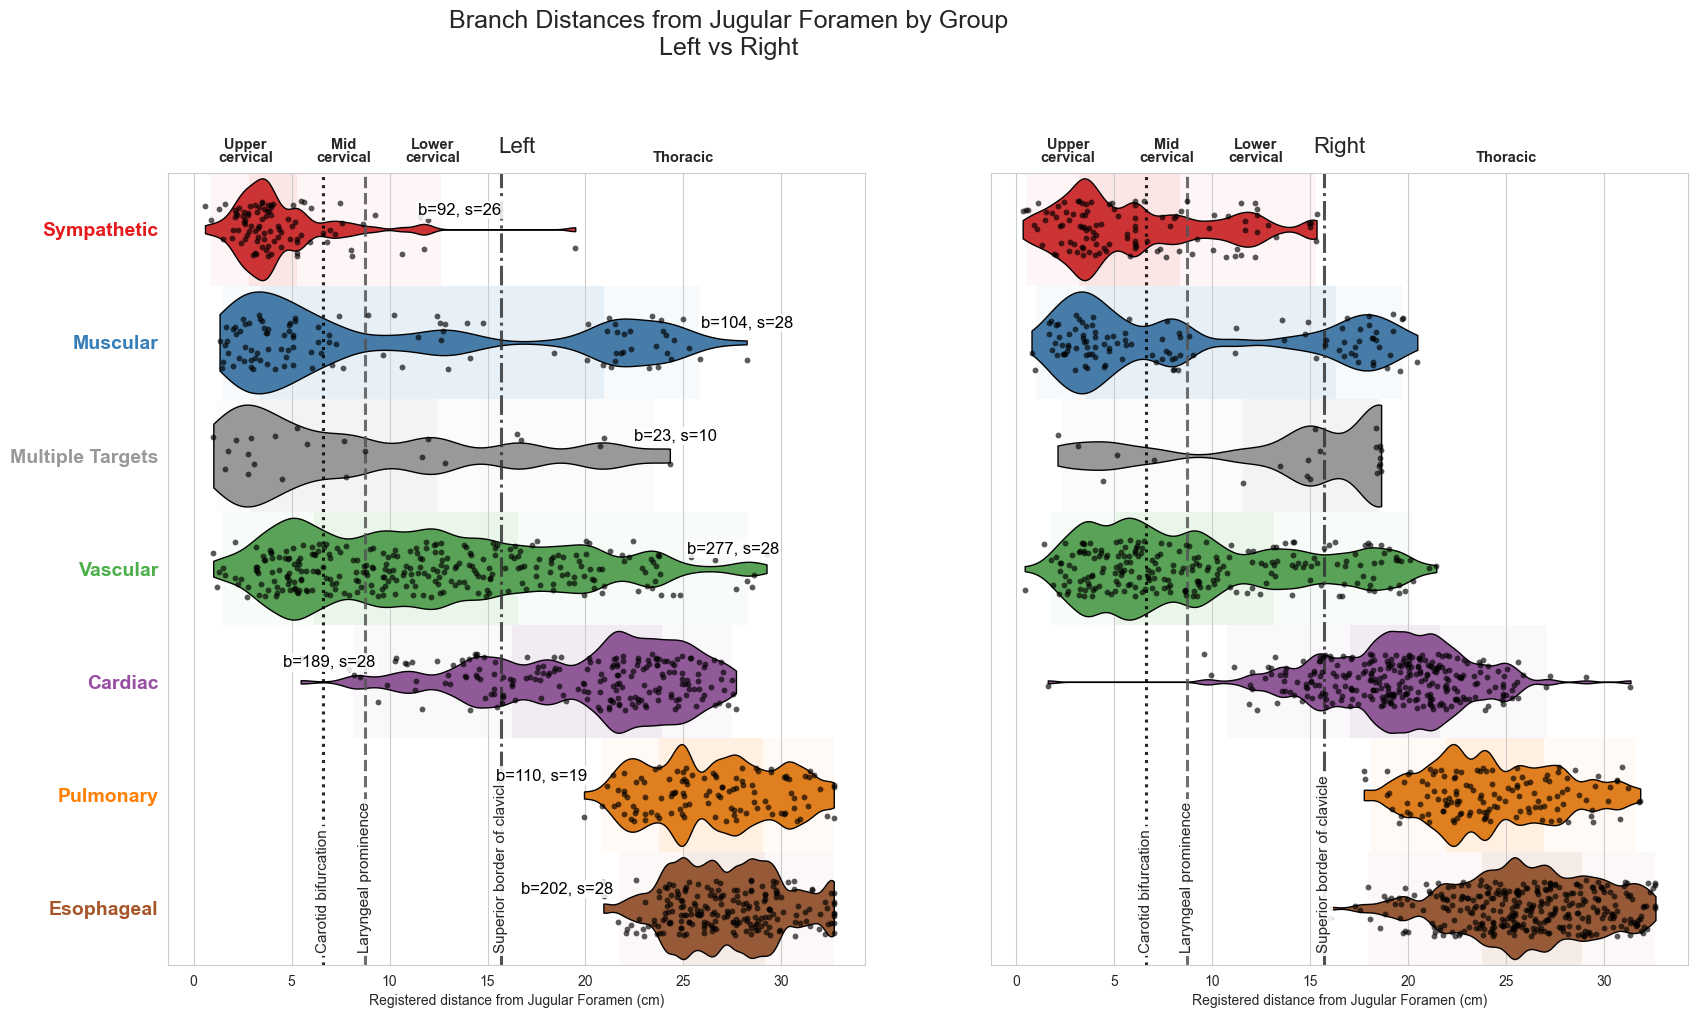


[Tuning]
  - BW_ADJUST=0.35
  - POINT_ALPHA=0.65, POINT_SIZE=4.2
  - GROUP_LABEL_FONTSIZE=14


In [3]:
# %matplotlib inline
# If needed (one-time installs in a notebook):
# !pip install pandas numpy matplotlib seaborn openpyxl tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors
from matplotlib.transforms import blended_transform_factory

# ============================================================
# GROUP-LEVEL LEFT vs RIGHT (v2 distance ONLY)
# - Same style as subgroup figure
# - NO stats layers
# - Robust b/s label placement (no overlap)
# - Added 2-line zone labels under Left/Right titles
# - Left y-axis group labels enlarged and colored by group
# - Keeps original y-axis logic as intact as possible
# ============================================================

# =========================
# CONFIG
# =========================
INPUT_XLSX = r"C:\Users\siyar\Desktop\vagus_nerve_explorer\vagus_atlas_dataset.xlsx"

if not Path(INPUT_XLSX).exists():
    for fb in [Path("vagus_atlas_dataset.xlsx"),
               Path("/mnt/data/vagus_atlas_dataset.xlsx")]:
        if fb.exists():
            INPUT_XLSX = str(fb)
            break

OUT_DIR = Path("Fig2_group_distributions")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = OUT_DIR / "Branch_Distances_from_JF_by_Group_Left_vs_Right__v2_zones_minimalfix.png"
DPI = 300

DIST_COL = "registered_distance_v2"   # v2 only, no renaming/dropping

# ---- Layout ----
FIG_W = 20
ROW_H_IN = 1.15
MIN_FIG_H = 7
LEFT_MARGIN = 0.22

# ---- KDE smoothing (lower = less smooth) ----
BW_ADJUST = 0.35
GRIDSIZE = 200
VIOLIN_WIDTH = 0.90

# ---- Points ----
SHOW_POINTS = True
POINT_SIZE = 4.2
POINT_ALPHA = 0.65
POINT_COLOR = "black"

# ---- Landmark lines ----
LANDMARKS_INFO = [
    {"label": "Carotid bifurcation",         "val": 6.592,  "color": "#000000", "style": ":",  "width": 2.2},
    {"label": "Laryngeal prominence",        "val": 8.725,  "color": "#555555", "style": "--", "width": 2.2},
    {"label": "Superior border of clavicle", "val": 15.683, "color": "#333333", "style": "-.", "width": 2.2},
]

# ---- Groups: order + colors ----
GROUP_ORDER = ["Sympathetic", "Muscular", "Multiple Targets", "Vascular", "Cardiac", "Pulmonary", "Esophageal"]
GROUP_COLORS = {
    "Sympathetic": "#e41a1c",
    "Muscular": "#377eb8",
    "Vascular": "#4daf4a",
    "Cardiac": "#984ea3",
    "Pulmonary": "#ff7f00",
    "Esophageal": "#a65628",
    "Multiple Targets": "#999999",
    "Other": "#000000",
}

# ---- Background shading (range + IQR within group, per side) ----
BG_ENABLE = True
BG_RANGE_MODE = "quantile"  # "quantile" or "minmax"
BG_QLO, BG_QHI = 0.01, 0.99
BG_LIGHTEN_AMOUNT = 0.92
BG_ALPHA = 0.45
BG_IQR_LIGHTEN_AMOUNT = 0.86
BG_IQR_ALPHA = 0.70

# ---- b/s label placement (matching your original logic) ----
PLACEMENT_QLO = 0.05
PLACEMENT_QHI = 0.95
LABEL_OFFSET_PTS = 22
LABEL_DY_PTS = 14
COUNT_FONTSIZE = 12
TEXT_BBOX = dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.2)

# If both sides have very little space, push labels outside axis frame
MIN_SPACE_FRAC_FOR_INSIDE = 0.12

# ---- Zone labels ----
ZONE_LABEL_Y = 1.01
ZONE_LABEL_FONTSIZE = 10.5
ZONE_TEXT_BBOX = dict(facecolor="white", edgecolor="none", alpha=0.90, pad=1.2)

# ---- Left y tick styling ----
GROUP_LABEL_FONTSIZE = 14
GROUP_LABEL_FONTWEIGHT = "bold"

# =========================
# HELPERS
# =========================
def find_col(df, candidates):
    cols = list(df.columns)
    lower_map = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def normalize_side(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"l", "left", "lt", "0"}: return "Left"
    if s in {"r", "right", "rt", "1"}: return "Right"
    return str(x).strip()

def lighten_color(color, amount=0.6):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    out = rgb * (1 - amount) + white * amount
    return tuple(out)

def draw_violinplot_robust(ax, sub_df, y_order):
    base_kwargs = dict(
        data=sub_df,
        x=DIST_COL,
        y="Group",
        order=y_order,
        hue="Group",
        hue_order=y_order,
        dodge=False,
        cut=0,
        inner=None,
        linewidth=1.0,
        width=VIOLIN_WIDTH,
        palette=GROUP_COLORS,
        gridsize=GRIDSIZE,
        ax=ax,
    )
    tries = [
        dict(base_kwargs, density_norm="width", bw_adjust=BW_ADJUST),
        dict(base_kwargs, scale="width",        bw_adjust=BW_ADJUST),
        dict(base_kwargs, density_norm="width", bw=BW_ADJUST),
        dict(base_kwargs, scale="width",        bw=BW_ADJUST),
    ]
    last_err = None
    for k in tries:
        try:
            sns.violinplot(**k)
            return
        except TypeError as e:
            last_err = e
    raise last_err

def draw_group_background(ax, side_df, y_order, xlim):
    if not BG_ENABLE:
        return
    g_to_i = {g: i for i, g in enumerate(y_order)}
    for g in y_order:
        vals = side_df.loc[side_df["Group"] == g, DIST_COL].dropna()
        if len(vals) < 2:
            continue

        if BG_RANGE_MODE.lower() == "minmax":
            x0, x1 = float(vals.min()), float(vals.max())
        else:
            x0, x1 = float(vals.quantile(BG_QLO)), float(vals.quantile(BG_QHI))

        x0 = max(x0, xlim[0]); x1 = min(x1, xlim[1])
        if x1 <= x0:
            continue

        i = g_to_i[g]
        y0 = i - 0.5
        y1 = i + 0.5

        base = GROUP_COLORS.get(g, "#bbbbbb")
        bg_col  = lighten_color(base, amount=BG_LIGHTEN_AMOUNT)
        iqr_col = lighten_color(base, amount=BG_IQR_LIGHTEN_AMOUNT)

        ax.add_patch(Rectangle((x0, y0), (x1 - x0), (y1 - y0),
                               facecolor=bg_col, edgecolor="none",
                               alpha=BG_ALPHA, zorder=-50))

        if len(vals) >= 4:
            q1, q3 = float(vals.quantile(0.25)), float(vals.quantile(0.75))
            q1 = max(q1, xlim[0]); q3 = min(q3, xlim[1])
            if q3 > q1:
                ax.add_patch(Rectangle((q1, y0), (q3 - q1), (y1 - y0),
                                       facecolor=iqr_col, edgecolor="none",
                                       alpha=BG_IQR_ALPHA, zorder=-49))

def build_group_to_y_map(ax):
    labels = [t.get_text() for t in ax.get_yticklabels()]
    ticks = list(ax.get_yticks())
    return {lab: float(y) for lab, y in zip(labels, ticks) if lab}

def add_bs_labels_no_overlap(ax, side_df, y_order, xlim, group_to_y, subj_col="Subject"):
    xspan = float(xlim[1] - xlim[0])
    min_space = MIN_SPACE_FRAC_FOR_INSIDE * xspan

    trans_outside = blended_transform_factory(ax.transAxes, ax.transData)

    n_outside = 0
    for g in y_order:
        tmp = side_df[side_df["Group"] == g]
        if tmp.empty:
            continue

        y0 = group_to_y.get(g, None)
        if y0 is None:
            continue

        b = int(len(tmp))
        s = int(tmp[subj_col].nunique())

        qlo = float(tmp[DIST_COL].quantile(PLACEMENT_QLO))
        qhi = float(tmp[DIST_COL].quantile(PLACEMENT_QHI))

        left_space  = qlo - xlim[0]
        right_space = xlim[1] - qhi

        if (left_space < min_space) and (right_space < min_space):
            place_right = (right_space >= left_space)
            x_ax = 1.01 if place_right else -0.01
            ha = "left" if place_right else "right"
            ax.text(
                x_ax, y0, f"b={b}, s={s}",
                transform=trans_outside,
                ha=ha, va="center",
                fontsize=COUNT_FONTSIZE,
                color="black",
                bbox=TEXT_BBOX,
                zorder=30,
                clip_on=False,
            )
            n_outside += 1
            continue

        place_right = (right_space >= left_space)
        x_anchor = qhi if place_right else qlo
        dx = +LABEL_OFFSET_PTS if place_right else -LABEL_OFFSET_PTS
        ha = "left" if place_right else "right"

        ax.annotate(
            f"b={b}, s={s}",
            xy=(x_anchor, y0), xycoords="data",
            xytext=(dx, LABEL_DY_PTS), textcoords="offset points",
            ha=ha, va="center",
            fontsize=COUNT_FONTSIZE,
            color="black",
            bbox=TEXT_BBOX,
            zorder=30,
            annotation_clip=False,
        )

    if n_outside:
        print(f"[Labels] {n_outside} label(s) were placed outside the axis frame due to limited space.")

def add_zone_labels(ax, xlim):
    carotid = LANDMARKS_INFO[0]["val"]
    laryngeal = LANDMARKS_INFO[1]["val"]
    clavicle = LANDMARKS_INFO[2]["val"]

    zone_edges = [xlim[0], carotid, laryngeal, clavicle, xlim[1]]
    zone_labels = [
        "Upper\ncervical",
        "Mid\ncervical",
        "Lower\ncervical",
        "Thoracic",
    ]

    x0, x1 = xlim
    span = x1 - x0

    for i, lab in enumerate(zone_labels):
        xc = 0.5 * (zone_edges[i] + zone_edges[i + 1])
        x_ax = (xc - x0) / span

        ax.text(
            x_ax, ZONE_LABEL_Y, lab,
            transform=ax.transAxes,
            ha="center", va="bottom",
            fontsize=ZONE_LABEL_FONTSIZE,
            fontweight="bold",
            linespacing=0.9,
            bbox=ZONE_TEXT_BBOX,
            clip_on=False,
            zorder=20,
        )

# =========================
# LOAD + PREPROCESS
# =========================
print(f"[Load] {INPUT_XLSX}")
df = pd.read_excel(INPUT_XLSX)
df.columns = [c.strip() for c in df.columns]
print(f"[Load] rows={len(df):,} cols={len(df.columns)}")

grp_col = find_col(df, ["Group", "Supergroup"])
if grp_col is None:
    raise ValueError("Could not find Group/Supergroup column.")
if grp_col != "Group":
    df = df.rename(columns={grp_col: "Group"})
    print(f"[Cols] Renamed '{grp_col}' -> 'Group'")

side_col = find_col(df, ["Side", "side", "NerveSide", "LR", "LeftRight", "left_right"])
if side_col is None:
    raise ValueError("Could not find Side column.")
if side_col != "Side":
    df = df.rename(columns={side_col: "Side"})
    print(f"[Cols] Renamed '{side_col}' -> 'Side'")

subj_col = find_col(df, ["Subject", "Donor", "Cadaver", "Specimen", "ID"])
if subj_col is None:
    raise ValueError("Could not find a subject/donor column (e.g., Subject).")
if subj_col != "Subject":
    df = df.rename(columns={subj_col: "Subject"})
    print(f"[Cols] Renamed '{subj_col}' -> 'Subject'")

if DIST_COL not in df.columns:
    raise ValueError(f"Missing required column '{DIST_COL}' in input file.")

df[DIST_COL] = pd.to_numeric(df[DIST_COL].astype(str).str.replace(",", ".", regex=False), errors="coerce")
df["Side"] = df["Side"].apply(normalize_side)

# Filter: branches only
df = df[df["Group"].astype(str).str.lower().ne("landmark")].copy()
df = df.dropna(subset=["Group", "Side", DIST_COL, "Subject"])
df = df[df["Side"].isin(["Left", "Right"])].copy()

print(f"[Data] rows after filtering: {len(df):,}")
print("[Data] side counts:", df["Side"].value_counts().to_dict())

present_groups = [g for g in GROUP_ORDER if g in set(df["Group"].unique())]
if not present_groups:
    present_groups = sorted(df["Group"].unique().tolist())

xmin = float(df[DIST_COL].min())
xmax = float(df[DIST_COL].max())
xpad = max(1.0, 0.05 * (xmax - xmin))
xlim = (xmin - xpad, xmax + xpad)

# =========================
# PLOT
# =========================
sns.set_style("whitegrid")

fig_h = max(MIN_FIG_H, ROW_H_IN * len(present_groups) + 2.8)
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, fig_h), sharey=True)
side_order = ["Left", "Right"]

for ax, side in zip(axes, side_order):
    sub_df = df[df["Side"] == side].copy()
    print(f"[Plot] Side={side}: rows={len(sub_df):,}")

    # background belts first
    draw_group_background(ax, sub_df, present_groups, xlim)

    # violins
    draw_violinplot_robust(ax, sub_df, present_groups)

    # points
    if SHOW_POINTS:
        sns.stripplot(
            data=sub_df,
            x=DIST_COL,
            y="Group",
            order=present_groups,
            ax=ax,
            color=POINT_COLOR,
            alpha=POINT_ALPHA,
            size=POINT_SIZE,
            jitter=0.25,
            zorder=5,
        )

    # remove legend
    leg = ax.get_legend()
    if leg:
        leg.remove()

    # landmarks
    for lm in LANDMARKS_INFO:
        ax.axvline(x=lm["val"], linestyle=lm["style"], color=lm["color"],
                   linewidth=lm["width"], alpha=0.85, zorder=1)
        ax.text(
            lm["val"], 0.015, lm["label"],
            rotation=90, transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=11,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.90, pad=2.0),
            zorder=10
        )

    ax.set_title(side, fontsize=16, pad=14)
    ax.set_xlabel("Registered distance from Jugular Foramen (cm)")
    ax.set_ylabel("")
    ax.set_xlim(*xlim)

    # only addition requested
    add_zone_labels(ax, xlim)

# Keep your original explicit y tick forcing
axes[0].set_yticks(np.arange(len(present_groups)))
axes[0].set_yticklabels(present_groups)
axes[1].tick_params(axis="y", labelleft=False)

# Style the EXISTING left-side y labels only
for tick, group in zip(axes[0].get_yticklabels(), present_groups):
    tick.set_fontsize(GROUP_LABEL_FONTSIZE)
    tick.set_fontweight(GROUP_LABEL_FONTWEIGHT)
    tick.set_color(GROUP_COLORS.get(group, "black"))

# Now that y ticks exist, compute y-maps and place b/s labels robustly
for ax, side in zip(axes, side_order):
    sub_df = df[df["Side"] == side].copy()
    group_to_y = build_group_to_y_map(ax)
    add_bs_labels_no_overlap(ax, sub_df, present_groups, xlim, group_to_y, subj_col="Subject")

fig.suptitle("Branch Distances from Jugular Foramen by Group\nLeft vs Right", fontsize=18, y=0.99)
plt.subplots_adjust(left=LEFT_MARGIN, right=0.98, top=0.84, wspace=0.18)

fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
print(f"[Saved] {OUT_PNG}")
plt.show()

print("\n[Tuning]")
print(f"  - BW_ADJUST={BW_ADJUST}")
print(f"  - POINT_ALPHA={POINT_ALPHA}, POINT_SIZE={POINT_SIZE}")
print(f"  - GROUP_LABEL_FONTSIZE={GROUP_LABEL_FONTSIZE}")

### Figure 3  ·  Subway map of subgroup prevalence, laterality, bilaterality

> **Paper caption (abridged):** Subway map of donor-level prevalence, laterality, and
> bilaterality of the Top-25 most frequent vagal subgroups. Background bubbles =
> 100% cohort; solid bubble diameter = % of donors. Subgroups colored by group,
> ordered proximal-to-distal.

**Inputs**: ANALYSIS.xlsx
**Outputs**: `Fig_Subway_4Lane_LRBT__Fixed100Container_Top25.png` ·
`SupplementaryTable_Top25_PresenceBreakdown_LRBT__MeanDist.csv`
**Runtime**: ~10 s


📥 Loading Excel: vagus_atlas_dataset.xlsx
✅ Filtered rows: 2,177
✅ Cohort N (unique subjects after cleanup): 28

Top-25 (Subgroup -> n_branch_rows):
Subgroup
Cardiopulmonary                        293
Esophageal Plexus                      259
Pulmonary                              239
Superior Cervical Ganglion             143
General Esophageal                     117
Common Carotid                         117
Pulmonary (Esophageal)                  99
Superficial Cardiac Plexus              92
Multiple Branches To Carotid Artery     74
Internal Jugular Vein                   65
General Vascular                        65
Internal Carotid Artery                 61
Laryngeal (SLN)                         58
Laryngeal (RLN)                         55
Sympathetic Trunk                       52
Pharyngeal                              46
Deep Cardiac Plexus                     42
Aorta                                   42
Carotid Bifurcation                     40
Carotid Sinus            

Rows:   0%|          | 0/31 [00:00<?, ?it/s]

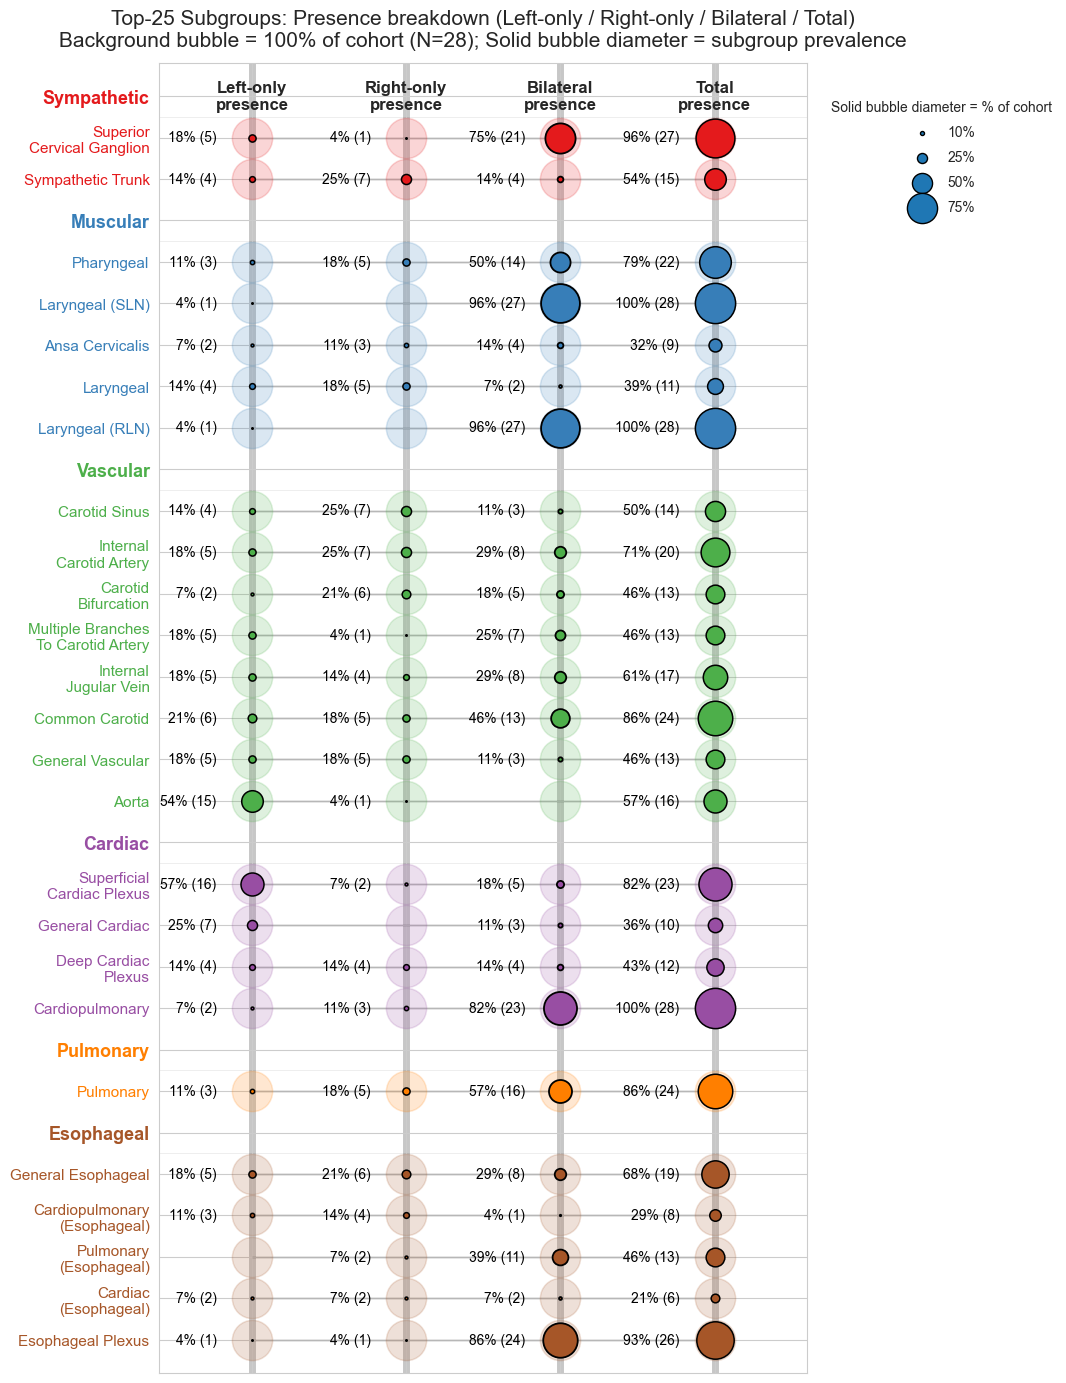


✅ Saved figure: Fig3_subway_map\Fig_Subway_4Lane_LRBT__Fixed100Container_Top25.png
✅ Saved table:  Fig3_subway_map\SupplementaryTable_Top25_PresenceBreakdown_LRBT__MeanDist.csv
✅ DONE.


In [4]:
# %matplotlib inline
# If needed (one-time installs in a notebook):
# !pip install pandas numpy matplotlib openpyxl tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# =========================
# CONFIG
# =========================
INPUT_XLSX = r"C:\Users\siyar\Desktop\vagus_nerve_explorer\vagus_atlas_dataset.xlsx"  # change if needed
DIST_COL   = "registered_distance_v2"  # v2 axis

TOP_K_GLOBAL = 25
OUT_DIR = Path("Fig3_subway_map")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_TABLE_CSV = OUT_DIR / f"SupplementaryTable_Top{TOP_K_GLOBAL}_PresenceBreakdown_LRBT__MeanDist.csv"
OUT_FIG_PNG   = OUT_DIR / f"Fig_Subway_4Lane_LRBT__Fixed100Container_Top{TOP_K_GLOBAL}.png"

# Group ordering + colors
group_order = ["Sympathetic", "Muscular", "Multiple Targets", "Vascular", "Cardiac", "Pulmonary", "Esophageal"]
group_colors = {
    "Sympathetic": "#e41a1c",
    "Muscular": "#377eb8",
    "Vascular": "#4daf4a",
    "Cardiac": "#984ea3",
    "Pulmonary": "#ff7f00",
    "Esophageal": "#a65628",
    "Multiple Targets": "#999999",
    "Other": "#000000"
}

# 4 lanes (Left-only / Right-only / Bilateral / Total)
xL, xR, xB, xT = -1.5, -0.5, 0.5, 1.5

# Layout
FIG_W = 15.8
ROW_H = 0.42
TITLE_FONTSIZE = 15

TRACK_ALPHA = 0.22
TRACK_LW = 5.0
CONNECT_ALPHA = 0.10
SHOW_CONNECTORS = True

# Tick labels
SUBGROUP_LABEL_FONTSIZE = 11
GROUP_HEADER_FONTSIZE   = 13
SUBGROUP_LABEL_WEIGHT   = "normal"
GROUP_HEADER_WEIGHT     = "bold"
WRAP_THRESHOLD = 18

# Bubble sizing (diameter-linear; matplotlib wants area in pts^2)
SIZE_MIN = 0
SIZE_MAX = int(1200 * 0.7)

# Bubble styling
NODE_EDGE = "black"
NODE_LW = 1.1
NODE_LW_CENTER = 1.3

SHOW_CONTAINER = True
CONTAINER_ALPHA_FACE = 0.18
CONTAINER_LW = 1.1

# Labels next to bubbles
SHOW_COUNT_LABELS = True
LABEL_FONTSIZE = 10
LABEL_PAD_PTS = 9.0
LABEL_EXTRA_PTS = 2.0

# In-panel column headers
SHOW_INPANEL_HEADERS = True
COLUMN_HEADER_FONTSIZE = 12
COLUMN_HEADER_WEIGHT = "bold"

# Legend marker color (size meaning only)
LEG_BLUE = "#1f77b4"

# =========================
# HELPERS
# =========================
def ensure_exists(p: Path, fallbacks=()):
    p = Path(p)
    if p.exists():
        return p
    for fb in fallbacks:
        fb = Path(fb)
        if fb.exists():
            return fb
    raise FileNotFoundError(f"Missing required file: {p}")

def normalize_side(x):
    s = str(x).strip().upper()
    if s.startswith("L"): return "L"
    if s.startswith("R"): return "R"
    return np.nan

def to_numeric_commas(s: pd.Series) -> pd.Series:
    # parses "1,8" -> 1.8
    return pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False), errors="coerce")

CANON_SUBGROUP_MAP = {
    "superior cervical ganglion": "Superior Cervical Ganglion",
    "ansa cervicalis": "Ansa Cervicalis",
    "carotid sinus": "Carotid Sinus",
    "internal carotid artery": "Internal Carotid Artery",
    "common carotid": "Common Carotid",
    "internal jugular vein": "Internal Jugular Vein",
    "superficial cardiac plexus": "Superficial Cardiac Plexus",
    "deep cardiac plexus": "Deep Cardiac Plexus",
    "esophageal plexus": "Esophageal Plexus",
}

def standardize_labels(dfin: pd.DataFrame) -> pd.DataFrame:
    """
    Minimal, manuscript-style cleanup:
      - ensure Group/Subgroup are strings
      - map Unspecified/General buckets -> General {Group} (for Vascular/Cardiac/Esophageal)
      - apply a small canonical casing map for common labels
    """
    df = dfin.copy()
    df["Group"] = df["Group"].astype(str).str.strip()
    df["Subgroup"] = df["Subgroup"].astype(str).str.strip()

    # unify common 'unspecified' tokens
    df["Subgroup"] = df["Subgroup"].replace({"General": "Unspecified"})

    # Esophageal special spellings (keep your existing style)
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"].str.lower() == "esophageal plexus"), "Subgroup"] = "Esophageal Plexus"
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"].str.lower() == "pulmonary"), "Subgroup"] = "Pulmonary (Esophageal)"
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"].str.lower() == "cardiac"), "Subgroup"] = "Cardiac (Esophageal)"
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"].str.lower() == "cardiopulmonary"), "Subgroup"] = "Cardiopulmonary (Esophageal)"

    # "Unspecified (X)" -> "Unspecified"
    df["Subgroup"] = df["Subgroup"].str.replace(r"^Unspecified\s*\(.+\)$", "Unspecified", regex=True)

    # For these Groups, convert Unspecified -> General {Group}
    for g in ["Vascular", "Cardiac", "Esophageal"]:
        m = (df["Group"] == g) & (df["Subgroup"] == "Unspecified")
        if m.any():
            df.loc[m, "Subgroup"] = f"General {g}"

    # Apply canonical casing for a few frequent labels (safe if already correct)
    lower = df["Subgroup"].str.lower()
    for k, v in CANON_SUBGROUP_MAP.items():
        df.loc[lower == k, "Subgroup"] = v

    return df

# diameter-linear mapping (return area)
def size_from_frac(frac, smin=SIZE_MIN, smax=SIZE_MAX):
    if pd.isna(frac):
        return 0.0
    frac = float(frac)
    if frac <= 0:
        return 0.0
    frac = np.clip(frac, 0.0, 1.0)
    d_min = np.sqrt(smin)
    d_max = np.sqrt(smax)
    d = d_min + (d_max - d_min) * frac
    return float(d ** 2)

def radius_pts_from_s(s_pts2: float) -> float:
    s_pts2 = max(float(s_pts2), 1e-12)
    return float(np.sqrt(s_pts2) / 2.0)

def label_left_of_dot(ax, x, y, txt, s_dot, s_container, dy_pts=0.0):
    r_dot = radius_pts_from_s(s_dot)
    r_con = radius_pts_from_s(s_container)
    dx = max(r_dot, r_con) + LABEL_PAD_PTS + LABEL_EXTRA_PTS
    ax.annotate(
        txt,
        xy=(x, y),
        xytext=(-dx, dy_pts),
        textcoords="offset points",
        ha="right", va="center",
        fontsize=LABEL_FONTSIZE,
        color="black",
        zorder=10
    )

def build_group_blocks(g_list):
    if not g_list:
        return []
    blocks = []
    start = 0
    for i in range(1, len(g_list) + 1):
        if i == len(g_list) or g_list[i] != g_list[start]:
            blocks.append((g_list[start], start, i))
            start = i
    return blocks

def wrap_best_two_lines(s: str, threshold: int = WRAP_THRESHOLD) -> str:
    s = str(s)
    if len(s) <= threshold:
        return s
    parts = s.split(" ")
    if len(parts) < 2:
        return s
    best = None
    for k in range(1, len(parts)):
        a = " ".join(parts[:k]).strip()
        b = " ".join(parts[k:]).strip()
        if not a or not b:
            continue
        score = max(len(a), len(b))
        balance = abs(len(a) - len(b))
        candidate = (score, balance, k, a, b)
        if best is None or candidate[:2] < best[:2]:
            best = candidate
    if best is None:
        return s
    _, _, _, a, b = best
    if max(len(a), len(b)) >= len(s) - 2:
        return s
    return a + "\n" + b

def prepare_y_axis_with_group_headers(counts_df):
    gs = counts_df["Group"].tolist()
    subs = counts_df["Subgroup"].tolist()
    blocks = build_group_blocks(gs)

    y_labels, y_meta = [], []
    for g, s, e in blocks:
        y_labels.append(g)
        y_meta.append({"kind": "header", "group": g})
        for j in range(s, e):
            wrapped = wrap_best_two_lines(subs[j], threshold=WRAP_THRESHOLD)
            y_labels.append(wrapped)
            y_meta.append({
                "kind": "subgroup",
                "group": gs[j],
                "subgroup": subs[j],
                "row_idx_in_counts": j
            })
    return y_labels, y_meta

def style_y_ticks(ax, y_meta):
    ticks = ax.get_yticklabels()
    for tick, meta in zip(ticks, y_meta):
        g = meta["group"]
        col = group_colors.get(g, group_colors["Other"])
        if meta["kind"] == "header":
            tick.set_color(col)
            tick.set_fontsize(GROUP_HEADER_FONTSIZE)
            tick.set_fontweight(GROUP_HEADER_WEIGHT)
        else:
            tick.set_color(col)
            tick.set_fontsize(SUBGROUP_LABEL_FONTSIZE)
            tick.set_fontweight(SUBGROUP_LABEL_WEIGHT)

def add_size_legend(ax, title, fracs=(0.10, 0.25, 0.50, 0.75), anchor=(1.02, 0.98)):
    handles = [
        ax.scatter([], [], s=size_from_frac(f), c=LEG_BLUE, edgecolors="black", linewidths=1.0)
        for f in fracs
    ]
    leg = ax.legend(
        handles,
        [f"{f:.0%}" for f in fracs],
        title=title,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=anchor,
        borderpad=0.3,
        labelspacing=0.8
    )
    return leg

def add_presence_headers(ax, y_row):
    ax.text(xL, y_row, "Left-only\npresence",  ha="center", va="center",
            fontsize=COLUMN_HEADER_FONTSIZE, fontweight=COLUMN_HEADER_WEIGHT, zorder=25)
    ax.text(xR, y_row, "Right-only\npresence", ha="center", va="center",
            fontsize=COLUMN_HEADER_FONTSIZE, fontweight=COLUMN_HEADER_WEIGHT, zorder=25)
    ax.text(xB, y_row, "Bilateral\npresence", ha="center", va="center",
            fontsize=COLUMN_HEADER_FONTSIZE, fontweight=COLUMN_HEADER_WEIGHT, zorder=25)
    ax.text(xT, y_row, "Total\npresence", ha="center", va="center",
            fontsize=COLUMN_HEADER_FONTSIZE, fontweight=COLUMN_HEADER_WEIGHT, zorder=25)

def fmt_presence(n: int, denom: int) -> str:
    pct = 100.0 * (n / denom) if denom > 0 else np.nan
    return f"{pct:.0f}% ({n})"

# =========================
# LOAD + CLEAN
# =========================
INPUT_XLSX = ensure_exists(
    INPUT_XLSX,
    fallbacks=[
        Path("/mnt/data/vagus_atlas_dataset.xlsx"),
        Path("vagus_atlas_dataset.xlsx"),
    ]
)

print(f"📥 Loading Excel: {INPUT_XLSX}")
df = pd.read_excel(INPUT_XLSX)
df.columns = [c.strip() for c in df.columns]

# Rename Supergroup -> Group if needed
if "Group" not in df.columns and "Supergroup" in df.columns:
    df = df.rename(columns={"Supergroup": "Group"})

required = ["Subject", "Side", "Group", "Subgroup", DIST_COL]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = standardize_labels(df)

df["Subject"] = df["Subject"].astype(str).str.strip()
df["Side_norm"] = df["Side"].apply(normalize_side)
df[DIST_COL] = to_numeric_commas(df[DIST_COL])

# Keep only branches (exclude landmark rows), valid side, valid distance for ordering
df = df[df["Group"] != "Landmark"].copy()
df = df[df[DIST_COL].notna()].copy()
df = df[df["Side_norm"].isin(["L", "R"])].copy()

N_COHORT = int(df["Subject"].nunique())
print(f"✅ Filtered rows: {len(df):,}")
print(f"✅ Cohort N (unique subjects after cleanup): {N_COHORT}")
if N_COHORT <= 0:
    raise ValueError("Cohort size computed as 0. Check Subject column/filters.")

# =========================
# TOP-25 selection (by branch rows)
# =========================
top = df["Subgroup"].value_counts().nlargest(TOP_K_GLOBAL)
keep_subs = top.index.tolist()
print(f"\nTop-{TOP_K_GLOBAL} (Subgroup -> n_branch_rows):")
print(top.to_string())

df_top = df[df["Subgroup"].isin(keep_subs)].copy()

# subgroup -> group (mode)
sub2g = df_top.groupby("Subgroup")["Group"].agg(lambda x: x.mode().iloc[0]).to_dict()

# mean distance (used for ordering + table, NOT drawn in the figure)
mean_map = df_top.groupby("Subgroup")[DIST_COL].mean()

rank_map = {g: i for i, g in enumerate(group_order)}
order_df = pd.DataFrame({
    "Subgroup": list(mean_map.index),
    "Group": [sub2g.get(s, "Other") for s in mean_map.index],
    "MeanDist": [float(mean_map[s]) for s in mean_map.index],
})
order_df["Rank"] = order_df["Group"].map(rank_map).fillna(999).astype(int)
order_df = order_df.sort_values(["Rank", "MeanDist"], ascending=[True, True]).reset_index(drop=True)
ordered_subgroups = order_df["Subgroup"].tolist()

# =========================
# SUBJECT-LEVEL PRESENCE (Left-only / Right-only / Bilateral / Total)
# =========================
presence = df_top.drop_duplicates(["Subject", "Side_norm", "Subgroup"])[["Subject", "Side_norm", "Subgroup"]].copy()
presence["present"] = 1

piv = presence.pivot_table(
    index=["Subject", "Subgroup"],
    columns="Side_norm",
    values="present",
    aggfunc="max",
    fill_value=0
)
if "L" not in piv.columns: piv["L"] = 0
if "R" not in piv.columns: piv["R"] = 0
piv = piv[["L", "R"]].astype(int)

piv["Bilateral"]  = ((piv["L"] == 1) & (piv["R"] == 1)).astype(int)
piv["Left_only"]  = ((piv["L"] == 1) & (piv["R"] == 0)).astype(int)
piv["Right_only"] = ((piv["L"] == 0) & (piv["R"] == 1)).astype(int)
piv["Any"]        = ((piv["L"] == 1) | (piv["R"] == 1)).astype(int)

n_left_only  = piv["Left_only"].groupby(level=1).sum()
n_right_only = piv["Right_only"].groupby(level=1).sum()
n_bilat      = piv["Bilateral"].groupby(level=1).sum()
n_any        = piv["Any"].groupby(level=1).sum()

counts_df = pd.DataFrame({
    "Group": [sub2g.get(s, "Other") for s in ordered_subgroups],
    "Subgroup": ordered_subgroups,
    "Mean distance (cm)": [float(mean_map.get(s, np.nan)) for s in ordered_subgroups],
    "n_left_only_subjects":  [int(n_left_only.get(s, 0)) for s in ordered_subgroups],
    "n_right_only_subjects": [int(n_right_only.get(s, 0)) for s in ordered_subgroups],
    "n_bilateral_subjects":  [int(n_bilat.get(s, 0)) for s in ordered_subgroups],
    "n_any_subjects":        [int(n_any.get(s, 0)) for s in ordered_subgroups],
})

# Sanity: Any = Left_only + Right_only + Bilateral
viol = (counts_df["n_any_subjects"] !=
        (counts_df["n_left_only_subjects"] + counts_df["n_right_only_subjects"] + counts_df["n_bilateral_subjects"])).sum()
print(f"\nSanity check (Any = Left_only + Right_only + Bilateral) violations: {int(viol)}")

# Shares for plotting
counts_df["share_Left_only"]  = counts_df["n_left_only_subjects"]  / N_COHORT
counts_df["share_Right_only"] = counts_df["n_right_only_subjects"] / N_COHORT
counts_df["share_Bilateral"]  = counts_df["n_bilateral_subjects"]  / N_COHORT
counts_df["share_Any"]        = counts_df["n_any_subjects"]        / N_COHORT

# =========================
# FINAL SUPPLEMENTARY TABLE (exact columns + exact formatting)
# =========================
supp_table = pd.DataFrame({
    "Group": counts_df["Group"],
    "Subgroup": counts_df["Subgroup"],
    "Mean distance (cm)": counts_df["Mean distance (cm)"].round(2),
    "Left-only presence":  [fmt_presence(n, N_COHORT) for n in counts_df["n_left_only_subjects"]],
    "Right-only presence": [fmt_presence(n, N_COHORT) for n in counts_df["n_right_only_subjects"]],
    "Bilateral presence":  [fmt_presence(n, N_COHORT) for n in counts_df["n_bilateral_subjects"]],
    "Total presence":      [fmt_presence(n, N_COHORT) for n in counts_df["n_any_subjects"]],
})

supp_table.to_csv(OUT_TABLE_CSV, index=False)
print(f"💾 Saved supplementary table: {OUT_TABLE_CSV}")

print("\n[Preview] Supplementary table (first 10 rows):")
print(supp_table.head(10).to_string(index=False))

# =========================
# FIGURE (NO mean-distance column shown)
# =========================
# Insert group headers into the y-axis
y_labels, y_meta = prepare_y_axis_with_group_headers(counts_df)
FIRST_HEADER_ROW_I = next((i for i, m in enumerate(y_meta) if m["kind"] == "header"), 0)

# Fixed 100% container (background bubble)
S_CONTAINER_100 = size_from_frac(1.0)

K = len(y_meta)
fig_h = max(8, ROW_H * K + 1.7)
fig, ax = plt.subplots(figsize=(FIG_W, fig_h))

# Track lines
ax.vlines([xL, xR, xB, xT], ymin=-0.8, ymax=K-0.2, colors="black",
          linewidth=TRACK_LW, alpha=TRACK_ALPHA, zorder=0)

print("\n🎨 Rendering presence breakdown figure (Left-only / Right-only / Bilateral / Total)...")
for i in tqdm(range(K), desc="Rows"):
    meta = y_meta[i]
    if meta["kind"] == "header":
        ax.hlines(y=i+0.5, xmin=-2.1, xmax=2.1, colors="black", linewidth=0.6, alpha=0.08, zorder=0)
        continue

    j = meta["row_idx_in_counts"]
    g = meta["group"]
    col = group_colors.get(g, group_colors["Other"])

    # counts
    vL = int(counts_df.loc[j, "n_left_only_subjects"])
    vR = int(counts_df.loc[j, "n_right_only_subjects"])
    vB = int(counts_df.loc[j, "n_bilateral_subjects"])
    vT = int(counts_df.loc[j, "n_any_subjects"])

    # fractions
    fL = float(counts_df.loc[j, "share_Left_only"])
    fR = float(counts_df.loc[j, "share_Right_only"])
    fB = float(counts_df.loc[j, "share_Bilateral"])
    fT = float(counts_df.loc[j, "share_Any"])

    # sizes
    s_container = S_CONTAINER_100
    sL = size_from_frac(fL)
    sR = size_from_frac(fR)
    sB = size_from_frac(fB)
    sT = size_from_frac(fT)

    if SHOW_CONNECTORS:
        ax.hlines(y=i, xmin=xL, xmax=xT, colors="black", linewidth=2.0,
                  alpha=CONNECT_ALPHA, zorder=1)

    # background container
    if SHOW_CONTAINER:
        ax.scatter([xL, xR, xB, xT], [i, i, i, i],
                   s=s_container, c=col, alpha=CONTAINER_ALPHA_FACE,
                   edgecolors=col, linewidths=CONTAINER_LW, zorder=2)

    # solid bubbles
    if sL > 0: ax.scatter([xL], [i], s=sL, c=col, edgecolors=NODE_EDGE, linewidths=NODE_LW, zorder=5)
    if sR > 0: ax.scatter([xR], [i], s=sR, c=col, edgecolors=NODE_EDGE, linewidths=NODE_LW, zorder=5)
    if sB > 0: ax.scatter([xB], [i], s=sB, c=col, edgecolors=NODE_EDGE, linewidths=NODE_LW_CENTER, zorder=6)
    if sT > 0: ax.scatter([xT], [i], s=sT, c=col, edgecolors=NODE_EDGE, linewidths=NODE_LW, zorder=6)

    # labels
    if SHOW_COUNT_LABELS:
        if vL > 0:
            label_left_of_dot(ax, xL, i, f"{fL*100:.0f}% ({vL})", s_dot=sL, s_container=s_container)
        if vR > 0:
            label_left_of_dot(ax, xR, i, f"{fR*100:.0f}% ({vR})", s_dot=sR, s_container=s_container)
        if vB > 0:
            label_left_of_dot(ax, xB, i, f"{fB*100:.0f}% ({vB})", s_dot=sB, s_container=s_container)
        # total always
        label_left_of_dot(ax, xT, i, f"{fT*100:.0f}% ({vT})", s_dot=sT, s_container=s_container)

# axes styling
ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-0.8, K-0.2)
ax.invert_yaxis()

ax.set_xticks([xL, xR, xB, xT])
ax.set_xticklabels(["", "", "", ""])
ax.tick_params(axis="x", length=0)

ax.set_yticks(np.arange(K))
ax.set_yticklabels(y_labels)
style_y_ticks(ax, y_meta)

ax.set_title(
    f"Top-{TOP_K_GLOBAL} Subgroups: Presence breakdown (Left-only / Right-only / Bilateral / Total)\n"
    f"Background bubble = 100% of cohort (N={N_COHORT}); Solid bubble diameter = subgroup prevalence",
    fontsize=TITLE_FONTSIZE,
    pad=12
)

if SHOW_INPANEL_HEADERS:
    add_presence_headers(ax, y_row=FIRST_HEADER_ROW_I)

add_size_legend(ax, title="Solid bubble diameter = % of cohort", anchor=(1.02, 0.98))

fig.subplots_adjust(left=0.38, right=0.79, top=0.93, bottom=0.04)

fig.savefig(OUT_FIG_PNG, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"\n✅ Saved figure: {OUT_FIG_PNG}")
print(f"✅ Saved table:  {OUT_TABLE_CSV}")
print("✅ DONE.")

### Figure 4  ·  Subgroup mega violin (Top-25, branch distances by subgroup)

> **Paper caption (abridged):** Subgroup-level branch distances on the template
> vagus nerve. Each row is a subgroup; left/right panels with paired Wilcoxon
> stats; vertical brackets mark within-block selected pairs (Bonferroni).

**Inputs**: ANALYSIS.xlsx
**Outputs**: `Branch_Distances_from_Jugular_Foramen_by_Group_Subgroup_LR.png` ·
`LeftRight_PairedStats_SIGONLY_CONNECTORS.csv` ·
`VerticalBracket_SelectedPairs_BlockBonf_bySide.csv`
**Runtime**: ~30 s


In [ ]:
# %matplotlib inline
# If needed (one-time installs in a notebook):
# !pip install pandas numpy matplotlib seaborn openpyxl tqdm scipy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from matplotlib.patches import Patch, Rectangle, ConnectionPatch
from matplotlib.lines import Line2D
from matplotlib.collections import PolyCollection
import matplotlib.colors as mcolors
import textwrap
from scipy.stats import wilcoxon

# ==========================================
# USER CONFIG
# ==========================================
INPUT_XLSX = r"C:\Users\siyar\Desktop\vagus_nerve_explorer\vagus_atlas_dataset.xlsx"

# fallback if you're running somewhere else
if not Path(INPUT_XLSX).exists():
    for fb in [
        Path("vagus_atlas_dataset.xlsx"),
        Path("/mnt/data/vagus_atlas_dataset.xlsx"),
        Path("vagus_atlas_analysis.xlsx"),
        Path("/mnt/data/vagus_atlas_analysis.xlsx"),
    ]:
        if fb.exists():
            INPUT_XLSX = str(fb)
            break

OUTPUT_DIR = Path("Fig4_subgroup_violins")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 25

# If auto-detection fails, set these explicitly:
SIDE_COL = None      # e.g., "Side"
SUBJECT_COL = None   # e.g., "Subject" / "Donor" / "Cadaver_ID"

# ---- Layout controls ----
Y_SPACING      = 2
VIOLIN_WIDTH   = 1.6
SUPERGROUP_GAP = 1.5

FIG_WIDTH_IN   = 36
ROW_HEIGHT_IN  = 0.62
MIN_FIG_H_IN   = 22
LEFT_MARGIN    = 0.20

# ---- KDE smoothing controls ----
BW_ADJUST = 0.55
GRIDSIZE  = 200

# ---- Wrap left-side labels to 2 lines ----
WRAP_WIDTH = 22
FORCE_PAREN_NEWLINE = True
SUBGROUP_INDENT = "   "

# ---- Annotation placement controls ----
PLACEMENT_QLO = 0.05
PLACEMENT_QHI = 0.95

# push b/s labels outward
LABEL_OFFSET_PTS = 25
LABEL_CLIP = False

# ---- Fonts ----
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 15,
    "figure.titlesize": 24,
})
TITLE_FONTSIZE = 24
SIDE_TITLE_FONTSIZE = 22
LEFT_LABEL_FONTSIZE = 24
GROUP_HEADER_FONTSIZE = 26
LANDMARK_LABEL_FONTSIZE = 15
COUNT_FONTSIZE = 16

# ---- Points ----
SHOW_POINTS  = True
POINT_SIZE   = 4.5
POINT_ALPHA  = 0.70
POINT_COLOR  = "black"

# ---- Landmark lines (fixed; you can swap to dataset-derived later if you want) ----
LANDMARKS_INFO = [
    {"label": "Carotid bifurcation",         "val": 6.592,  "color": "#000000", "style": ":",  "width": 2.5},
    {"label": "Laryngeal prominence",        "val": 8.725,  "color": "#555555", "style": "--", "width": 2.5},
    {"label": "Superior border of clavicle", "val": 15.683, "color": "#333333", "style": "-.", "width": 2.5},
]

# ---- Supergroup scheme ----
SUPERGROUP_COLORS = {
    "Sympathetic": "#e41a1c",
    "Muscular": "#377eb8",
    "Vascular": "#4daf4a",
    "Cardiac": "#984ea3",
    "Pulmonary": "#ff7f00",
    "Esophageal": "#a65628",
    "Multiple Targets": "#999999",
    "Other": "#000000",
}
SUPERGROUP_ORDER = ["Sympathetic", "Muscular", "Multiple Targets", "Vascular", "Cardiac", "Pulmonary", "Esophageal"]

# ---- Supergroup background shading ----
BG_ENABLE = True
BG_RANGE_MODE = "quantile"   # "quantile" recommended, or "minmax"
BG_RANGE_QLO  = 0.01
BG_RANGE_QHI  = 0.99

BG_LIGHTEN_AMOUNT     = 0.92
BG_ALPHA              = 0.55
BG_IQR_LIGHTEN_AMOUNT = 0.86
BG_IQR_ALPHA          = 0.75
BG_ZORDER             = -30
BG_IQR_ZORDER         = -29

# ---- LR connectors (SIGNIFICANT ONLY) ----
LR_CONNECT_ENABLE   = True
LR_CONN_LINESTYLE   = ":"     # dotted
LR_CONN_LINEWIDTH   = 1.8
LR_CONN_ALPHA       = 0.85

LR_LABEL_FONTSIZE   = 20
LR_LABEL_BBOX       = dict(facecolor="white", edgecolor="none", alpha=0.92, pad=1.1)

# Connector anchors at "violin ends"
LR_CONN_QLO = 0.01
LR_CONN_QHI = 0.99
LR_CONN_PAD = 0.00

# ---- Paired significance gating (Wilcoxon on per-subject medians) ----
LR_SIG_ENABLE      = True
LR_SIG_ALPHA       = 0.05
LR_SIG_METHOD      = "bonf_within_group"   # within-supergroup Bonferroni (manuscript default)
LR_SIG_LABEL       = "p"      # display "p" with within-supergroup Bonferroni
LR_SIG_MIN_PAIRS   = 6
LR_SIG_SHOW_ONLY   = True
LR_SIG_STAR_ENABLE = True

# ---- Divider line at header rows ----
HEADER_DIVIDER_ENABLE = True
HEADER_DIVIDER_ALPHA  = 0.18
HEADER_DIVIDER_LW     = 1.2

# ---- Saving ----
DPI = 300
OUT_FIG      = OUTPUT_DIR / "Branch_Distances_from_Jugular_Foramen_by_Group_Subgroup_LR.png"
OUT_LR_TABLE = OUTPUT_DIR / "LeftRight_PairedStats_SIGONLY_CONNECTORS.csv"

SAVE_SEPARATE_LEGEND = True
OUT_LEG = OUTPUT_DIR / "Legend_Branch_Distances_from_Jugular_Foramen.png"

# ==========================================
# Helpers
# ==========================================
def find_col(df, candidates):
    cols = list(df.columns)
    lower_map = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def auto_find_subject_col(df):
    preferred = ["Subject", "subject", "Donor", "donor", "Cadaver", "cadaver", "Specimen", "specimen",
                 "SpecimenID", "specimen_id", "Case", "case", "Patient", "patient", "ID", "id"]
    c = find_col(df, preferred)
    if c is not None:
        return c
    for col in df.columns:
        if any(k in col.lower() for k in ["subject", "donor", "cadaver", "specimen", "case", "patient", "id"]):
            return col
    return None

def normalize_side(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"l", "left", "lt"}: return "Left"
    if s in {"r", "right", "rt"}: return "Right"
    if s in {"0"}: return "Left"
    if s in {"1"}: return "Right"
    return str(x).strip()

def lighten_color(color, amount=0.6):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    out = rgb * (1 - amount) + white * amount
    return tuple(out)

def standardize_subgroups(df):
    df = df.copy()
    df["Subgroup"] = df["Subgroup"].astype(str).str.strip()
    df["Subgroup"] = df["Subgroup"].replace("General", "Unspecified")

    # keep your legacy harmonizations (safe if no matches)
    df.loc[(df["Supergroup"] == "Pulmonary") & (df["Subgroup"] == "Unspecified"), "Subgroup"] = "Pulmonary"
    df.loc[(df["Supergroup"] == "Esophageal") & (df["Subgroup"].str.lower() == "pulmonary"), "Subgroup"] = "Pulmonary (Esophageal)"
    df.loc[(df["Supergroup"] == "Esophageal") & (df["Subgroup"].str.lower() == "cardiac"), "Subgroup"] = "Cardiac (Esophageal)"
    df.loc[(df["Supergroup"] == "Esophageal") & (df["Subgroup"].str.lower() == "cardiopulmonary"), "Subgroup"] = "Cardiopulmonary (Esophageal)"
    df.loc[(df["Supergroup"] == "Esophageal") & (df["Subgroup"].str.lower() == "esophageal plexus"), "Subgroup"] = "Esophageal Plexus"

    for sg in ["Esophageal", "Cardiac", "Vascular", "Muscular", "Sympathetic"]:
        mask = (df["Supergroup"] == sg) & (df["Subgroup"] == "Unspecified")
        if mask.any():
            df.loc[mask, "Subgroup"] = f"Unspecified ({sg})"
    return df

def wrap_label_2lines(s, width=22, force_paren_newline=True):
    s = str(s)
    if force_paren_newline and " (" in s:
        return s.replace(" (", "\n(")
    lines = textwrap.wrap(s, width=width, break_long_words=False, break_on_hyphens=False)
    if len(lines) <= 1:
        return s
    if len(lines) == 2:
        return "\n".join(lines)
    return lines[0] + "\n" + (lines[1] + "…")

def draw_violinplot_robust_no_sex(ax, sub_df, y_order_keys):
    base_kwargs = dict(
        data=sub_df,
        x="registered_distance",
        y="YKey",
        order=y_order_keys,
        hue="Supergroup",
        hue_order=SUPERGROUP_ORDER,
        dodge=False,
        cut=0,
        inner=None,
        linewidth=1.0,
        width=VIOLIN_WIDTH,
        palette=SUPERGROUP_COLORS,
        gridsize=GRIDSIZE,
        ax=ax,
    )
    tries = [
        dict(base_kwargs, density_norm="width", bw_adjust=BW_ADJUST),
        dict(base_kwargs, scale="width",        bw_adjust=BW_ADJUST),
        dict(base_kwargs, density_norm="width", bw=BW_ADJUST),
        dict(base_kwargs, scale="width",        bw=BW_ADJUST),
    ]
    last_err = None
    for k in tries:
        try:
            sns.violinplot(**k)
            return
        except TypeError as e:
            last_err = e
    raise last_err

def build_y_axis_with_headers(ordered_subs, subgroup_to_supergroup):
    y_order_keys = []
    y_display_lbls = []
    y_meta = []

    def sg_of(sub):
        return subgroup_to_supergroup.get(sub, "Other")

    if not ordered_subs:
        return y_order_keys, y_display_lbls, y_meta

    cur_sg = sg_of(ordered_subs[0])
    block = [ordered_subs[0]]

    for sub in ordered_subs[1:]:
        sg = sg_of(sub)
        if sg == cur_sg:
            block.append(sub)
        else:
            header_key = f"__HEADER__{cur_sg}__"
            y_order_keys.append(header_key)
            y_display_lbls.append(cur_sg)
            y_meta.append({"kind": "header", "supergroup": cur_sg, "key": header_key})

            for bsub in block:
                y_order_keys.append(bsub)
                y_display_lbls.append(SUBGROUP_INDENT + wrap_label_2lines(bsub, width=WRAP_WIDTH, force_paren_newline=FORCE_PAREN_NEWLINE))
                y_meta.append({"kind": "subgroup", "supergroup": cur_sg, "subgroup": bsub, "key": bsub})

            cur_sg = sg
            block = [sub]

    header_key = f"__HEADER__{cur_sg}__"
    y_order_keys.append(header_key)
    y_display_lbls.append(cur_sg)
    y_meta.append({"kind": "header", "supergroup": cur_sg, "key": header_key})

    for bsub in block:
        y_order_keys.append(bsub)
        y_display_lbls.append(SUBGROUP_INDENT + wrap_label_2lines(bsub, width=WRAP_WIDTH, force_paren_newline=FORCE_PAREN_NEWLINE))
        y_meta.append({"kind": "subgroup", "supergroup": cur_sg, "subgroup": bsub, "key": bsub})

    return y_order_keys, y_display_lbls, y_meta

def compute_custom_y_positions_with_headers(y_meta, y_spacing=1.45, header_gap=0.55):
    n = len(y_meta)
    if n == 0:
        return [], [0, 1]

    y_targets = [0.0]
    for i in range(1, n):
        step = float(y_spacing)
        if y_meta[i]["kind"] == "header":
            step += float(header_gap)
        y_targets.append(y_targets[-1] + step)

    if n == 1:
        y_edges = [y_targets[0] - 0.5, y_targets[0] + 0.5]
        return y_targets, y_edges

    diffs = np.diff(y_targets)
    first_step = float(diffs[0])
    last_step  = float(diffs[-1])

    y_edges = [y_targets[0] - 0.5 * first_step]
    for i in range(1, n):
        y_edges.append(0.5 * (y_targets[i - 1] + y_targets[i]))
    y_edges.append(y_targets[-1] + 0.5 * last_step)

    return y_targets, y_edges

def apply_custom_row_positions(ax, n_cats, y_targets, y_edges):
    if n_cats <= 0:
        return

    shift = {i: float(y_targets[i]) - float(i) for i in range(n_cats)}

    # Shift violin bodies
    for col in ax.collections:
        if isinstance(col, PolyCollection):
            paths = col.get_paths()
            if not paths:
                continue
            v0 = paths[0].vertices
            cy = float(np.mean(v0[:, 1]))
            i = int(np.round(cy))
            if i not in shift:
                continue
            dy = shift[i]
            for p in paths:
                p.vertices[:, 1] += dy

    # Shift scatter/strip points
    for col in ax.collections:
        if isinstance(col, PolyCollection):
            continue
        if hasattr(col, "get_offsets"):
            offs = col.get_offsets()
            if offs is None or len(offs) == 0:
                continue
            ys = offs[:, 1]
            idx = np.round(ys).astype(int)
            dy = np.array([shift.get(int(i), 0.0) for i in idx], dtype=float)
            offs[:, 1] = ys + dy
            col.set_offsets(offs)

    ax.set_yticks(y_targets)
    ax.set_ylim(y_edges[-1], y_edges[0])

def style_y_ticks_with_headers(ax, y_meta):
    ticks = ax.get_yticklabels()
    for tick, meta in zip(ticks, y_meta):
        sg = meta.get("supergroup", "Other")
        col = SUPERGROUP_COLORS.get(sg, SUPERGROUP_COLORS["Other"])
        if meta["kind"] == "header":
            tick.set_color(col)
            tick.set_fontsize(GROUP_HEADER_FONTSIZE)
            tick.set_fontweight("bold")
        else:
            tick.set_color(col)
            tick.set_fontsize(LEFT_LABEL_FONTSIZE)
            tick.set_fontweight("normal")

def draw_header_dividers(ax, y_meta, y_targets, xlim):
    if not HEADER_DIVIDER_ENABLE:
        return
    for i, meta in enumerate(y_meta):
        if meta["kind"] == "header":
            y = float(y_targets[i])
            ax.hlines(y=y, xmin=xlim[0], xmax=xlim[1],
                     colors="black", linewidth=HEADER_DIVIDER_LW,
                     alpha=HEADER_DIVIDER_ALPHA, zorder=2)

def draw_supergroup_background(ax, side_df, y_meta, y_edges, xlim, supergroup_colors):
    if not BG_ENABLE:
        return

    sg_to_idxs = {}
    for i, meta in enumerate(y_meta):
        if meta["kind"] != "subgroup":
            continue
        sg = meta.get("supergroup", "Other")
        sg_to_idxs.setdefault(sg, []).append(i)

    for sg in SUPERGROUP_ORDER + ["Other"]:
        idxs = sg_to_idxs.get(sg, [])
        if not idxs:
            continue

        ymin = float(y_edges[min(idxs)])
        ymax = float(y_edges[max(idxs) + 1])

        base = supergroup_colors.get(sg, "#bbbbbb")
        bg_col  = lighten_color(base, amount=BG_LIGHTEN_AMOUNT)
        iqr_col = lighten_color(base, amount=BG_IQR_LIGHTEN_AMOUNT)

        vals = side_df.loc[side_df["Supergroup"] == sg, "registered_distance"].dropna()
        if len(vals) < 2:
            continue

        if BG_RANGE_MODE.lower() == "minmax":
            x0 = float(vals.min()); x1 = float(vals.max())
        else:
            x0 = float(vals.quantile(BG_RANGE_QLO))
            x1 = float(vals.quantile(BG_RANGE_QHI))

        x0 = max(x0, xlim[0]); x1 = min(x1, xlim[1])
        if x1 <= x0:
            continue

        ax.add_patch(Rectangle((x0, ymin), (x1 - x0), (ymax - ymin),
                               facecolor=bg_col, edgecolor="none",
                               alpha=BG_ALPHA, zorder=BG_ZORDER))

        if len(vals) >= 4:
            q1 = float(vals.quantile(0.25))
            q3 = float(vals.quantile(0.75))
            q1 = max(q1, xlim[0]); q3 = min(q3, xlim[1])
            if q3 > q1:
                ax.add_patch(Rectangle((q1, ymin), (q3 - q1), (ymax - ymin),
                                       facecolor=iqr_col, edgecolor="none",
                                       alpha=BG_IQR_ALPHA, zorder=BG_IQR_ZORDER))

def fdr_bh(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out = np.full_like(pvals, np.nan, dtype=float)
    idx = np.where(np.isfinite(pvals))[0]
    m = len(idx)
    if m == 0:
        return out
    pv = pvals[idx]
    order = np.argsort(pv)
    ranked = pv[order]
    q = ranked * (m / (np.arange(1, m + 1)))
    q = np.minimum.accumulate(q[::-1])[::-1]
    out[idx[order]] = np.clip(q, 0, 1)
    return out

def bonferroni_vec(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out = np.full_like(pvals, np.nan, dtype=float)
    idx = np.where(np.isfinite(pvals))[0]
    m = len(idx)
    if m == 0:
        return out
    out[idx] = np.clip(pvals[idx] * m, 0, 1)
    return out

def p_to_stars(p):
    if not np.isfinite(p): return ""
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return ""

def fmt_p(p):
    if not np.isfinite(p): return "NA"
    if p < 1e-4: return f"{p:.1e}"
    return f"{p:.4f}"

# ==========================================
# 1) Load + preprocess (NEW dataset compatible)
# ==========================================
print(f"[Setup] Input:  {INPUT_XLSX}")
print(f"[Setup] Output: {OUTPUT_DIR.resolve()}")
print(f"[Env] seaborn={sns.__version__}")

print("[1/7] Loading dataset...")
df = pd.read_excel(INPUT_XLSX)
df.columns = [c.strip() for c in df.columns]
print(f"[1/7] Loaded: {df.shape[0]:,} rows x {df.shape[1]:,} cols")

# ---- Normalize Group/Supergroup naming ----
grp_col = find_col(df, ["Supergroup", "Group"])
if grp_col is None:
    raise ValueError("Could not find 'Group' or 'Supergroup' column.")
if grp_col != "Supergroup":
    df = df.rename(columns={grp_col: "Supergroup"})
    print(f"[Cols] Renamed '{grp_col}' -> 'Supergroup' (internal standard).")

# ---- FORCE registered_distance_v2 ----
dist_v2_col = find_col(df, ["registered_distance_v2", "Registered_Distance_V2", "Registered Distance V2"])
if dist_v2_col is None:
    raise ValueError("Missing 'registered_distance_v2' in this file. Use the output ANALYSIS file from your pipeline.")

# IMPORTANT: avoid duplicate 'registered_distance'
if "registered_distance" in df.columns and dist_v2_col != "registered_distance":
    if "registered_distance_legacy" not in df.columns:
        df = df.rename(columns={"registered_distance": "registered_distance_legacy"})
        print("[Cols] Renamed existing 'registered_distance' -> 'registered_distance_legacy'.")
    else:
        df = df.drop(columns=["registered_distance"])
        print("[Cols] Dropped existing 'registered_distance' (legacy already present).")

if dist_v2_col != "registered_distance":
    df = df.rename(columns={dist_v2_col: "registered_distance"})
    print(f"[Cols] Renamed '{dist_v2_col}' -> 'registered_distance' (internally = v2).")

# final safety: remove any duplicate column names
if df.columns.duplicated().any():
    dups = df.columns[df.columns.duplicated()].unique().tolist()
    print("[WARN] Duplicate column names detected; keeping LAST occurrence for:", dups)
    df = df.loc[:, ~df.columns.duplicated(keep="last")]

# detect subject/side
if SIDE_COL is None:
    SIDE_COL = find_col(df, ["Side", "side", "NerveSide", "nerve_side", "LR", "L/R", "LeftRight", "left_right"])
if SUBJECT_COL is None:
    SUBJECT_COL = auto_find_subject_col(df)

if SIDE_COL is None or SUBJECT_COL is None:
    print("\n[Column detection failed] Columns present:")
    print(list(df.columns))
    raise ValueError("Missing one of SIDE_COL / SUBJECT_COL.")

print(f"[1/7] Using SIDE_COL:     {SIDE_COL}")
print(f"[1/7] Using SUBJECT_COL:  {SUBJECT_COL}")

df["registered_distance"] = pd.to_numeric(df["registered_distance"], errors="coerce")

# standardize subgroup naming
df = standardize_subgroups(df)

print("[2/7] Normalizing Side and filtering...")
df[SIDE_COL] = df[SIDE_COL].apply(normalize_side)

df_plot = df[df["Supergroup"].astype(str).str.lower().ne("landmark")].copy()
df_plot = df_plot.dropna(subset=[SIDE_COL, SUBJECT_COL, "registered_distance", "Supergroup", "Subgroup"])
df_plot = df_plot[df_plot[SIDE_COL].isin(["Left", "Right"])]
print(f"[2/7] Rows after cleanup: {df_plot.shape[0]:,}")

# ==========================================
# 3) Select displayed subgroups
# ==========================================
print(f"[3/7] Selecting Top {TOP_K} subgroups (pooled sides)...")
top_counts = df_plot["Subgroup"].value_counts().nlargest(TOP_K)
keep_subs = set(top_counts.index)

df_filtered = df_plot[df_plot["Subgroup"].isin(keep_subs)].copy()
print(f"[3/7] Filtered rows: {df_filtered.shape[0]:,}")
print(f"[3/7] Unique subgroups kept: {df_filtered['Subgroup'].nunique()}")

# subgroup->supergroup mode
subgroup_to_supergroup = df_filtered.groupby("Subgroup")["Supergroup"].agg(lambda x: x.mode().iat[0])

# order by supergroup then median distance
sort_df = pd.DataFrame({"Subgroup": subgroup_to_supergroup.index, "Supergroup": subgroup_to_supergroup.values})
sort_df["Rank"] = sort_df["Supergroup"].map({name: i for i, name in enumerate(SUPERGROUP_ORDER)}).fillna(999).astype(int)
sort_df["Med"]  = sort_df["Subgroup"].map(df_filtered.groupby("Subgroup")["registered_distance"].median())
ordered_subs = sort_df.sort_values(by=["Rank", "Med"])["Subgroup"].tolist()

# y-axis with headers
y_order_keys, y_display_labels, y_meta = build_y_axis_with_headers(ordered_subs, subgroup_to_supergroup)
print(f"[Layout] y-axis rows: {len(y_meta)} (includes {sum(m['kind']=='header' for m in y_meta)} header rows)")

df_filtered["YKey"] = df_filtered["Subgroup"].astype(str)

# xlim
xmin = float(df_filtered["registered_distance"].min())
xmax = float(df_filtered["registered_distance"].max())
xpad = max(1.0, 0.05 * (xmax - xmin))
xlim = (xmin - xpad, xmax + xpad)

y_targets, y_edges = compute_custom_y_positions_with_headers(
    y_meta=y_meta,
    y_spacing=Y_SPACING,
    header_gap=SUPERGROUP_GAP
)
y_span = float(y_edges[-1] - y_edges[0])

print("[Layout] Custom y positions with header rows:")
print(f"  - y_span={y_span:.2f} (data units)")

# ==========================================
# 4) Plot: facet by side
# ==========================================
print("[4/7] Plotting figure (NO sex split, y-axis headers)...")
sns.set_style("whitegrid")

fig_h = max(MIN_FIG_H_IN, ROW_HEIGHT_IN * y_span)
print(f"  - figsize=({FIG_WIDTH_IN}, {fig_h:.2f})")
fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_IN, fig_h), sharey=True)
side_order = ["Left", "Right"]

for ax, side in zip(axes, side_order):
    sub_df = df_filtered[df_filtered[SIDE_COL] == side].copy()
    print(f"  - Side={side}: {sub_df.shape[0]:,} rows")

    if sub_df.empty:
        ax.set_title(f"{side} (no data)", fontsize=SIDE_TITLE_FONTSIZE)
        ax.axis("off")
        continue

    draw_violinplot_robust_no_sex(ax=ax, sub_df=sub_df, y_order_keys=y_order_keys)

    if SHOW_POINTS:
        sns.stripplot(
            data=sub_df,
            x="registered_distance",
            y="YKey",
            order=y_order_keys,
            ax=ax,
            color=POINT_COLOR,
            alpha=POINT_ALPHA,
            size=POINT_SIZE,
            jitter=0.25,
            zorder=5,
        )

    leg = ax.get_legend()
    if leg:
        leg.remove()

    ax.set_title(side, fontsize=SIDE_TITLE_FONTSIZE, pad=10)
    ax.set_xlabel("Registered distance from Jugular Foramen (cm) [v2]")
    ax.set_ylabel("")
    ax.set_xlim(*xlim)

    apply_custom_row_positions(ax, n_cats=len(y_order_keys), y_targets=y_targets, y_edges=y_edges)

    draw_supergroup_background(ax=ax, side_df=sub_df, y_meta=y_meta, y_edges=y_edges, xlim=xlim,
                              supergroup_colors=SUPERGROUP_COLORS)

    draw_header_dividers(ax=ax, y_meta=y_meta, y_targets=y_targets, xlim=xlim)

    for lm in LANDMARKS_INFO:
        ax.axvline(x=lm["val"], linestyle=lm["style"], color=lm["color"], linewidth=lm["width"],
                   alpha=0.85, zorder=1)
        ax.text(
            lm["val"], 0.015, lm["label"],
            rotation=90, transform=ax.get_xaxis_transform(),
            ha="center", va="bottom",
            fontsize=LANDMARK_LABEL_FONTSIZE,
            color="black", zorder=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.90, pad=2.0),
        )

axes[0].set_yticks(y_targets)
axes[0].set_yticklabels(y_display_labels)
style_y_ticks_with_headers(axes[0], y_meta)
axes[1].tick_params(axis="y", labelleft=False)

fig.suptitle(
    "Branch distances from Jugular Foramen by Groups and Subgroups Left vs Right",
    fontsize=TITLE_FONTSIZE,
    y=0.995
)
plt.subplots_adjust(left=LEFT_MARGIN, right=0.84, top=0.94, wspace=0.18)

# ==========================================
# 5) b/s annotations
# ==========================================
print("[5/7] Adding b/s annotations...")
TEXT_BBOX = dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5)

sub_to_y = {meta["subgroup"]: float(y_targets[i]) for i, meta in enumerate(y_meta) if meta["kind"] == "subgroup"}

extent_rows = []
for side in side_order:
    sub_df = df_filtered[df_filtered[SIDE_COL] == side].copy()
    if sub_df.empty:
        continue
    grp = sub_df.groupby("Subgroup")["registered_distance"]
    ext = pd.concat([
        grp.quantile(PLACEMENT_QLO).rename("qlo_txt"),
        grp.quantile(PLACEMENT_QHI).rename("qhi_txt"),
        grp.quantile(LR_CONN_QLO).rename("qlo_con"),
        grp.quantile(LR_CONN_QHI).rename("qhi_con"),
    ], axis=1).reset_index()
    ext["Side"] = side
    extent_rows.append(ext)

extent_map = {}
if extent_rows:
    extents = pd.concat(extent_rows, ignore_index=True)
    extent_map = {
        (row["Side"], row["Subgroup"]): (
            float(row["qlo_txt"]), float(row["qhi_txt"]),
            float(row["qlo_con"]), float(row["qhi_con"]),
        )
        for _, row in extents.iterrows()
    }
    print(f"  - Extents computed: {len(extent_map):,} keys")
else:
    print("  [Warn] No extents computed.")

for ax, side in zip(axes, side_order):
    sub_df = df_filtered[df_filtered[SIDE_COL] == side].copy()
    if sub_df.empty:
        continue

    for sub in tqdm(ordered_subs, desc=f"Annotating {side}", leave=False):
        tmp = sub_df[sub_df["Subgroup"] == sub]
        if tmp.empty:
            continue

        y0 = sub_to_y.get(sub, None)
        if y0 is None:
            continue

        n_branches = int(len(tmp))
        n_subjects = int(tmp[SUBJECT_COL].nunique())

        if (side, sub) not in extent_map:
            continue
        qlo, qhi = extent_map[(side, sub)][0], extent_map[(side, sub)][1]

        left_space  = qlo - xlim[0]
        right_space = xlim[1] - qhi
        place_right = (right_space >= left_space)

        x_anchor = qhi if place_right else qlo
        dx = +LABEL_OFFSET_PTS if place_right else -LABEL_OFFSET_PTS
        ha = "left" if place_right else "right"

        ax.annotate(
            f"b={n_branches}, s={n_subjects}",
            xy=(x_anchor, y0), xycoords="data",
            xytext=(dx, 20), textcoords="offset points",
            ha=ha, va="center",
            fontsize=COUNT_FONTSIZE,
            color="black",
            bbox=TEXT_BBOX,
            zorder=30,
            annotation_clip=LABEL_CLIP,
        )

# ==========================================
# 6) Paired LR significance (Wilcoxon on per-subject medians)
# ==========================================
paired_sig_map = {}

if LR_SIG_ENABLE:
    print("[6/7] Computing paired Wilcoxon stats (per-subject medians) for connector gating...")
    subj_med = (
        df_filtered
        .groupby([SUBJECT_COL, SIDE_COL, "Subgroup"], as_index=False)["registered_distance"]
        .median()
        .rename(columns={"registered_distance": "subject_median"})
    )

    sig_rows = []
    for sub in tqdm(ordered_subs, desc="Paired Wilcoxon", leave=False):
        tmp = subj_med[subj_med["Subgroup"] == sub]
        if tmp.empty:
            sig_rows.append({"Subgroup": sub, "n_pairs": 0, "p": np.nan, "delta_median": np.nan})
            continue

        wide = tmp.pivot_table(index=SUBJECT_COL, columns=SIDE_COL, values="subject_median", aggfunc="median")
        if ("Left" not in wide.columns) or ("Right" not in wide.columns):
            sig_rows.append({"Subgroup": sub, "n_pairs": 0, "p": np.nan, "delta_median": np.nan})
            continue

        paired = wide.dropna(subset=["Left", "Right"]).copy()
        n_pairs = int(paired.shape[0])
        if n_pairs < LR_SIG_MIN_PAIRS:
            sig_rows.append({"Subgroup": sub, "n_pairs": n_pairs, "p": np.nan, "delta_median": np.nan})
            continue

        diffs = (paired["Left"] - paired["Right"]).to_numpy(dtype=float)
        try:
            p = float(wilcoxon(diffs, alternative="two-sided", zero_method="wilcox", mode="auto").pvalue)
        except ValueError:
            p = 1.0

        sig_rows.append({
            "Subgroup": sub,
            "n_pairs": n_pairs,
            "p": p,
            "delta_median": float(np.median(diffs)),
        })

    sig_df = pd.DataFrame(sig_rows)
    # Within-supergroup Bonferroni: for each supergroup family, multiply raw p by
    # the count of testable subgroups in that family (m_block).
    sig_df["Supergroup"] = sig_df["Subgroup"].map(subgroup_to_supergroup)
    sig_df["tested"]     = sig_df["p"].notna()
    sig_df["m_block"]    = sig_df.groupby("Supergroup")["tested"].transform("sum").astype(int)
    sig_df["p_bonf_within_group"] = np.where(
        sig_df["tested"],
        np.clip(sig_df["p"].astype(float) * sig_df["m_block"], 0.0, 1.0),
        np.nan,
    )

    for _, r in sig_df.iterrows():
        paired_sig_map[r["Subgroup"]] = {
            "n_pairs":      int(r["n_pairs"]),
            "p":            float(r["p"]) if np.isfinite(r["p"]) else np.nan,
            "p_bonf_wg":    float(r["p_bonf_within_group"]) if np.isfinite(r["p_bonf_within_group"]) else np.nan,
            "m_block":      int(r["m_block"]) if np.isfinite(r["m_block"]) else 0,
            "delta_median": float(r["delta_median"]) if np.isfinite(r["delta_median"]) else np.nan,
        }

    n_sig = int(np.nansum((sig_df["p_bonf_within_group"] < LR_SIG_ALPHA).to_numpy()))
    print(f"  - Significant for connectors (within-supergroup Bonferroni p < {LR_SIG_ALPHA}): {n_sig}/{int(sig_df['tested'].sum())} tested")

# ==========================================
# 7) Draw LR connectors (ONLY significant) + save LR stats table
# ==========================================
if LR_CONNECT_ENABLE:
    print("[7/7] Drawing LR dotted connectors (SIGNIFICANT ONLY) + saving LR stats table...")
    lr_rows = []

    for sub in tqdm(ordered_subs, desc="Connectors", leave=False):
        y0 = sub_to_y.get(sub, None)
        if y0 is None:
            continue

        ps          = paired_sig_map.get(sub, {})
        p_val       = ps.get("p", np.nan)
        p_wg        = ps.get("p_bonf_wg", np.nan)
        m_block     = ps.get("m_block", 0)
        n_pairs     = ps.get("n_pairs", 0)
        delta_med   = ps.get("delta_median", np.nan)

        if LR_SIG_ENABLE:
            is_sig = (np.isfinite(p_wg) and (p_wg < LR_SIG_ALPHA))
            sig_value = p_wg
        else:
            is_sig = True
            sig_value = np.nan

        lr_rows.append({
            "Subgroup":                       sub,
            "Supergroup":                     subgroup_to_supergroup.get(sub, ""),
            "n_pairs_paired":                 n_pairs,
            "p_paired":                       p_val,
            "m_block":                        m_block,
            "p_bonf_within_group_paired":     p_wg,
            "delta_median_paired_L_minus_R":  delta_med,
            "connector_drawn":                bool(is_sig) if (LR_SIG_ENABLE and LR_SIG_SHOW_ONLY) else True,
        })

        if LR_SIG_ENABLE and LR_SIG_SHOW_ONLY and (not is_sig):
            continue

        tup_L = extent_map.get(("Left", sub))
        tup_R = extent_map.get(("Right", sub))
        if tup_L is None or tup_R is None:
            continue

        xA = float(tup_L[3]) + float(LR_CONN_PAD)   # Left panel right end
        xB = float(tup_R[2]) - float(LR_CONN_PAD)   # Right panel left end

        con = ConnectionPatch(
            xyA=(float(xA), float(y0)), coordsA=axes[0].transData,
            xyB=(float(xB), float(y0)), coordsB=axes[1].transData,
            arrowstyle="-",
            linestyle=LR_CONN_LINESTYLE,
            linewidth=LR_CONN_LINEWIDTH,
            color="black",
            alpha=LR_CONN_ALPHA,
            zorder=90,
        )
        fig.add_artist(con)

        # midpoint for label (figure coords)
        xA_disp, yA_disp = axes[0].transData.transform((float(xA), float(y0)))
        xB_disp, yB_disp = axes[1].transData.transform((float(xB), float(y0)))
        xA_fig, yA_fig = fig.transFigure.inverted().transform((xA_disp, yA_disp))
        xB_fig, yB_fig = fig.transFigure.inverted().transform((xB_disp, yB_disp))
        x_mid = 0.5 * (xA_fig + xB_fig)
        y_mid = 0.5 * (yA_fig + yB_fig)

        # Display the corrected p (within-supergroup Bonferroni). Stars threshold the corrected p.
        stars = p_to_stars(sig_value) if (LR_SIG_STAR_ENABLE and np.isfinite(sig_value)) else ""
        sig_txt = f"p={fmt_p(sig_value)}{stars}" if np.isfinite(sig_value) else f"p_raw={fmt_p(p_val)}{stars}"

        label = f"{sig_txt}\nΔ̃(L−R)={delta_med:+.2f} cm" if np.isfinite(delta_med) else sig_txt

        fig.text(
            x_mid, y_mid,
            label,
            ha="center", va="center",
            fontsize=LR_LABEL_FONTSIZE,
            color="black",
            bbox=LR_LABEL_BBOX,
            zorder=91,
        )

    pd.DataFrame(lr_rows).to_csv(OUT_LR_TABLE, index=False)
    print(f"  - Saved LR stats table: {OUT_LR_TABLE}")


# ==========================================
# 8b) Panel letters (A, B, C, ...) on each supergroup header row
#     Right-anchored just left of the longest supergroup-title text,
#     so they form a tight column adjacent to the titles.
# ==========================================
PANEL_LETTERS = "ABCDEFGH"
fig.canvas.draw()  # realize transforms so y-tick label bounding boxes are valid
_fig_inv = fig.transFigure.inverted()

# Find leftmost edge (in figure-fraction x) across the supergroup-header tick labels
_ticklabels = axes[0].get_yticklabels()
_header_indices = [i for i, m in enumerate(y_meta) if m["kind"] == "header"]
_min_left_fig = None
for _hi in _header_indices:
    if _hi >= len(_ticklabels):
        continue
    _bbox = _ticklabels[_hi].get_window_extent()
    _x_fig = _fig_inv.transform((_bbox.x0, 0))[0]
    if (_min_left_fig is None) or (_x_fig < _min_left_fig):
        _min_left_fig = _x_fig
if _min_left_fig is None:
    _min_left_fig = LEFT_MARGIN

_LETTER_GAP = 0.005   # fig-frac gap between letter's right edge and longest title's left edge
_letter_x   = max(0.005, _min_left_fig - _LETTER_GAP)

_header_idx = 0
for _i, _meta in enumerate(y_meta):
    if _meta["kind"] != "header":
        continue
    if _header_idx >= len(PANEL_LETTERS):
        break
    _letter = PANEL_LETTERS[_header_idx]
    _header_idx += 1
    _y_disp = axes[0].transData.transform((0.0, float(y_targets[_i])))[1]
    _y_fig  = _fig_inv.transform((0.0, _y_disp))[1]
    fig.text(
        _letter_x, _y_fig, _letter,
        ha="right", va="center",
        fontsize=GROUP_HEADER_FONTSIZE * 2,   # 2x the supergroup-header size
        fontweight="bold",
        color="black",
        transform=fig.transFigure,
        zorder=200,
    )

# ==========================================
# 9) Save + show
# ==========================================
fig.savefig(OUT_FIG, dpi=DPI, bbox_inches="tight")
print(f"\n[Saved] Main figure: {OUT_FIG}")
plt.show()

# Force-display the saved PNG (helps with Jupyter rendering)
try:
    from IPython.display import Image, display
    display(Image(filename=str(OUT_FIG)))
except Exception:
    pass

# ==========================================
# 10) Optional: separate legend figure
# ==========================================
if SAVE_SEPARATE_LEGEND:
    print("\n[Legend] Creating separate legend figure...")

    present_sgs = [sg for sg in SUPERGROUP_ORDER if sg in df_filtered["Supergroup"].unique()]
    supergroup_handles = [Patch(facecolor=SUPERGROUP_COLORS[sg], edgecolor="black", label=sg) for sg in present_sgs]

    rep = SUPERGROUP_COLORS.get("Muscular", "#377eb8")
    bg_handles = [
        Patch(facecolor=lighten_color(rep, amount=BG_LIGHTEN_AMOUNT), edgecolor="black",
              label="Supergroup background (pooled range, light wash)"),
        Patch(facecolor=lighten_color(rep, amount=BG_IQR_LIGHTEN_AMOUNT), edgecolor="black",
              label="Supergroup pooled IQR background (stronger wash)"),
    ]

    landmark_handles = [
        Line2D([0], [0], color=lm["color"], lw=lm["width"], ls=lm["style"], label=lm["label"])
        for lm in LANDMARKS_INFO
    ]

    connector_handle = Line2D([0], [0], color="black", lw=LR_CONN_LINEWIDTH, ls=LR_CONN_LINESTYLE,
                              label=f"L-R dotted connector shown only if within-supergroup Bonferroni p < {LR_SIG_ALPHA} (paired Wilcoxon on per-subject medians)")

    annot_handle = Line2D([0], [0], color="none", label="Annotations: b = # branches (events), s = # subjects")
    header_note  = Line2D([0], [0], color="none", label="Supergroup headers are y-axis rows dividing subgroup labels")

    handles = supergroup_handles + bg_handles + landmark_handles + [connector_handle, annot_handle, header_note]

    fig_leg = plt.figure(figsize=(9, 11))
    ax_leg = fig_leg.add_subplot(111)
    ax_leg.axis("off")
    ax_leg.legend(handles=handles, loc="center", frameon=True, framealpha=1.0,
                  edgecolor="black", title="Legend", fontsize=14, title_fontsize=16)

    fig_leg.savefig(OUT_LEG, dpi=DPI, bbox_inches="tight")
    print(f"[Saved] Legend: {OUT_LEG}")
    plt.show()

print("\n[Done] Output folder:", OUTPUT_DIR.resolve())

### Figure 5  ·  Regional divisions of branching topography (sex-split)

> **Paper caption (abridged):** Regional divisions along the vagus trunk. Five panels:
> (A) Pharyngeal arch targets, (B1) Muscular regional, (B2) Vascular regional,
> (C1) Thoracic core, (C2) Cardiac subtypes. **Stratified by sex (Female / Male).**
>
> _Note: in the paper this main figure is the **sex-stratified** version. The pooled
> (sex-unsplit) variant is in **Supplementary** below._

**Inputs**: ANALYSIS.xlsx
**Output**: `Fig_RegionalDivisions_Mega_SexSplit__A_PharyngealArchTargets__B1_Muscular__B2_Vascular__C1_Thorax__C2_CardiacSubtypes.png`
**Runtime**: ~30 s


In [ ]:
# %matplotlib inline
# If needed (one-time installs in a notebook):
# !pip install pandas numpy matplotlib seaborn openpyxl tqdm scipy

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path
import matplotlib.colors as mcolors
from matplotlib.collections import PolyCollection

# ============================================================
# CONFIG
# ============================================================
INPUT_XLSX = r"C:\Users\siyar\Desktop\vagus_nerve_explorer\vagus_atlas_dataset.xlsx"

# fallback if you're running somewhere else
if not Path(INPUT_XLSX).exists():
    alts = [
        Path("vagus_atlas_dataset.xlsx"),
        Path("/mnt/data/vagus_atlas_dataset.xlsx"),
    ]
    for fb in alts:
        if fb.exists():
            INPUT_XLSX = str(fb)
            break

OUT_DIR = Path("Fig5_regional_divisions")
OUT_DIR.mkdir(exist_ok=True, parents=True)

OUT_PNG = OUT_DIR / "Fig_RegionalDivisions_Mega_SexSplit__A_PharyngealArchTargets__B1_Muscular__B2_Vascular__C1_Thorax__C2_CardiacSubtypes.png"
DPI = 300

# X axis
XMIN, XMAX = 0, 35
XTICKS = np.arange(0, 31, 5)

# Layout / aesthetics
Y_SPACING     = 2.0
VIOLIN_WIDTH  = 0.95
BW_ADJUST     = 0.55
GRIDSIZE      = 220

POINT_SIZE    = 2.0
POINT_ALPHA   = 0.95
POINT_JITTER  = 0.20

# sex split
SEX_ORDER = ["Female", "Male"]
MALE_TINT_AMOUNT = 0.60
SEX_COLORS_PLACEHOLDER = {"Female": "#bdbdbd", "Male": "#efefef"}

# Text sizes
SUPTITLE_FONTSIZE    = 20
PANEL_TITLE_FONTSIZE = 18
LABEL_FONTSIZE       = 16
TICK_FONTSIZE        = 12

# Y tick labels
Y_LABEL_FONTSIZE    = 20
Y_LABEL_PAD_PTS     = 1
WRAP_Y_LABELS_2LINE = True

# Section labels
SECTION_LABEL_FONTSIZE = 20
SECTION_LABEL_BBOX = dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.8)

# Figure auto-scaling
FIG_WIDTH_IN = 16.0
IN_PER_CAT = 0.55
ROW_TITLE_IN = 0.35
TOP_BOTTOM_EXTRA_IN = 1.4
MIN_ROW_IN = 1.4

# LDA knobs (Panel A only)
LDA_PRIORS = "empirical"
LDA_BOOT_B = 800
LDA_CI_ALPHA = 0.10
LDA_LINE_LW = 2.2
LDA_LINE_LS = (0, (6, 4))
LDA_BAND_Z = 22
LDA_LINE_Z = 140
LDA_LABEL_Z = 200
LDA_LABEL_FONTSIZE = 12

# Layout margins
LEFT_MARGIN   = 0.085
RIGHT_MARGIN  = 0.995
TOP_MARGIN    = 0.90
BOTTOM_MARGIN = 0.055
WSPACE        = 0.045
HSPACE        = 0.32
SAVE_PAD_IN   = 0.02
SUPTITLE_Y = 0.992

# ============================================================
# LANDMARKS (registered template)
# ============================================================
LANDMARKS_INFO = [
    {"label": "C.B.",  "val": 6.592,  "color": "#000000", "ls": ":",  "lw": 2.0, "alpha": 0.25},
    {"label": "L.P.",  "val": 8.725,  "color": "#555555", "ls": "--", "lw": 2.0, "alpha": 0.25},
    {"label": "S.B.C", "val": 15.683, "color": "#333333", "ls": "-.", "lw": 2.0, "alpha": 0.35},
]

# ============================================================
# Supergroup colors
# ============================================================
SUPERGROUP_COLORS = {
    "Sympathetic": "#e41a1c",
    "Muscular": "#377eb8",
    "Vascular": "#4daf4a",
    "Cardiac": "#984ea3",
    "Pulmonary": "#ff7f00",
    "Esophageal": "#a65628",
    "Multiple Targets": "#999999",
    "Other": "#000000",
}

# ============================================================
# Panel A naming
# ============================================================
A_SUPRA = "Pharyngeal Arch Targets"
A_INFRA = "Primitive Mediastinum Targets"
A_NECK  = "#1B9E77"
A_THOR  = "#D95F02"
COL_A = {A_SUPRA: A_NECK, A_INFRA: A_THOR}

NECK_SUPERS = {"Sympathetic", "Muscular", "Vascular", "Multiple Targets"}

# ============================================================
# Helpers
# ============================================================
def normalize_side(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"l", "left", "lt", "0"}:
        return "Left"
    if s in {"r", "right", "rt", "1"}:
        return "Right"
    return str(x).strip()

def normalize_sex(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"f", "female", "woman", "w"}:
        return "Female"
    if s in {"m", "male", "man"}:
        return "Male"
    return np.nan

def lighten_color(color, amount=0.6):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    out = rgb * (1 - amount) + white * amount
    return tuple(out)

def darken_color(color, amount=0.25):
    rgb = np.array(mcolors.to_rgb(color))
    black = np.array([0.0, 0.0, 0.0])
    out = rgb * (1 - amount) + black * amount
    return tuple(out)

def rgb_dist(a, b):
    a = np.array(a[:3], dtype=float)
    b = np.array(b[:3], dtype=float)
    return float(np.linalg.norm(a - b))

def two_line_label(label: str) -> str:
    if label is None:
        return ""
    s = str(label).strip()
    if not s:
        return s
    words = s.split()
    if len(words) <= 1:
        return s
    n_spaces = len(words) - 1
    if n_spaces == 1:
        return f"{words[0]}\n{words[1]}"
    if n_spaces == 3:
        return f"{words[0]} {words[1]}\n{words[2]} {words[3]}"
    k = int(math.ceil(len(words) / 2))
    top = " ".join(words[:k])
    bot = " ".join(words[k:])
    return f"{top}\n{bot}" if bot else top

def _lm_type(name):
    s = str(name).lower()
    if "carotid" in s and "bif" in s:
        return "carotid_bifurcation"
    if "lary" in s:
        return "laryngeal_prominence"
    if "clavic" in s:
        return "clavicle"
    return None

def standardize_columns_for_new_dataset(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    df.columns = [c.strip() for c in df.columns]

    if "Supergroup" not in df.columns and "Group" in df.columns:
        df = df.rename(columns={"Group": "Supergroup"})
        print("[Cols] Renamed 'Group' -> 'Supergroup'.")

    if "registered_distance_v2" in df.columns:
        if "registered_distance" in df.columns:
            if "registered_distance_legacy" not in df.columns:
                df = df.rename(columns={"registered_distance": "registered_distance_legacy"})
                print("[Cols] Renamed existing 'registered_distance' -> 'registered_distance_legacy'.")
            else:
                df = df.drop(columns=["registered_distance"])
                print("[Cols] Dropped existing 'registered_distance' (legacy already present).")

        df = df.rename(columns={"registered_distance_v2": "registered_distance"})
        print("[Cols] Using 'registered_distance_v2' as 'registered_distance' (forced).")

    if df.columns.duplicated().any():
        dups = df.columns[df.columns.duplicated()].unique().tolist()
        print("[WARN] Duplicate columns detected; keeping LAST occurrence for:", dups)
        df = df.loc[:, ~df.columns.duplicated(keep="last")]

    return df

def apply_qc(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    df.columns = [c.strip() for c in df.columns]
    df["registered_distance"] = pd.to_numeric(df["registered_distance"], errors="coerce")

    lm = df[df["Supergroup"] == "Landmark"].copy()

    lm_name_col = "(REVA) Branch Name" if "(REVA) Branch Name" in lm.columns else "Subgroup"
    if lm_name_col not in lm.columns:
        print("[QC][WARN] No landmark name column found; skipping landmark completeness QC.")
        df_branch = df[(df["Supergroup"] != "Landmark") & df["registered_distance"].notna()].copy()
        print(f"[QC] Kept branch events after QC (w/o landmark check): {len(df_branch):,}")
        return df_branch

    lm["lm_type"] = lm[lm_name_col].apply(_lm_type)
    lm_sets = lm.groupby(["Subject", "Side"])["lm_type"].apply(lambda x: set([t for t in x if t]))

    branch_sides = (
        df[df["Supergroup"] != "Landmark"][["Subject", "Side"]]
        .dropna().drop_duplicates()
        .itertuples(index=False, name=None)
    )
    branch_sides = set(branch_sides)

    incomplete_sides = []
    for (sub, side) in sorted(branch_sides):
        s = lm_sets.get((sub, side), set())
        if len(s) < 3:
            incomplete_sides.append((sub, side))

    print(f"[QC] Incomplete-landmark sides to drop: {len(incomplete_sides)}")
    if incomplete_sides:
        bad = set(incomplete_sides)
        df = df[~df.apply(lambda r: (r["Subject"], r["Side"]) in bad, axis=1)].copy()

    df_branch = df[(df["Supergroup"] != "Landmark") & df["registered_distance"].notna()].copy()
    print(f"[QC] Kept branch events after QC: {len(df_branch):,}")
    return df_branch

def violinplot_robust_split(ax, data, x, y, order):
    base_kwargs = dict(
        data=data, x=x, y=y, order=order,
        hue="Sex_norm", hue_order=SEX_ORDER,
        split=True, cut=0, inner=None, linewidth=1.0,
        width=VIOLIN_WIDTH, palette=SEX_COLORS_PLACEHOLDER,
        gridsize=GRIDSIZE, ax=ax
    )
    tries = [
        dict(base_kwargs, density_norm="width", bw_adjust=BW_ADJUST),
        dict(base_kwargs, scale="width",        bw_adjust=BW_ADJUST),
        dict(base_kwargs, density_norm="width", bw=BW_ADJUST),
        dict(base_kwargs, scale="width",        bw=BW_ADJUST),
    ]
    last = None
    for kw in tries:
        try:
            sns.violinplot(**kw)
            return
        except TypeError as e:
            last = e
    raise last

def apply_row_spacing(ax, n_cats, spacing=1.30):
    if spacing is None or spacing <= 1.0001:
        ax.set_ylim(n_cats - 0.5, -0.5)
        return

    delta = {i: i * (spacing - 1.0) for i in range(n_cats)}

    for col in ax.collections:
        if isinstance(col, PolyCollection):
            paths = col.get_paths()
            if not paths:
                continue
            v0 = paths[0].vertices
            cy = float(np.mean(v0[:, 1]))
            i = int(np.round(cy))
            if i not in delta:
                continue
            dy = delta[i]
            for p in paths:
                p.vertices[:, 1] += dy

    for col in ax.collections:
        if isinstance(col, PolyCollection):
            continue
        if hasattr(col, "get_offsets"):
            offs = col.get_offsets()
            if offs is None or len(offs) == 0:
                continue
            ys = offs[:, 1]
            idx = np.round(ys).astype(int)
            dy = np.array([delta.get(int(i), 0.0) for i in idx], dtype=float)
            offs[:, 1] = ys + dy
            col.set_offsets(offs)

    for ln in ax.lines:
        y = ln.get_ydata()
        if y is None or len(y) == 0:
            continue
        i = int(np.round(float(np.mean(y))))
        if i not in delta:
            continue
        ln.set_ydata(np.array(y, dtype=float) + delta[i])

    new_ticks = [i * spacing for i in range(n_cats)]
    ax.set_yticks(new_ticks)
    ax.set_ylim((n_cats - 1) * spacing + 0.5, -0.5)

def describe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def cohen_d(b, a):
    a = np.asarray(a, dtype=float); a = a[np.isfinite(a)]
    b = np.asarray(b, dtype=float); b = b[np.isfinite(b)]
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan
    s1 = np.std(a, ddof=1)
    s2 = np.std(b, ddof=1)
    sp = np.sqrt(((n1 - 1) * (s1**2) + (n2 - 1) * (s2**2)) / (n1 + n2 - 2))
    if sp == 0 or not np.isfinite(sp):
        return np.nan
    return (np.mean(b) - np.mean(a)) / sp

def add_landmarks(ax):
    for lm in LANDMARKS_INFO:
        ax.axvline(lm["val"], color=lm["color"], ls=lm["ls"], lw=lm["lw"], alpha=lm["alpha"], zorder=0)

def draw_mean_stubs_and_arrows(
    ax, df, group_col, ordered_groups, group_colors, y_pos_map,
    value_col="registered_distance",
    subject_col="Subject",
    counts_fontsize=10,
    counts_dx_cm=0.75,
    counts_dy_frac=0.10,
    edge_pad_cm=0.35,
    bbox_alpha=0.82,
):
    X = {g: df.loc[df[group_col].eq(g), value_col].astype(float).values for g in ordered_groups}
    means = {g: describe_mean(X[g]) for g in ordered_groups}

    counts = {}
    for g in ordered_groups:
        tmp = df[df[group_col].eq(g)]
        counts[g] = (int(len(tmp)), int(tmp[subject_col].nunique()))

    TEXT_BBOX = dict(facecolor="white", edgecolor="none", alpha=bbox_alpha, pad=1.2)
    xmin, xmax = ax.get_xlim()
    xmin = float(min(xmin, XMIN)); xmax = float(max(xmax, XMAX))

    for i in range(len(ordered_groups) - 1):
        g1 = ordered_groups[i]
        g2 = ordered_groups[i + 1]
        m1, m2 = means[g1], means[g2]
        if not (np.isfinite(m1) and np.isfinite(m2)):
            continue

        c1 = group_colors.get(g1, "black")
        c2 = group_colors.get(g2, "black")

        y1 = float(y_pos_map[g1])
        y2 = float(y_pos_map[g2])
        lane_y = 0.5 * (y1 + y2)

        ax.vlines(m1, y1, lane_y, colors=c1, linestyles=(0, (4, 3)), linewidth=2.0, zorder=40)
        ax.vlines(m2, y2, lane_y, colors=c2, linestyles=(0, (4, 3)), linewidth=2.0, zorder=40)

        ax.annotate(
            "", xy=(m2, lane_y), xytext=(m1, lane_y),
            arrowprops=dict(arrowstyle="<->", color=c2, lw=2.0),
            zorder=45
        )

        d = cohen_d(X[g2], X[g1])
        label = f"{d:+.2f} Δmean/SD" if np.isfinite(d) else "NA Δmean/SD"
        y_text = lane_y - 0.10 * float(Y_SPACING)
        ax.text(
            (m1 + m2) / 2, y_text, label,
            color=c2, fontsize=10, fontweight="bold",
            ha="center", va="bottom",
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.80),
            zorder=60, clip_on=True
        )

        y_counts = lane_y + counts_dy_frac * float(Y_SPACING)

        b1, s1 = counts.get(g1, (0, 0))
        mid_x = 0.5 * (m1 + m2)
        dir1 = -1.0 if m1 <= mid_x else +1.0
        x1 = float(np.clip(m1 + dir1 * counts_dx_cm, xmin + edge_pad_cm, xmax - edge_pad_cm))
        ha1 = "right" if dir1 < 0 else "left"
        if x1 <= xmin + edge_pad_cm + 1e-6:
            ha1 = "left"
        if x1 >= xmax - edge_pad_cm - 1e-6:
            ha1 = "right"
        ax.text(x1, y_counts, f"b={b1}, s={s1}", ha=ha1, va="center",
                fontsize=counts_fontsize, color="black",
                bbox=TEXT_BBOX, zorder=200, clip_on=True)

        b2, s2 = counts.get(g2, (0, 0))
        dir2 = +1.0 if m2 >= mid_x else -1.0
        x2 = float(np.clip(m2 + dir2 * counts_dx_cm, xmin + edge_pad_cm, xmax - edge_pad_cm))
        ha2 = "left" if dir2 > 0 else "right"
        if x2 <= xmin + edge_pad_cm + 1e-6:
            ha2 = "left"
        if x2 >= xmax - edge_pad_cm - 1e-6:
            ha2 = "right"
        ax.text(x2, y_counts, f"b={b2}, s={s2}", ha=ha2, va="center",
                fontsize=counts_fontsize, color="black",
                bbox=TEXT_BBOX, zorder=200, clip_on=True)

# ============================================================
# LDA
# ============================================================
def _lda_1d_from_arrays(x0, x1, priors="empirical"):
    x0 = np.asarray(x0, float); x0 = x0[np.isfinite(x0)]
    x1 = np.asarray(x1, float); x1 = x1[np.isfinite(x1)]
    n0, n1 = len(x0), len(x1)
    if n0 < 2 or n1 < 2:
        return None
    m0, m1 = float(np.mean(x0)), float(np.mean(x1))
    s0, s1 = float(np.var(x0, ddof=1)), float(np.var(x1, ddof=1))
    sp = ((n0 - 1) * s0 + (n1 - 1) * s1) / (n0 + n1 - 2)
    if (not np.isfinite(sp)) or sp <= 0:
        return None
    if priors == "equal":
        p0 = p1 = 0.5
    else:
        p0 = n0 / (n0 + n1)
        p1 = n1 / (n0 + n1)
    w = (m1 - m0) / sp
    b = -0.5 * (m1*m1 - m0*m0) / sp + math.log(p1 / p0)
    if (not np.isfinite(w)) or (not np.isfinite(b)) or w == 0:
        return None
    thr = float(-b / w)
    return dict(threshold=thr, n0=n0, n1=n1, m0=m0, m1=m1)

def _lda_bootstrap_ci(x0, x1, B=800, seed=42, priors="empirical"):
    rng = np.random.default_rng(seed)
    x0 = np.asarray(x0, float); x0 = x0[np.isfinite(x0)]
    x1 = np.asarray(x1, float); x1 = x1[np.isfinite(x1)]
    n0, n1 = len(x0), len(x1)
    if n0 < 2 or n1 < 2:
        return None
    thrs = []
    for _ in range(B):
        s0 = rng.choice(x0, size=n0, replace=True)
        s1 = rng.choice(x1, size=n1, replace=True)
        r = _lda_1d_from_arrays(s0, s1, priors=priors)
        if r is not None and np.isfinite(r["threshold"]):
            thrs.append(r["threshold"])
    if len(thrs) < max(25, int(B * 0.2)):
        return None
    thrs = np.asarray(thrs, float)
    return dict(lo=float(np.quantile(thrs, 0.025)),
                hi=float(np.quantile(thrs, 0.975)),
                n=int(len(thrs)))

def add_lda_separator_panelA(ax, df_panelA, group_col="GroupA", value_col="registered_distance",
                             label0=A_SUPRA, label1=A_INFRA, xlim=(0, 30),
                             priors="empirical", boot_B=800):
    x0 = df_panelA.loc[df_panelA[group_col].eq(label0), value_col].astype(float).values
    x1 = df_panelA.loc[df_panelA[group_col].eq(label1), value_col].astype(float).values
    res = _lda_1d_from_arrays(x0, x1, priors=priors)
    if res is None:
        return
    ci = _lda_bootstrap_ci(x0, x1, B=boot_B, seed=42, priors=priors)
    thr = res["threshold"]
    xmin, xmax = xlim
    if ci is not None:
        lo = max(xmin, ci["lo"])
        hi = min(xmax, ci["hi"])
        if hi > lo:
            ax.axvspan(lo, hi, color="black", alpha=LDA_CI_ALPHA, zorder=LDA_BAND_Z)
    ax.axvline(thr, color="black", ls=LDA_LINE_LS, lw=LDA_LINE_LW, alpha=0.95, zorder=LDA_LINE_Z)
    ax.text(thr, 1.1, f"LDA={thr:.2f} cm",
            transform=ax.get_xaxis_transform(),
            ha="center", va="top",
            fontsize=LDA_LABEL_FONTSIZE, fontweight="bold",
            color="black",
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.85),
            clip_on=False, zorder=LDA_LABEL_Z)

# ============================================================
# Panel builders
# ============================================================
def build_A_pharyngealArch_vs_mediastinum(df_side: pd.DataFrame) -> pd.DataFrame:
    df = df_side.copy()
    sg = df["Supergroup"].astype(str).str.strip()
    df["GroupA"] = np.where(sg.isin(NECK_SUPERS), A_SUPRA, A_INFRA).astype(object)
    return df

def build_B1_muscular(df_side: pd.DataFrame) -> pd.DataFrame:
    df = df_side.copy()
    df["Supergroup"] = df["Supergroup"].astype(str).str.strip()
    df = df[df["Supergroup"].eq("Muscular")].copy()
    sub = df["Subgroup"].fillna("").astype(str).str.strip()
    sub_low = sub.str.lower().str.strip()
    is_upper = sub_low.isin(["pharyngeal", "laryngeal (sln)"])
    is_lary = sub_low.str.startswith("laryngeal")
    is_rln  = sub_low.str.contains("rln") | sub_low.str.contains("recurrent")
    is_lower = (sub_low.eq("ansa cervicalis")) | (is_lary & ~sub_low.isin(["laryngeal (sln)", "laryngeal (rln)"]))
    df["GroupB1"] = pd.Series([None]*len(df), index=df.index, dtype="object")
    df.loc[is_upper, "GroupB1"] = "Upper Cervical"
    df.loc[is_lower, "GroupB1"] = "Lower Cervical"
    df.loc[is_rln,   "GroupB1"] = "Upper Thoracic"
    df = df[df["GroupB1"].notna()].copy()
    return df

def build_B2_vascular(df_side: pd.DataFrame) -> pd.DataFrame:
    df = df_side.copy()
    df["Supergroup"] = df["Supergroup"].astype(str).str.strip()
    df = df[df["Supergroup"].eq("Vascular")].copy()
    sub = df["Subgroup"].fillna("").astype(str).str.strip()
    EXCLUDE = {"Multiple branches to carotid artery", "External carotid artery"}
    df = df[~sub.isin(EXCLUDE)].copy()
    UPPER_SET = {"Internal Carotid artery", "Carotid sinus", "Carotid Bifurcation"}
    LOWER_SET = {"Common Carotid", "Internal Jugular Vein", "General", "Unspecified (Vascular)", "Unspecified", "General Vascular"}
    TO_SET    = {"Aorta"}
    df["GroupB2"] = pd.Series([None]*len(df), index=df.index, dtype="object")
    df.loc[sub.isin(UPPER_SET), "GroupB2"] = "Upper Cervical"
    df.loc[sub.isin(LOWER_SET), "GroupB2"] = "Lower Cervical"
    df.loc[sub.isin(TO_SET),    "GroupB2"] = "Upper Thoracic"
    df = df[df["GroupB2"].notna()].copy()
    return df

def build_C1_thorax_core(df_side: pd.DataFrame) -> pd.DataFrame:
    df = df_side.copy()
    df["Supergroup"] = df["Supergroup"].astype(str).str.strip()
    df = df[df["Supergroup"].isin(["Cardiac", "Pulmonary", "Esophageal"])].copy()
    sub = df["Subgroup"].fillna("").astype(str).str.strip()
    sub_low = sub.str.lower().str.strip()
    is_eso = df["Supergroup"].eq("Esophageal")
    drop_nontrunk_eso_here = is_eso & sub_low.isin(["cardiac", "pulmonary", "cardiopulmonary"])
    df = df[~drop_nontrunk_eso_here].copy()
    sub = df["Subgroup"].fillna("").astype(str).str.strip()
    sub_low = sub.str.lower().str.strip()
    is_card = df["Supergroup"].eq("Cardiac")
    is_pulm = df["Supergroup"].eq("Pulmonary")
    is_eso  = df["Supergroup"].eq("Esophageal")
    is_cp = sub_low.eq("cardiopulmonary") & (is_card | is_pulm)
    eso_core = is_eso & sub_low.isin(["general", "unspecified", "", "esophageal plexus", "general esophageal"])
    df["GroupT"] = pd.Series([None]*len(df), index=df.index, dtype="object")
    df.loc[is_cp, "GroupT"] = "Cardiopulmonary"
    df.loc[df["GroupT"].isna() & is_card, "GroupT"] = "Cardiac"
    df.loc[df["GroupT"].isna() & is_pulm, "GroupT"] = "Pulmonary"
    df.loc[df["GroupT"].isna() & eso_core, "GroupT"] = "Esophageal (core)"
    df = df[df["GroupT"].isin(["Cardiac", "Cardiopulmonary", "Pulmonary", "Esophageal (core)"])].copy()
    return df

def normalize_cardiac_subgroup(raw):
    r = "" if pd.isna(raw) else str(raw).strip()
    low = r.lower().strip()
    if low == "cardiac plexus":
        return "Superficial cardiac plexus"
    if low in ["superficial cardiac plexus", "superficial plexus", "superficial"]:
        return "Superficial cardiac plexus"
    if low in ["deep cardiac plexus", "deep plexus", "deep"]:
        return "Deep cardiac plexus"
    if low == "cardiopulmonary":
        return "Cardiopulmonary"
    return "Other"

def build_C2_cardiac_subtypes_no_general(df_side: pd.DataFrame) -> pd.DataFrame:
    df = df_side.copy()
    df["Supergroup"] = df["Supergroup"].astype(str).str.strip()
    df = df[df["Supergroup"].eq("Cardiac")].copy()
    df["CardSub"] = [normalize_cardiac_subgroup(s) for s in df["Subgroup"].values]
    df = df[df["CardSub"].isin(["Superficial cardiac plexus", "Deep cardiac plexus", "Cardiopulmonary"])].copy()
    return df

# ============================================================
# Palettes
# ============================================================
def palette_shades_of_parent(parent_hex, labels):
    if len(labels) == 1:
        return {labels[0]: parent_hex}
    if len(labels) == 2:
        return {labels[0]: lighten_color(parent_hex, 0.40),
                labels[1]: darken_color(parent_hex, 0.15)}
    shades = [lighten_color(parent_hex, 0.55),
              lighten_color(parent_hex, 0.35),
              darken_color(parent_hex, 0.22)]
    return {lab: shades[i] for i, lab in enumerate(labels)}

# ============================================================
# Plot wrapper
# ============================================================
def plot_violin_panel_split(ax, df, group_col, group_order, category_colors,
                            title, show_xlabel=False):
    ax.set_title(title, loc="left", fontsize=PANEL_TITLE_FONTSIZE, pad=6)
    if df.empty or group_col not in df.columns:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
        ax.set_xlim(XMIN, XMAX); ax.set_xticks(XTICKS); ax.set_yticks([]); ax.grid(False)
        ax.tick_params(axis="x", labelbottom=True)
        return []
    df = df[df["Sex_norm"].isin(SEX_ORDER)].copy()
    present = [g for g in group_order if g in set(df[group_col].dropna().unique())]
    if len(present) < 1:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
        ax.set_xlim(XMIN, XMAX); ax.set_xticks(XTICKS); ax.set_yticks([]); ax.grid(False)
        ax.tick_params(axis="x", labelbottom=True)
        return []
    y_order_keys = present
    y_centers_base = {g: i for i, g in enumerate(y_order_keys)}
    phF_rgb = mcolors.to_rgb(SEX_COLORS_PLACEHOLDER["Female"])
    phM_rgb = mcolors.to_rgb(SEX_COLORS_PLACEHOLDER["Male"])
    ncol_before = len(ax.collections)
    violinplot_robust_split(ax=ax, data=df, x="registered_distance", y=group_col, order=y_order_keys)
    new_colls = ax.collections[ncol_before:]
    polys = [c for c in new_colls if isinstance(c, PolyCollection)]
    for poly in polys:
        fc = poly.get_facecolor()
        if fc is None or len(fc) == 0:
            continue
        fc_rgb = tuple(fc[0][:3])
        sex = "Female" if rgb_dist(fc_rgb, phF_rgb) <= rgb_dist(fc_rgb, phM_rgb) else "Male"
        try:
            verts = poly.get_paths()[0].vertices
            cy = float(np.mean(verts[:, 1]))
        except Exception:
            continue
        grp = min(y_centers_base.keys(), key=lambda k: abs(y_centers_base[k] - cy))
        base = category_colors.get(grp, "#333333")
        fill = base if sex == "Female" else lighten_color(base, amount=MALE_TINT_AMOUNT)
        poly.set_facecolor(fill)
        poly.set_edgecolor("black")
        poly.set_alpha(1.0)
        poly.set_linewidth(1.0)
    sns.stripplot(
        data=df, x="registered_distance", y=group_col, order=y_order_keys,
        hue="Sex_norm", hue_order=SEX_ORDER,
        dodge=True, palette={"Female": "black", "Male": "black"},
        alpha=POINT_ALPHA, size=POINT_SIZE, jitter=POINT_JITTER,
        ax=ax, zorder=10
    )
    leg = ax.get_legend()
    if leg:
        leg.remove()
    apply_row_spacing(ax, n_cats=len(y_order_keys), spacing=Y_SPACING)
    ylabels = [two_line_label(g) if WRAP_Y_LABELS_2LINE else str(g) for g in present]
    ax.set_yticklabels(ylabels, fontsize=Y_LABEL_FONTSIZE)
    ax.tick_params(axis="y", pad=Y_LABEL_PAD_PTS)
    for tick, g in zip(ax.get_yticklabels(), present):
        tick.set_color(category_colors.get(g, "black"))
    add_landmarks(ax)
    if group_col == "GroupA":
        add_lda_separator_panelA(
            ax=ax, df_panelA=df, group_col="GroupA",
            value_col="registered_distance",
            label0=A_SUPRA, label1=A_INFRA,
            xlim=(XMIN, XMAX), priors=LDA_PRIORS, boot_B=LDA_BOOT_B
        )
    y_pos_map = {g: float((y_order_keys.index(g)) * Y_SPACING) for g in present}
    draw_mean_stubs_and_arrows(ax, df, group_col, present, category_colors, y_pos_map)
    ax.set_xlim(XMIN, XMAX)
    ax.set_xticks(XTICKS)
    ax.tick_params(axis="x", labelsize=TICK_FONTSIZE, labelbottom=True)
    ax.grid(False)
    ax.set_xlabel("Distance from Jugular Foramen (cm)" if show_xlabel else "", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("")
    return present

# ============================================================
# Sex-split corner legend
# ============================================================
def add_corner_sex_legend(fig, anchor_ax, base_color="#1B9E77",
                          lighten_amt=MALE_TINT_AMOUNT, size_in=1.2):
    """
    Sex-split circle legend, anchored so its RIGHT edge = anchor_ax right edge
    and its BOTTOM edge = anchor_ax top edge. Top half = Female (darker / full color),
    bottom half = Male (lighter / tinted).

    `size_in` controls the circle's diameter in inches. Figure-fraction extents
    are computed from current figure size so the circle stays round.
    """
    fig.canvas.draw()  # ensure positions are realized
    W_in, H_in = fig.get_size_inches()
    w_frac = size_in / W_in
    h_frac = size_in / H_in

    bbox = anchor_ax.get_position()
    x0 = bbox.x1 - w_frac          # right-anchored
    y0 = bbox.y1                   # bottom of legend = top of panel
    leg_ax = fig.add_axes([x0, y0, w_frac, h_frac], zorder=1000)
    leg_ax.set_xlim(-1.1, 1.1)
    leg_ax.set_ylim(-1.1, 1.1)
    leg_ax.set_aspect("equal")
    leg_ax.axis("off")

    female_color = base_color
    male_color   = lighten_color(base_color, amount=lighten_amt)

    top_half = mpatches.Wedge(center=(0, 0), r=1.0, theta1=0,   theta2=180,
                              facecolor=female_color, edgecolor="black", linewidth=1.2)
    bot_half = mpatches.Wedge(center=(0, 0), r=1.0, theta1=180, theta2=360,
                              facecolor=male_color, edgecolor="black", linewidth=1.2)
    leg_ax.add_patch(top_half)
    leg_ax.add_patch(bot_half)

    # Text labels to the LEFT of the circle, vertically centered on each half
    label_gap = 0.004  # fig-fraction
    x_label = x0 - label_gap
    y_female = y0 + 0.75 * h_frac
    y_male   = y0 + 0.25 * h_frac
    fig.text(x_label, y_female, "Female", ha="right", va="center",
             fontsize=12, fontweight="bold")
    fig.text(x_label, y_male,   "Male",   ha="right", va="center",
             fontsize=12, fontweight="bold")

# ============================================================
# Load + QC
# ============================================================
print(f"[Config] INPUT_XLSX = {INPUT_XLSX}")
if not Path(INPUT_XLSX).exists():
    raise FileNotFoundError("Could not find INPUT_XLSX. Update INPUT_XLSX and rerun.")

print("[Load] Reading excel...")
df0 = pd.read_excel(INPUT_XLSX)
df0 = standardize_columns_for_new_dataset(df0)
df0.columns = [c.strip() for c in df0.columns]
print(f"[Load] Rows={len(df0):,} | Cols={len(df0.columns)}")

required = ["Subject", "Side", "Supergroup", "Subgroup", "registered_distance", "Sex"]
missing = [c for c in required if c not in df0.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_qc = apply_qc(df0)
df_qc["Side"] = df_qc["Side"].apply(normalize_side)
df_qc["Sex_norm"] = df_qc["Sex"].apply(normalize_sex)
df_qc = df_qc[df_qc["Side"].isin(["Left", "Right"])].copy()
df_qc = df_qc[df_qc["Sex_norm"].isin(SEX_ORDER)].copy()
print(f"[Data] After QC: n={len(df_qc):,}")

# ============================================================
# Panel specs
# ============================================================
B_ORDER = ["Upper Cervical", "Lower Cervical", "Upper Thoracic"]
MUSC_PARENT = SUPERGROUP_COLORS["Muscular"]
VASC_PARENT = SUPERGROUP_COLORS["Vascular"]
CARD_PARENT = SUPERGROUP_COLORS["Cardiac"]
COL_MUSC = palette_shades_of_parent(MUSC_PARENT, B_ORDER)
COL_VASC = palette_shades_of_parent(VASC_PARENT, B_ORDER)
COL_THORAX = {
    "Cardiac": SUPERGROUP_COLORS["Cardiac"],
    "Pulmonary": SUPERGROUP_COLORS["Pulmonary"],
    "Esophageal (core)": SUPERGROUP_COLORS["Esophageal"],
    "Cardiopulmonary": lighten_color(SUPERGROUP_COLORS["Cardiac"], 0.35),
}
THORAX_ORDER = ["Cardiac", "Cardiopulmonary", "Pulmonary", "Esophageal (core)"]
CARD_SUB_ORDER = ["Superficial cardiac plexus", "Deep cardiac plexus", "Cardiopulmonary"]
COL_CARD_SUB = {
    "Superficial cardiac plexus": lighten_color(CARD_PARENT, 0.40),
    "Cardiopulmonary":           lighten_color(CARD_PARENT, 0.20),
    "Deep cardiac plexus":       darken_color(CARD_PARENT, 0.25),
}

panel_specs = [
    dict(code="A",  name=f"{A_SUPRA} / {A_INFRA}", builder=build_A_pharyngealArch_vs_mediastinum,
         group_col="GroupA", order=[A_SUPRA, A_INFRA], colors=COL_A, label_color="black"),
    dict(code="B1", name="Muscular", builder=build_B1_muscular,
         group_col="GroupB1", order=B_ORDER, colors=COL_MUSC, label_color=MUSC_PARENT),
    dict(code="B2", name="Vascular", builder=build_B2_vascular,
         group_col="GroupB2", order=B_ORDER, colors=COL_VASC, label_color=VASC_PARENT),
    dict(code="C1", name="Thoracic", builder=build_C1_thorax_core,
         group_col="GroupT", order=THORAX_ORDER, colors=COL_THORAX, label_color="black"),
    dict(code="C2", name="Cardiac subtypes", builder=build_C2_cardiac_subtypes_no_general,
         group_col="CardSub", order=CARD_SUB_ORDER, colors=COL_CARD_SUB, label_color=CARD_PARENT),
]

def present_categories_for_panel(dfp, gcol, order):
    if dfp is None or dfp.empty or gcol not in dfp.columns:
        return []
    cats = set(dfp[gcol].dropna().unique())
    return [g for g in order if g in cats]

row_cat_counts = []
for spec in panel_specs:
    maxcats = 0
    for side in ["Left", "Right"]:
        df_side = df_qc[df_qc["Side"].eq(side)].copy()
        dfp = spec["builder"](df_side)
        present = present_categories_for_panel(dfp, spec["group_col"], spec["order"])
        maxcats = max(maxcats, len(present))
    row_cat_counts.append(max(1, int(maxcats)))

row_heights_in = []
height_ratios = []
for k in row_cat_counts:
    h = ROW_TITLE_IN + (IN_PER_CAT * k * float(Y_SPACING))
    h = max(MIN_ROW_IN, h)
    row_heights_in.append(h); height_ratios.append(h)
fig_height_in = float(np.sum(row_heights_in) + TOP_BOTTOM_EXTRA_IN)

# ============================================================
# Build figure
# ============================================================
sns.set_style("white")
plt.rcParams.update({"font.size": TICK_FONTSIZE, "axes.titlesize": PANEL_TITLE_FONTSIZE, "axes.labelsize": LABEL_FONTSIZE})

fig, axes = plt.subplots(
    nrows=len(panel_specs), ncols=2,
    figsize=(FIG_WIDTH_IN, fig_height_in),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios}
)

fig.suptitle(
    "Regional divisions of branching topography along the course of the vagus trunk (sex stratified)\n"
    "All distances from Jugular Foramen",
    fontsize=SUPTITLE_FONTSIZE, y=SUPTITLE_Y
)

for col, side in enumerate(tqdm(["Left", "Right"], desc="Sides")):
    df_side = df_qc[df_qc["Side"].eq(side)].copy()
    for row, spec in enumerate(panel_specs):
        ax = axes[row, col]
        dfp = spec["builder"](df_side)
        # PASTED-CANONICAL panel naming (row letter + col number)
        row_letter = chr(ord("A") + row)
        col_num = col + 1
        title = f"{row_letter}{col_num}) — {side}"
        _ = plot_violin_panel_split(
            ax=ax, df=dfp, group_col=spec["group_col"],
            group_order=spec["order"], category_colors=spec["colors"],
            title=title, show_xlabel=(row == len(panel_specs) - 1)
        )
        if col == 1:
            ax.tick_params(axis="y", labelleft=False)
        ax.set_xlim(XMIN, XMAX)
        ax.set_xticks(XTICKS)
        ax.tick_params(axis="x", labelbottom=True)

fig.subplots_adjust(left=LEFT_MARGIN, right=RIGHT_MARGIN, top=TOP_MARGIN, bottom=BOTTOM_MARGIN, wspace=WSPACE, hspace=HSPACE)

fig.canvas.draw()
bboxL0 = axes[0, 0].get_position()
bboxR0 = axes[0, 1].get_position()
xL = bboxL0.x0 + bboxL0.width / 2
xR = bboxR0.x0 + bboxR0.width / 2
yH = max(bboxL0.y1, bboxR0.y1) + 0.01
fig.text(xL, yH, "Left",  ha="center", va="bottom", fontsize=SUPTITLE_FONTSIZE-2, fontweight="bold")
fig.text(xR, yH, "Right", ha="center", va="bottom", fontsize=SUPTITLE_FONTSIZE-2, fontweight="bold")

for r, spec in enumerate(panel_specs):
    bbox_row_L = axes[r, 0].get_position()
    if r > 0:
        bbox_prev_L = axes[r - 1, 0].get_position()
        y_gap = 0.5 * (bbox_prev_L.y0 + bbox_row_L.y1)
    else:
        y_gap = bbox_row_L.y1 + 0.030
    x_left = bbox_row_L.x0 + 0.002
    fig.text(x_left, y_gap, spec["name"], ha="left", va="center",
             fontsize=SECTION_LABEL_FONTSIZE, fontweight="bold",
             color=spec["label_color"], bbox=SECTION_LABEL_BBOX, zorder=500)

# >>> sex-split legend, anchored so its lower edge meets the upper edge of the A2 panel
add_corner_sex_legend(
    fig,
    anchor_ax=axes[0, 1],
    base_color=A_NECK,
    lighten_amt=MALE_TINT_AMOUNT,
    size_in=1.25,   # ~1.5x the previous legend size
)

plt.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight", pad_inches=SAVE_PAD_IN)
plt.show()
print(f"[Saved] {OUT_PNG.resolve()}")

### Figure 6  ·  Branch-free intervals around landmarks

> **Paper caption (abridged):** Branch-free intervals along the human vagus nerve
> shown as donor-level horizontal bars between the three reference landmarks
> (carotid bifurcation, laryngeal prominence, superior border of clavicle), ordered
> by largest left-side gap; left-vs-right comparison.

**Inputs**: ANALYSIS.xlsx
**Outputs**: `BranchFreeIntervals_ByDonor_LeftRight_OrderedByLeftLargestGap_NoShading_WithLandmarkLines.png` (and `.tiff`) ·
`BranchFreeIntervals_ByDonorSide_Landmark.csv`
**Runtime**: ~10 s


In [ ]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import numpy as np
import pandas as pd
from matplotlib.collections import LineCollection
from tqdm.auto import tqdm

# =========================
# CONFIG
# =========================
INPUT_XLSX = r"C:\Users\siyar\Desktop\vagus_nerve_explorer\vagus_atlas_dataset.xlsx"
if not Path(INPUT_XLSX).exists():
    alts = [
        Path("vagus_atlas_dataset.xlsx"),
        Path("/mnt/data/vagus_atlas_dataset.xlsx"),
        Path("vagus_atlas_analysis.xlsx"),
        Path("/mnt/data/vagus_atlas_analysis.xlsx"),
        Path("vagus_atlas_dataset_legacy_nov16.xlsx"),
        Path("/mnt/data/vagus_atlas_dataset_legacy_nov16.xlsx"),
    ]
    for fb in alts:
        if fb.exists():
            INPUT_XLSX = str(fb)
            break

OUT_DIR = Path("Fig6_branch_free_intervals")
OUT_DIR.mkdir(parents=True, exist_ok=True)
DPI = 300

# Axis bounds
XMIN = 0.0
XMAX = 25.0
XTICK_STEP = 1
XTICKS = np.arange(int(XMIN), int(XMAX) + 1, XTICK_STEP)

# Landmark handling
USE_DATASET_LANDMARK_MEANS = True
FALLBACK_LANDMARKS = dict(carotid=6.592, larynx=8.725, clavicle=15.683)
LANDMARK_KEYS = ["carotid", "larynx", "clavicle"]
LANDMARK_LABELS = {
    "carotid": "Carotid bifurcation",
    "larynx": "Laryngeal prominence",
    "clavicle": "Superior border of clavicle",
}
LANDMARK_LABELS_MULTILINE = {
    "carotid": "Carotid\nbifurcation",
    "larynx": "Laryngeal\nprominence",
    "clavicle": "S. border\nof clavicle",
}

# Vertical landmark line style
LANDMARK_LINE_STYLE = {
    "carotid": dict(color="#000000", linestyle=":", linewidth=2.0, alpha=0.85),
    "larynx": dict(color="#555555", linestyle="--", linewidth=2.0, alpha=0.85),
    "clavicle": dict(color="#333333", linestyle="-.", linewidth=2.0, alpha=0.85),
}

# ---- spacing fixes ----
SUBPLOT_TITLE_PAD = 28

# Landmark label placement INSIDE panel near top of lines
INPANEL_LANDMARK_LABEL_Y = 0.985
INPANEL_LANDMARK_LABEL_FONTSIZE = 10.5
INPANEL_LANDMARK_LABEL_BBOX = dict(facecolor="white", edgecolor="none", alpha=0.92, pad=1.8)
INPANEL_LANDMARK_LABEL_XOFFSET_DATA = {
    "carotid": -0.28,  # left of line
    "larynx": +0.28,   # right of line
    "clavicle": -0.28, # left of line
}
INPANEL_LANDMARK_LABEL_HA = {
    "carotid": "right",
    "larynx": "left",
    "clavicle": "right",
}

# Zone labels stay above panel
ZONE_LABEL_Y = 1.002
ZONE_LABEL_FONTSIZE = 10.5
ZONE_TEXT_BBOX = dict(facecolor="white", edgecolor="none", alpha=0.90, pad=1.2)
FIG_TOP = 0.88

# Colors per landmark for donor interval lines
LM_COLORS = {
    "carotid": "#1f77b4",
    "larynx": "#ff7f0e",
    "clavicle": "#2ca02c",
}

# Keep landmark rows separated within each donor row
LM_YOFF = {"carotid": 0.00, "larynx": +0.40, "clavicle": -0.40}

# Donor segments (thin)
DONOR_LINE_LW = 1.25
DONOR_LINE_ALPHA = 0.85
CAP_HALFHEIGHT = 0.13
CAP_LW = 1.25
CAP_ALPHA = 0.92

# SD policy
SD_DDOF = 1
STRICT_ONLY_FOR_BANDS = True  # SD uses only donors with both sides around landmark

# Ordering donors by LEFT largest gap
LEFT_ORDERING_MODE = "max"  # {"max","clavicle","larynx","carotid"}

# Left panel extras
DRAW_DONOR_BRACKETS = True
BRACKET_X_AXFRAC = -0.055
BRACKET_LW = 1.4
BRACKET_ALPHA = 0.55
DRAW_DONOR_ID_TEXT = True
DONOR_TEXT_X_AXFRAC = -0.16
DONOR_TEXT_FONTSIZE = 10

# Population bracket annotations
DRAW_POP_BRACKETS = True
POP_BRACKET_TOP_Y = -2.1
POP_BRACKET_ROW_STEP = 1.90
POP_BRACKET_INNER_DY = 0.78
POP_BRACKET_LW_MEAN = 2.6
POP_BRACKET_LW_SD = 2.0
POP_BRACKET_ALPHA = 0.95
POP_BRACKET_TICK_H = 0.22
POP_ANNOT_FONTSIZE = 10

FIG_TITLE = "Branch-free intervals around landmarks"
XLABEL = "Distance from jugular foramen (cm)"

plt.rcParams.update(
    {
        "font.size": 13,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 8,
        "ytick.labelsize": 10,
    }
)


# =========================
# Helpers
# =========================
def normalize_side(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"l", "left", "lt", "0"}:
        return "Left"
    if s in {"r", "right", "rt", "1"}:
        return "Right"
    return str(x).strip()



def auto_find_subject_col(df):
    preferred = ["Subject", "Donor", "Cadaver", "Specimen", "Case", "ID"]
    lower_map = {c.lower(): c for c in df.columns}
    for p in preferred:
        if p in df.columns:
            return p
        if p.lower() in lower_map:
            return lower_map[p.lower()]
    for c in df.columns:
        if any(k in c.lower() for k in ["subject", "donor", "cadaver", "specimen", "case", "patient", "id"]):
            return c
    return None



def natural_key(s):
    parts = re.split(r"(\d+)", str(s))
    out = []
    for p in parts:
        out.append(int(p) if p.isdigit() else p.lower())
    return out



def _lm_type(name):
    s = str(name).lower()
    if "carotid" in s and "bif" in s:
        return "carotid"
    if "lary" in s:
        return "larynx"
    if "clavic" in s:
        return "clavicle"
    return None



def standardize_columns_for_new_dataset(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    df.columns = [c.strip() for c in df.columns]

    if "Supergroup" not in df.columns and "Group" in df.columns:
        df = df.rename(columns={"Group": "Supergroup"})
        print("[Cols] Renamed Group -> Supergroup")

    # Force v2 distance
    if "registered_distance_v2" in df.columns:
        if "registered_distance" in df.columns:
            if "registered_distance_legacy" not in df.columns:
                df = df.rename(columns={"registered_distance": "registered_distance_legacy"})
                print("[Cols] Renamed registered_distance -> registered_distance_legacy")
            else:
                df = df.drop(columns=["registered_distance"])
                print("[Cols] Dropped registered_distance (legacy already present)")
        df = df.rename(columns={"registered_distance_v2": "registered_distance"})
        print("[Cols] Using registered_distance_v2 as registered_distance")

    if df.columns.duplicated().any():
        dups = df.columns[df.columns.duplicated()].unique().tolist()
        print("[WARN] Duplicate columns detected, keeping LAST occurrence for:", dups)
        df = df.loc[:, ~df.columns.duplicated(keep="last")]

    return df



def apply_qc_drop_incomplete_landmark_sides(df_in: pd.DataFrame, subject_col: str, side_col: str) -> pd.DataFrame:
    df = df_in.copy()
    df.columns = [c.strip() for c in df.columns]
    df["registered_distance"] = pd.to_numeric(df["registered_distance"], errors="coerce")

    lm = df[df["Supergroup"].astype(str).str.strip().eq("Landmark")].copy()
    lm_name_col = "(REVA) Branch Name" if "(REVA) Branch Name" in lm.columns else "Subgroup"

    if lm_name_col not in lm.columns:
        print("[QC] No landmark-name column found, skipping completeness drop")
        out = df[(df["Supergroup"].astype(str).str.strip() != "Landmark") & df["registered_distance"].notna()].copy()
        print(f"[QC] Kept branch events: {len(out):,}")
        return out

    lm["lm_key"] = lm[lm_name_col].apply(_lm_type)
    lm_sets = lm.groupby([subject_col, side_col])["lm_key"].apply(lambda x: set([t for t in x if t]))

    branch_sides = (
        df[df["Supergroup"].astype(str).str.strip() != "Landmark"][[subject_col, side_col]]
        .dropna()
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )
    branch_sides = set(branch_sides)

    incomplete = []
    needed = {"carotid", "larynx", "clavicle"}
    for (sub, side) in sorted(branch_sides):
        s = lm_sets.get((sub, side), set())
        if not needed.issubset(s):
            incomplete.append((sub, side))

    print(f"[QC] Incomplete landmark sides to drop: {len(incomplete)}")
    if incomplete:
        bad = set(incomplete)
        df = df[~df.apply(lambda r: (r[subject_col], r[side_col]) in bad, axis=1)].copy()

    out = df[(df["Supergroup"].astype(str).str.strip() != "Landmark") & df["registered_distance"].notna()].copy()
    print(f"[QC] Kept branch events after QC: {len(out):,}")
    return out



def compute_interval_open(vals, lm, lo, hi):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    prox = vals[vals < lm]
    dist = vals[vals > lm]

    miss_prox = len(prox) == 0
    miss_dist = len(dist) == 0

    a = float(np.max(prox)) if not miss_prox else float(lo)
    b = float(np.min(dist)) if not miss_dist else float(hi)

    gap_open = float(b - a) if (np.isfinite(a) and np.isfinite(b)) else np.nan
    gap_strict = float(b - a) if (not miss_prox and not miss_dist) else np.nan
    return a, b, gap_open, miss_prox, miss_dist, gap_strict



def compute_population_sd(sl: pd.DataFrame):
    tmp = sl.copy()
    if STRICT_ONLY_FOR_BANDS:
        tmp = tmp[(~tmp["MissingProximal"]) & (~tmp["MissingDistal"])].copy()

    A = tmp["ProximalNearest"].astype(float).to_numpy()
    B = tmp["DistalNearest"].astype(float).to_numpy()
    A = A[np.isfinite(A)]
    B = B[np.isfinite(B)]
    n = int(min(len(A), len(B)))
    if n == 0:
        return None

    mean_a = float(np.mean(A))
    mean_b = float(np.mean(B))
    sd_a = float(np.std(A, ddof=SD_DDOF)) if len(A) > 1 else 0.0
    sd_b = float(np.std(B, ddof=SD_DDOF)) if len(B) > 1 else 0.0
    return dict(n=n, mean_a=mean_a, mean_b=mean_b, sd_a=sd_a, sd_b=sd_b)



def draw_x_bracket(ax, x0, x1, y, color="k", lw=2.0, alpha=1.0, tick_h=0.18, text=None, text_yoff=0.22, fontsize=10):
    x0, x1 = float(x0), float(x1)
    if not (np.isfinite(x0) and np.isfinite(x1)):
        return
    if x1 < x0:
        x0, x1 = x1, x0

    ax.plot([x0, x1], [y, y], color=color, lw=lw, alpha=alpha, clip_on=False, zorder=10)
    ax.plot([x0, x0], [y - tick_h / 2, y + tick_h / 2], color=color, lw=lw, alpha=alpha, clip_on=False, zorder=10)
    ax.plot([x1, x1], [y - tick_h / 2, y + tick_h / 2], color=color, lw=lw, alpha=alpha, clip_on=False, zorder=10)

    if text is not None:
        ax.text(
            (x0 + x1) / 2,
            y - text_yoff,
            text,
            ha="center",
            va="top",
            fontsize=fontsize,
            color=color,
            clip_on=False,
            zorder=11,
        )



def wrap_legend_labels():
    return [
        "Carotid\nbifurcation",
        "Laryngeal\nprominence",
        "S. border\nof clavicle",
    ]



def add_vertical_landmark_lines(ax, landmark_vals, xlim):
    for k in LANDMARK_KEYS:
        x = float(landmark_vals[k])
        if not (xlim[0] <= x <= xlim[1]):
            continue
        style = LANDMARK_LINE_STYLE[k]
        ax.axvline(
            x=x,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            alpha=style["alpha"],
            zorder=1,
        )



def add_inpanel_landmark_labels(ax, landmark_vals, xlim):
    x0, x1 = xlim
    span = x1 - x0
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

    for k in LANDMARK_KEYS:
        x = float(landmark_vals[k])
        if not (x0 <= x <= x1):
            continue
        x_label = x + INPANEL_LANDMARK_LABEL_XOFFSET_DATA[k]
        margin = 0.01 * span
        x_label = min(max(x_label, x0 + margin), x1 - margin)
        ax.text(
            x_label,
            INPANEL_LANDMARK_LABEL_Y,
            LANDMARK_LABELS_MULTILINE[k],
            transform=trans,
            ha=INPANEL_LANDMARK_LABEL_HA[k],
            va="top",
            fontsize=INPANEL_LANDMARK_LABEL_FONTSIZE,
            linespacing=0.9,
            bbox=INPANEL_LANDMARK_LABEL_BBOX,
            clip_on=False,
            zorder=21,
        )



def add_zone_labels(ax, landmark_vals, xlim):
    carotid = float(landmark_vals["carotid"])
    larynx = float(landmark_vals["larynx"])
    clavicle = float(landmark_vals["clavicle"])

    zone_edges = [xlim[0], carotid, larynx, clavicle, xlim[1]]
    zone_labels = [
        "Upper\ncervical",
        "Mid\ncervical",
        "Lower\ncervical",
        "Thoracic",
    ]

    x0, x1 = xlim
    span = x1 - x0
    for i, lab in enumerate(zone_labels):
        xc = 0.5 * (zone_edges[i] + zone_edges[i + 1])
        x_ax = (xc - x0) / span
        ax.text(
            x_ax,
            ZONE_LABEL_Y,
            lab,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=ZONE_LABEL_FONTSIZE,
            fontweight="bold",
            linespacing=0.9,
            bbox=ZONE_TEXT_BBOX,
            clip_on=False,
            zorder=20,
        )


# =========================
# LOAD
# =========================
print(f"[Load] Reading: {INPUT_XLSX}")
df0 = pd.read_excel(INPUT_XLSX)
df0 = standardize_columns_for_new_dataset(df0)
df0.columns = [c.strip() for c in df0.columns]
print(f"[Load] rows={len(df0):,} cols={len(df0.columns)}")

SUBJECT_COL = auto_find_subject_col(df0)
if SUBJECT_COL is None:
    raise ValueError("Could not auto-detect Subject column")
print(f"[Cols] SUBJECT_COL = {SUBJECT_COL}")

for needed in ["registered_distance", "Side", "Supergroup"]:
    if needed not in df0.columns:
        raise ValueError(f"Missing column: {needed}")

df0["registered_distance"] = pd.to_numeric(df0["registered_distance"], errors="coerce")
df0["Side"] = df0["Side"].apply(normalize_side)

# QC aligned with your other figures
df_branch = apply_qc_drop_incomplete_landmark_sides(df0, subject_col=SUBJECT_COL, side_col="Side")
df_branch["Side"] = df_branch["Side"].apply(normalize_side)
df_branch = df_branch[df_branch["Side"].isin(["Left", "Right"])].copy()
df_branch[SUBJECT_COL] = df_branch[SUBJECT_COL].astype(str).str.strip()

print(f"[Data] Branch events kept: {len(df_branch):,}")
print("[Data] Side counts:", df_branch["Side"].value_counts().to_dict())
print("[Data] Unique donors:", df_branch[SUBJECT_COL].nunique())


# =========================
# Landmark values from dataset
# =========================
landmark_vals = dict(FALLBACK_LANDMARKS)
if USE_DATASET_LANDMARK_MEANS:
    lm = df0[df0["Supergroup"].astype(str).str.strip().eq("Landmark")].copy()
    lm_name_col = "(REVA) Branch Name" if "(REVA) Branch Name" in lm.columns else "Subgroup"
    if lm_name_col in lm.columns and "registered_distance" in lm.columns and len(lm) > 0:
        lm["lm_key"] = lm[lm_name_col].apply(_lm_type)
        tmp = lm[lm["lm_key"].isin(LANDMARK_KEYS)].copy()
        if len(tmp) > 0:
            means = tmp.groupby("lm_key")["registered_distance"].mean().to_dict()
            for k, v in means.items():
                if np.isfinite(v):
                    landmark_vals[k] = float(v)
            print("[Landmarks] Using dataset pooled means:", landmark_vals)
        else:
            print("[Landmarks] Could not map landmark names, using fallback:", landmark_vals)
    else:
        print("[Landmarks] Landmark rows not usable, using fallback:", landmark_vals)
else:
    print("[Landmarks] Using fallback:", landmark_vals)

LANDMARKS_INFO = [{"key": k, "label": LANDMARK_LABELS[k], "val": float(landmark_vals[k])} for k in LANDMARK_KEYS]


# =========================
# Compute intervals
# =========================
print("[Compute] Computing branch-free intervals")
rows = []
grouped = df_branch.groupby([SUBJECT_COL, "Side"], sort=False)
for (sub, side), g in tqdm(grouped, total=len(grouped), desc="Nerves"):
    vals = g["registered_distance"].astype(float).to_numpy()
    for lm in LANDMARKS_INFO:
        a, b, gap_open, missA, missB, gap_strict = compute_interval_open(vals, lm["val"], XMIN, XMAX)
        rows.append(
            {
                "Subject": str(sub).strip(),
                "Side": side,
                "LandmarkKey": lm["key"],
                "Landmark": lm["label"],
                "LandmarkVal": lm["val"],
                "ProximalNearest": a,
                "DistalNearest": b,
                "GapOpen": gap_open,
                "GapStrict": gap_strict,
                "MissingProximal": bool(missA),
                "MissingDistal": bool(missB),
            }
        )

intervals = pd.DataFrame(rows)
print(f"[Compute] Interval rows: {len(intervals):,}")
OUT_INTERVALS_CSV = OUT_DIR / "BranchFreeIntervals_ByDonorSide_Landmark.csv"
intervals.to_csv(OUT_INTERVALS_CSV, index=False)
print(f"[Saved] {OUT_INTERVALS_CSV.resolve()}")


# =========================
# Donor ordering based on LEFT
# =========================
print(f"[Order] Ordering donors by LEFT, mode: {LEFT_ORDERING_MODE}")
left_tmp = intervals[intervals["Side"].eq("Left")].copy()
left_tmp["GapScoreRow"] = left_tmp["GapStrict"]
left_tmp.loc[~np.isfinite(left_tmp["GapScoreRow"]), "GapScoreRow"] = left_tmp["GapOpen"]

if LEFT_ORDERING_MODE in {"clavicle", "larynx", "carotid"}:
    left_score = (
        left_tmp[left_tmp["LandmarkKey"].eq(LEFT_ORDERING_MODE)]
        .groupby("Subject", as_index=False)["GapScoreRow"]
        .max()
        .rename(columns={"GapScoreRow": "LeftScore"})
    )
else:
    left_score = (
        left_tmp.groupby("Subject", as_index=False)["GapScoreRow"]
        .max()
        .rename(columns={"GapScoreRow": "LeftScore"})
    )

left_score["LeftScoreSort"] = pd.to_numeric(left_score["LeftScore"], errors="coerce").fillna(-1e9)
left_score = left_score.sort_values(by=["LeftScoreSort", "Subject"], ascending=[False, True])
subjects_order = left_score["Subject"].tolist()
all_subjects = sorted(intervals["Subject"].unique().tolist(), key=natural_key)
subjects_order += [s for s in all_subjects if s not in subjects_order]

print(f"[Order] Donors in final order: {len(subjects_order)}")
print("[Order] Top 10:", subjects_order[:10])


# =========================
# Plotting
# =========================
def draw_side(ax, side: str, subjects: list, show_left_labels: bool, draw_brackets: bool):
    tmp = intervals[intervals["Side"].eq(side)].copy()
    n = len(subjects)
    y_map = {sub: i for i, sub in enumerate(subjects)}
    y_centers = np.arange(n)

    ax.set_xlim(XMIN, XMAX)
    ax.set_xticks(XTICKS)

    # Add vertical landmark lines
    add_vertical_landmark_lines(ax, landmark_vals, (XMIN, XMAX))

    # Add zone labels above panel
    add_zone_labels(ax, landmark_vals, (XMIN, XMAX))

    # Add landmark labels inside panel near top of lines
    add_inpanel_landmark_labels(ax, landmark_vals, (XMIN, XMAX))

    # Population summaries for bracket lines only
    summaries = {}
    for lm in LANDMARKS_INFO:
        k = lm["key"]
        sl = tmp[tmp["LandmarkKey"].eq(k)].copy()
        summ = compute_population_sd(sl)
        if summ is None:
            print(f"[{side}] No strict donors for bands at {k}")
            continue
        summaries[k] = summ

    # Population brackets (kept)
    if DRAW_POP_BRACKETS and summaries:
        for i, lm in enumerate(LANDMARKS_INFO):
            k = lm["key"]
            if k not in summaries:
                continue
            col = LM_COLORS.get(k, "k")
            s = summaries[k]

            y_mean = POP_BRACKET_TOP_Y - i * POP_BRACKET_ROW_STEP
            txt_mean = f"Mean: {s['mean_a']:.2f}–{s['mean_b']:.2f} cm"
            draw_x_bracket(
                ax,
                max(XMIN, s["mean_a"]),
                min(XMAX, s["mean_b"]),
                y=y_mean,
                color=col,
                lw=POP_BRACKET_LW_MEAN,
                alpha=POP_BRACKET_ALPHA,
                tick_h=POP_BRACKET_TICK_H,
                text=txt_mean,
                text_yoff=0.22,
                fontsize=POP_ANNOT_FONTSIZE,
            )

            y_sd = y_mean - POP_BRACKET_INNER_DY
            txt_sd = f"SD: proximal={s['sd_a']:.2f}, distal={s['sd_b']:.2f}"
            draw_x_bracket(
                ax,
                max(XMIN, s["mean_a"] - s["sd_a"]),
                min(XMAX, s["mean_b"] + s["sd_b"]),
                y=y_sd,
                color=col,
                lw=POP_BRACKET_LW_SD,
                alpha=0.80,
                tick_h=POP_BRACKET_TICK_H,
                text=txt_sd,
                text_yoff=0.22,
                fontsize=POP_ANNOT_FONTSIZE,
            )

    # Donor brackets (left panel)
    if draw_brackets:
        trans = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
        tick = 0.012
        y_low = min(LM_YOFF.values())
        y_high = max(LM_YOFF.values())
        for sub in subjects:
            y = y_map[sub]
            y1 = y + y_low
            y2 = y + y_high
            ax.plot([BRACKET_X_AXFRAC, BRACKET_X_AXFRAC], [y1, y2], transform=trans, color="black", lw=BRACKET_LW, alpha=BRACKET_ALPHA, clip_on=False, zorder=6)
            ax.plot([BRACKET_X_AXFRAC - tick, BRACKET_X_AXFRAC + tick], [y1, y1], transform=trans, color="black", lw=BRACKET_LW, alpha=BRACKET_ALPHA, clip_on=False, zorder=6)
            ax.plot([BRACKET_X_AXFRAC - tick, BRACKET_X_AXFRAC + tick], [y2, y2], transform=trans, color="black", lw=BRACKET_LW, alpha=BRACKET_ALPHA, clip_on=False, zorder=6)

    # Donor ID text column (left panel)
    if show_left_labels and DRAW_DONOR_ID_TEXT:
        trans_txt = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
        for sub in subjects:
            y = y_map[sub]
            ax.text(DONOR_TEXT_X_AXFRAC, y, str(sub), transform=trans_txt, ha="right", va="center", fontsize=DONOR_TEXT_FONTSIZE, color="black", clip_on=False, zorder=7)

    # Donor segments per landmark
    legend_handles = []
    for lm in LANDMARKS_INFO:
        k = lm["key"]
        col = LM_COLORS.get(k, "tab:gray")
        yoff = LM_YOFF.get(k, 0.0)
        segs = []
        sub_tmp = tmp[tmp["LandmarkKey"].eq(k)]

        for sub in subjects:
            r = sub_tmp[sub_tmp["Subject"].eq(sub)]
            if r.empty:
                continue
            a = float(r["ProximalNearest"].iloc[0])
            b = float(r["DistalNearest"].iloc[0])
            if not (np.isfinite(a) and np.isfinite(b)):
                continue
            y = y_map[sub] + yoff
            segs.append([(a, y), (b, y)])

        if segs:
            ax.add_collection(
                LineCollection(
                    segs,
                    colors=col,
                    linewidths=DONOR_LINE_LW,
                    alpha=DONOR_LINE_ALPHA,
                    zorder=3,
                )
            )

        # Caps: dashed if open-ended
        for sub in subjects:
            r = sub_tmp[sub_tmp["Subject"].eq(sub)]
            if r.empty:
                continue
            a = float(r["ProximalNearest"].iloc[0])
            b = float(r["DistalNearest"].iloc[0])
            if not (np.isfinite(a) and np.isfinite(b)):
                continue
            y = y_map[sub] + yoff
            missA = bool(r["MissingProximal"].iloc[0])
            missB = bool(r["MissingDistal"].iloc[0])
            lsA = "--" if missA else "-"
            lsB = "--" if missB else "-"
            ax.plot([a, a], [y - CAP_HALFHEIGHT, y + CAP_HALFHEIGHT], color=col, lw=CAP_LW, alpha=CAP_ALPHA, linestyle=lsA, zorder=4)
            ax.plot([b, b], [y - CAP_HALFHEIGHT, y + CAP_HALFHEIGHT], color=col, lw=CAP_LW, alpha=CAP_ALPHA, linestyle=lsB, zorder=4)

        legend_handles.append(plt.Line2D([0], [0], color=col, lw=4))

    # y ticks
    ax.set_yticks(y_centers)
    if show_left_labels:
        if DRAW_DONOR_ID_TEXT:
            ax.set_yticklabels([""] * n)
            ax.set_ylabel("")
        else:
            ax.set_yticklabels(subjects)
            ax.set_ylabel("Donor", labelpad=40)
    else:
        ax.set_yticklabels([""] * n)
        ax.set_ylabel("")

    ax.invert_yaxis()
    ax.set_xlabel(XLABEL)
    ax.set_title(f"{side} vagus", loc="left", pad=SUBPLOT_TITLE_PAD)
    ax.grid(False)
    return legend_handles



def plot_both_sides(subjects: list, out_png: Path, out_tiff: Path):
    n = len(subjects)
    if n == 0:
        print("[Plot] No donors to plot")
        return None

    fig_h = max(6.0, 0.40 * n + 2.6)
    fig_w = 23.0
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(fig_w, fig_h), sharey=True)

    print("[Render] Left panel")
    legend_h = draw_side(axL, "Left", subjects, show_left_labels=True, draw_brackets=DRAW_DONOR_BRACKETS)
    print("[Render] Right panel")
    _legend_h2 = draw_side(axR, "Right", subjects, show_left_labels=False, draw_brackets=False)

    l1, l2, l3 = wrap_legend_labels()
    axL.legend(legend_h, [l1, l2, l3], loc="upper right", frameon=True, framealpha=0.95)

    fig.suptitle(FIG_TITLE, x=0.5, ha="center", y=0.99)
    fig.subplots_adjust(left=0.36, right=0.98, top=FIG_TOP, bottom=0.10, wspace=0.10)

    print(f"[Save] Saving PNG at {DPI} dpi -> {out_png}")
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight", pad_inches=0.15)
    print(f"[Save] Saving TIFF at {DPI} dpi -> {out_tiff}")
    fig.savefig(out_tiff, dpi=DPI, bbox_inches="tight", pad_inches=0.15, format="tiff")
    plt.show()

    print(f"[Saved] {out_png.resolve()}")
    print(f"[Saved] {out_tiff.resolve()}")
    return out_png, out_tiff


# =========================
# RUN
# =========================
OUT_PNG = OUT_DIR / "BranchFreeIntervals_ByDonor_LeftRight_OrderedByLeftLargestGap_NoShading_WithInPanelTopLandmarkLabels.png"
OUT_TIFF = OUT_DIR / "BranchFreeIntervals_ByDonor_LeftRight_OrderedByLeftLargestGap_NoShading_WithInPanelTopLandmarkLabels.tiff"

print("\n[Run] Plotting Left and Right panels")
plot_both_sides(subjects_order, OUT_PNG, OUT_TIFF)
print("[Done]")
print(OUT_PNG, OUT_TIFF)


### Figure 7  ·  Selectivity analysis / targeting ladder

> **Paper caption (abridged):** Cardiac autonomic modulation along the human vagus.
> For each prespecified target/comparator pair, the selectivity index
> i(x) = (% target ≥ x) − (% comparator ≥ x) is plotted; mean curve across
> comparators ± SD; peak x* marked.

**Inputs**: ANALYSIS.xlsx
**Output**: `Fig_iPct_TargetingLadder__LR__CompositeOnly.png`
**Runtime**: ~10 s


[Config] INPUT_XLSX = vagus_atlas_dataset.xlsx
[Load] Reading excel...
[Cols] Using registered_distance_v2 as distance from jugular foramen.
[Load] Rows=2,345 | Cols=22
[QC] Incomplete landmark sides to drop: 0
[QC] Kept branch events after QC: 2,177
[Data] After QC: n branch events=2,177
[Data] Side counts: {'Right': 1180, 'Left': 997}
[Data] Groups present: ['Cardiac', 'Esophageal', 'Multiple Targets', 'Muscular', 'Pulmonary', 'Sympathetic', 'Vascular']


Panels step by side:   0%|          | 0/10 [00:00<?, ?it/s]

[Left | step 1] X=Thorax | labels=['Multiple Targets', 'Muscular', 'Sympathetic', 'Thorax', 'Vascular'] | counts={'Thorax': 501, 'Vascular': 277, 'Muscular': 104, 'Sympathetic': 92, 'Multiple Targets': 23}
    -> best_d=17 cm | n_comp=4 | Nx=501
[Right | step 1] X=Thorax | labels=['Multiple Targets', 'Muscular', 'Sympathetic', 'Thorax', 'Vascular'] | counts={'Thorax': 720, 'Vascular': 222, 'Muscular': 110, 'Sympathetic': 107, 'Multiple Targets': 21}
    -> best_d=19 cm | n_comp=4 | Nx=720
[Left | step 2] X=Cardiac | labels=['Cardiac', 'Multiple Targets', 'Muscular', 'Sympathetic', 'Vascular'] | counts={'Vascular': 277, 'Cardiac': 212, 'Muscular': 104, 'Sympathetic': 92, 'Multiple Targets': 23}
    -> best_d=13 cm | n_comp=4 | Nx=212
[Right | step 2] X=Cardiac | labels=['Cardiac', 'Multiple Targets', 'Muscular', 'Sympathetic', 'Vascular'] | counts={'Cardiac': 295, 'Vascular': 222, 'Muscular': 110, 'Sympathetic': 107, 'Multiple Targets': 21}
    -> best_d=15 cm | n_comp=4 | Nx=295
[Left 

C:\Users\siyar\AppData\Local\Temp\ipykernel_74084\1022069328.py:366: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  v = v[v_low.isin(VASC_NECK_ALLOW_LOW)].copy()
C:\Users\siyar\AppData\Local\Temp\ipykernel_74084\1022069328.py:366: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  v = v[v_low.isin(VASC_NECK_ALLOW_LOW)].copy()


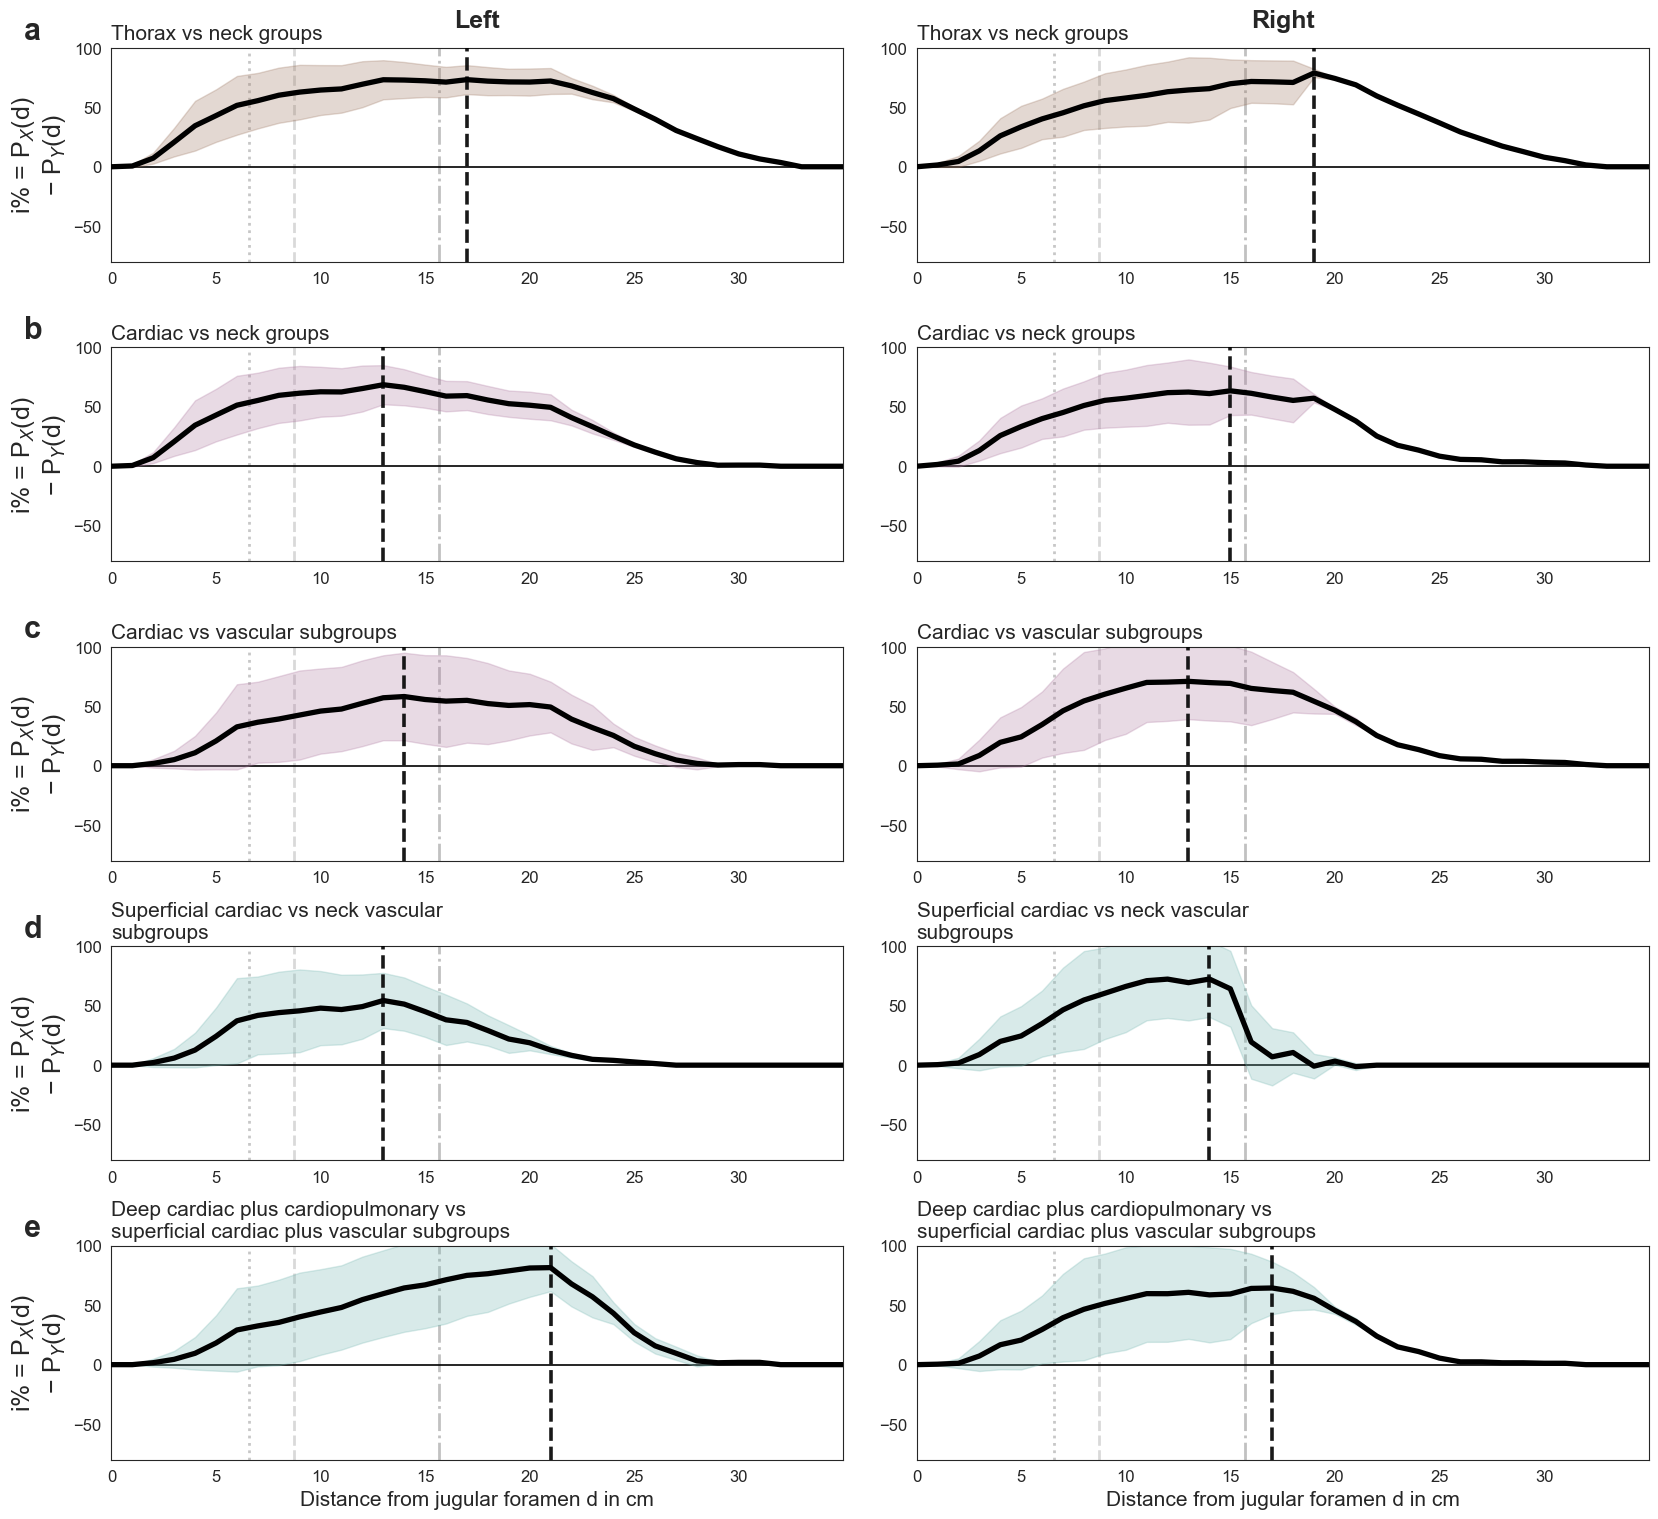

[Saved] C:\Users\siyar\Desktop\branch_project_mary\vagus_nerve_explorer\Fig7_selectivity\Fig_iPct_TargetingLadder__LR__CompositeOnly.png


WindowsPath('Fig7_selectivity/Fig_iPct_TargetingLadder__LR__CompositeOnly.png')

In [8]:
# i% Targeting Ladder (single composite figure)
# Cleaned to match current conventions:
# - default input is vagus_atlas_dataset.xlsx
# - always uses distance_v2 as distance from jugular foramen
# - removes sex QC and sex filtering entirely
# - uses Group not Supergroup
# - robust string matching for esophageal and vascular subgroup names

# If needed (one-time installs in a notebook):
# !pip install pandas numpy matplotlib openpyxl tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import string
import textwrap
from pathlib import Path
from tqdm.auto import tqdm

# ============================================================
# CONFIG
# ============================================================
INPUT_XLSX = r"C:\Users\siyar\Desktop\vagus_nerve_explorer\vagus_atlas_dataset.xlsx"

# fallback if you're running somewhere else
if not Path(INPUT_XLSX).exists():
    alts = [
        Path("vagus_atlas_dataset.xlsx"),
        Path("/mnt/data/vagus_atlas_dataset.xlsx"),
        Path("vagus_atlas_analysis.xlsx"),
        Path("/mnt/data/vagus_atlas_analysis.xlsx"),
        Path("vagus_atlas_dataset.xlsx"),
        Path("/mnt/data/vagus_atlas_dataset.xlsx"),
    ]
    for fb in alts:
        if fb.exists():
            INPUT_XLSX = str(fb)
            break

OUT_DIR = Path("Fig7_selectivity")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = OUT_DIR / "Fig_iPct_TargetingLadder__LR__CompositeOnly.png"
DPI = 300

# Distance axis
XMIN, XMAX = 0, 35
D_STEP = 1
D_VALUES = np.arange(XMIN, XMAX + 1e-9, D_STEP).astype(int)
XTICKS = np.arange(0, 31, 5)

# QC / inclusion
LANDMARK_GROUP_NAME = "Landmark"
MIN_N = 5

# Composite definition
COMPOSITE_CENTER = "mean"   # mean or median

# Plot bounds
YLIM = (-80, 100)

# Style
SHOW_BEST_D = True
BEST_LW = 2.6
BEST_LS = "--"
BEST_ALPHA = 0.9

CENTER_LW = 3.8
CENTER_LS = "-"
CENTER_ALPHA = 1.0

BAND_ALPHA = 0.28

# Readability
BASE_FONT           = 13
TITLE_FONTSIZE      = 15
AXIS_LABEL_FONTSIZE = 15
TICK_FONTSIZE       = 12

Y_LABEL_LEFT_TEXT   = "i% = P$_X$(d)\n− P$_Y$(d)"
Y_LABEL_LEFT_SIZE   = 18

PANEL_LETTER_SIZE   = 22
COL_HEADER_SIZE     = 18

WRAP_STEP_TITLES      = True
STEP_TITLE_WRAP_CHARS = 44

FIG_W, FIG_H = 16.8, 15.6
LEFT_MARGIN   = 0.08
RIGHT_MARGIN  = 0.995
TOP_MARGIN    = 0.965
BOTTOM_MARGIN = 0.060
WSPACE        = 0.10
HSPACE        = 0.40

# ============================================================
# Landmarks
# ============================================================
LANDMARKS_INFO = [
    {"label": "Carotid bifurcation",         "val": 6.592,  "color": "#000000", "ls": ":",  "lw": 2.0, "alpha": 0.22},
    {"label": "Laryngeal prominence",        "val": 8.725,  "color": "#555555", "ls": "--", "lw": 2.0, "alpha": 0.22},
    {"label": "Superior border of clavicle", "val": 15.683, "color": "#333333", "ls": "-.", "lw": 2.0, "alpha": 0.30},
]

# Display rows
DISPLAY_STEPS = [1, 2, 3, 5, 4]

# Comparator group sets
NECK_GROUPS_AB = {"Sympathetic", "Muscular", "Vascular", "Multiple Targets"}
THORAX_GROUPS  = {"Cardiac", "Pulmonary", "Esophageal"}

# Vascular subgroup rules, lowercase matching
VASC_EXCLUDE_LOW = {
    "multiple branches to carotid artery",
    "external carotid artery",
}
VASC_NECK_ALLOW_LOW = {
    "internal carotid artery",
    "carotid sinus",
    "carotid bifurcation",
    "common carotid",
    "internal jugular vein",
    "general",
    "general vascular",
    "unspecified",
    "unspecified (vascular)",
}

# Band colors by step
BAND_BASE_BY_STEP = {
    1: "#9c755f",
    2: "#af7aa1",
    3: "#af7aa1",
    4: "#76b7b2",
    5: "#76b7b2",
}

STEP_TITLES = {
    1: "Thorax vs neck groups",
    2: "Cardiac vs neck groups",
    3: "Cardiac vs vascular subgroups",
    4: "Deep cardiac plus cardiopulmonary vs superficial cardiac plus vascular subgroups",
    5: "Superficial cardiac vs neck vascular subgroups",
}

# Matplotlib defaults
plt.rcParams.update({
    "font.size": BASE_FONT,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": AXIS_LABEL_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ============================================================
# Helpers
# ============================================================
DIST_COL = "distance_from_jugular_foramen_cm"

def normalize_side(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    if s in {"l", "left", "lt", "0"}: return "Left"
    if s in {"r", "right", "rt", "1"}: return "Right"
    return str(x).strip()

def _lm_type(name):
    s = str(name).lower()
    if "carotid" in s and "bif" in s: return "carotid_bifurcation"
    if "lary" in s: return "laryngeal_prominence"
    if "clavic" in s: return "clavicle"
    return None

def standardize_columns_for_current_dataset(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize to:
      - Group (preferred term) and Subgroup
      - distance_from_jugular_foramen_cm from registered_distance_v2
    """
    df = df_in.copy()
    df.columns = [c.strip() for c in df.columns]

    # Group naming
    if "Group" not in df.columns and "Supergroup" in df.columns:
        df = df.rename(columns={"Supergroup": "Group"})
        print("[Cols] Renamed Supergroup -> Group.")
    if "Group" not in df.columns and "Supergroup" not in df.columns:
        raise ValueError("Missing Group or Supergroup column.")

    # Force v2 distance
    if "registered_distance_v2" in df.columns:
        df[DIST_COL] = pd.to_numeric(df["registered_distance_v2"], errors="coerce")
        print("[Cols] Using registered_distance_v2 as distance from jugular foramen.")
    elif "registered_distance" in df.columns:
        df[DIST_COL] = pd.to_numeric(df["registered_distance"], errors="coerce")
        print("[Cols] Using registered_distance as distance from jugular foramen.")
    else:
        raise ValueError("Missing registered_distance_v2 or registered_distance.")

    # De-dupe column names if any
    if df.columns.duplicated().any():
        dups = df.columns[df.columns.duplicated()].unique().tolist()
        print("[WARN] Duplicate columns detected; keeping LAST occurrence for:", dups)
        df = df.loc[:, ~df.columns.duplicated(keep="last")]

    # Clean subgroup
    if "Subgroup" not in df.columns:
        df["Subgroup"] = ""

    return df

def apply_qc_landmarks_only(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    QC policy for current pooled workflow:
      - Do not drop on Sex
      - Drop sides missing any landmark types
    Returns branch rows only with valid distance.
    """
    df = df_in.copy()
    df["Group"] = df["Group"].astype(str).str.strip()
    df["Subgroup"] = df["Subgroup"].fillna("").astype(str).str.strip()

    lm = df[df["Group"].eq(LANDMARK_GROUP_NAME)].copy()
    lm_name_col = "(REVA) Branch Name" if "(REVA) Branch Name" in lm.columns else "Subgroup"

    if lm.empty or lm_name_col not in lm.columns:
        print("[QC] Landmark name column not available, skipping completeness QC.")
        out = df[(~df["Group"].eq(LANDMARK_GROUP_NAME)) & df[DIST_COL].notna()].copy()
        print(f"[QC] Kept branch events: {len(out):,}")
        return out

    lm["lm_type"] = lm[lm_name_col].apply(_lm_type)
    lm_sets = lm.groupby(["Subject", "Side"])["lm_type"].apply(lambda x: set([t for t in x if t]))

    branch_sides = set(
        df[~df["Group"].eq(LANDMARK_GROUP_NAME)][["Subject", "Side"]]
        .dropna().drop_duplicates().itertuples(index=False, name=None)
    )

    bad = set()
    for sub, side in sorted(branch_sides):
        s = lm_sets.get((sub, side), set())
        if len(s) < 3:
            bad.add((sub, side))

    print(f"[QC] Incomplete landmark sides to drop: {len(bad)}")
    if bad:
        df = df[~df.apply(lambda r: (r["Subject"], r["Side"]) in bad, axis=1)].copy()

    out = df[(~df["Group"].eq(LANDMARK_GROUP_NAME)) & df[DIST_COL].notna()].copy()
    print(f"[QC] Kept branch events after QC: {len(out):,}")
    return out

def normalize_cardiac_subgroup(raw):
    r = "" if pd.isna(raw) else str(raw).strip()
    low = r.lower().strip()
    if low == "cardiac plexus": return "Superficial cardiac plexus"
    if low in {"superficial cardiac plexus", "superficial plexus", "superficial"}:
        return "Superficial cardiac plexus"
    if low in {"deep cardiac plexus", "deep plexus", "deep"}:
        return "Deep cardiac plexus"
    if "cardiopulmonary" in low:
        return "Cardiopulmonary"
    return "Other"

def add_landmarks(ax):
    for lm in LANDMARKS_INFO:
        ax.axvline(lm["val"], color=lm["color"], ls=lm["ls"], lw=lm["lw"], alpha=lm["alpha"], zorder=0)

def pct_ge_curve(distances: np.ndarray, d_values: np.ndarray) -> np.ndarray:
    x = np.asarray(distances, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n == 0:
        return np.full(len(d_values), np.nan, dtype=float)
    xs = np.sort(x)
    idx = np.searchsorted(xs, d_values.astype(float), side="left")
    return 100.0 * ((n - idx) / n)

def is_esophageal_cardiac_like(group_series, subgroup_series):
    g = group_series.astype(str).str.strip().str.lower()
    s = subgroup_series.fillna("").astype(str).str.strip().str.lower()
    return (g.eq("esophageal") & (s.str.contains("cardiac") | s.str.contains("cardiopulmonary")))

def is_esophageal_cardiopulmonary(group_series, subgroup_series):
    g = group_series.astype(str).str.strip().str.lower()
    s = subgroup_series.fillna("").astype(str).str.strip().str.lower()
    return (g.eq("esophageal") & s.str.contains("cardiopulmonary"))

def prepare_step(df_in: pd.DataFrame, step: int):
    """
    Returns df_step with columns Subject, Side, distance, Label
    """
    df = df_in.copy()
    df["Group"] = df["Group"].astype(str).str.strip()
    df["Subgroup"] = df["Subgroup"].fillna("").astype(str).str.strip()
    sub_low = df["Subgroup"].str.lower().str.strip()

    eso_card_like = is_esophageal_cardiac_like(df["Group"], df["Subgroup"])

    if step == 1:
        df = df[df["Group"].isin(THORAX_GROUPS | NECK_GROUPS_AB)].copy()
        df["Label"] = np.where(df["Group"].isin(THORAX_GROUPS), "Thorax", df["Group"])
        x_label = "Thorax"
        comp_labels = [g for g in ["Sympathetic", "Muscular", "Vascular", "Multiple Targets"] if g in set(df["Label"])]
        return df, x_label, comp_labels

    if step == 2:
        df = df[df["Group"].isin(THORAX_GROUPS | NECK_GROUPS_AB)].copy()
        cardiac_like = df["Group"].eq("Cardiac") | eso_card_like
        keep = cardiac_like | df["Group"].isin(NECK_GROUPS_AB)
        df = df[keep].copy()
        df["Label"] = np.where(cardiac_like.loc[df.index], "Cardiac", df["Group"])
        x_label = "Cardiac"
        comp_labels = [g for g in ["Sympathetic", "Muscular", "Vascular", "Multiple Targets"] if g in set(df["Label"])]
        return df, x_label, comp_labels

    if step == 3:
        cardiac_like = df["Group"].eq("Cardiac") | eso_card_like
        c = df[cardiac_like].copy()
        c["Label"] = "Cardiac"

        v = df[df["Group"].eq("Vascular")].copy()
        v_low = v["Subgroup"].str.lower().str.strip()
        v = v[~v_low.isin(VASC_EXCLUDE_LOW)].copy()
        v["Label"] = v["Subgroup"]

        df_step = pd.concat([c, v], ignore_index=True)
        x_label = "Cardiac"
        comp_labels = sorted(v["Label"].unique().tolist())
        return df_step, x_label, comp_labels

    if step == 4:
        c = df[df["Group"].eq("Cardiac")].copy()
        c["CardSub"] = c["Subgroup"].apply(normalize_cardiac_subgroup)

        X1 = c[c["CardSub"].isin(["Deep cardiac plexus", "Cardiopulmonary"])].copy()
        X1["Label"] = "Deep plus cardiopulmonary"

        eso_cp = df[is_esophageal_cardiopulmonary(df["Group"], df["Subgroup"])].copy()
        eso_cp["Label"] = "Deep plus cardiopulmonary"

        sc = c[c["CardSub"].eq("Superficial cardiac plexus")].copy()
        sc["Label"] = "Superficial cardiac plexus"

        v = df[df["Group"].eq("Vascular")].copy()
        v_low = v["Subgroup"].str.lower().str.strip()
        v = v[~v_low.isin(VASC_EXCLUDE_LOW)].copy()
        v["Label"] = v["Subgroup"]

        df_step = pd.concat([X1, eso_cp, sc, v], ignore_index=True)
        x_label = "Deep plus cardiopulmonary"
        comp_labels = ["Superficial cardiac plexus"] + sorted(v["Label"].unique().tolist())
        return df_step, x_label, comp_labels

    if step == 5:
        c = df[df["Group"].eq("Cardiac")].copy()
        c["CardSub"] = c["Subgroup"].apply(normalize_cardiac_subgroup)
        X = c[c["CardSub"].eq("Superficial cardiac plexus")].copy()
        X["Label"] = "Superficial cardiac plexus"

        v = df[df["Group"].eq("Vascular")].copy()
        v_low = v["Subgroup"].str.lower().str.strip()
        v = v[~v_low.isin(VASC_EXCLUDE_LOW)].copy()
        v = v[v_low.isin(VASC_NECK_ALLOW_LOW)].copy()
        v["Label"] = v["Subgroup"]

        df_step = pd.concat([X, v], ignore_index=True)
        x_label = "Superficial cardiac plexus"
        comp_labels = sorted(v["Label"].unique().tolist())
        return df_step, x_label, comp_labels

    raise ValueError(f"Unknown step: {step}")

def compute_ipct_and_composite(df_step: pd.DataFrame,
                              x_label: str,
                              comp_labels: list,
                              d_values: np.ndarray,
                              min_n: int = 5,
                              center: str = "mean"):
    counts = df_step["Label"].value_counts().to_dict()
    nx = int(counts.get(x_label, 0))
    if nx < min_n:
        return None

    x_dist = df_step.loc[df_step["Label"].eq(x_label), DIST_COL].astype(float).values
    px = pct_ge_curve(x_dist, d_values)

    curves = {}
    kept = []
    for y in comp_labels:
        ny = int(counts.get(y, 0))
        if ny < min_n:
            continue
        y_dist = df_step.loc[df_step["Label"].eq(y), DIST_COL].astype(float).values
        py = pct_ge_curve(y_dist, d_values)
        curves[y] = px - py
        kept.append(y)

    if len(kept) == 0:
        return None

    mat = np.vstack([curves[y] for y in kept])

    if center == "median":
        comp_center = np.nanmedian(mat, axis=0)
    else:
        comp_center = np.nanmean(mat, axis=0)

    comp_sd = np.nanstd(mat, axis=0, ddof=1) if mat.shape[0] > 1 else np.zeros(mat.shape[1], dtype=float)

    best_d = None if np.all(~np.isfinite(comp_center)) else int(d_values[int(np.nanargmax(comp_center))])

    return {
        "counts": counts,
        "nx": nx,
        "kept": kept,
        "center": comp_center,
        "sd": comp_sd,
        "best_d": best_d,
    }

# ============================================================
# LOAD + QC
# ============================================================
print(f"[Config] INPUT_XLSX = {INPUT_XLSX}")
if not Path(INPUT_XLSX).exists():
    raise FileNotFoundError("Could not find INPUT_XLSX (or fallbacks). Update INPUT_XLSX and rerun.")

print("[Load] Reading excel...")
df0 = pd.read_excel(INPUT_XLSX)
df0 = standardize_columns_for_current_dataset(df0)
df0.columns = [c.strip() for c in df0.columns]
print(f"[Load] Rows={len(df0):,} | Cols={len(df0.columns)}")

required = ["Subject", "Side", "Group", "Subgroup", DIST_COL]
missing = [c for c in required if c not in df0.columns]
if missing:
    print("[ERR] Missing required columns:", missing)
    print("      Available:", list(df0.columns))
    raise ValueError("Missing required columns.")

df_branch = apply_qc_landmarks_only(df0)
df_branch["Side"] = df_branch["Side"].apply(normalize_side)
df_branch = df_branch[df_branch["Side"].isin(["Left", "Right"])].copy()

print(f"[Data] After QC: n branch events={len(df_branch):,}")
print("[Data] Side counts:", df_branch["Side"].value_counts().to_dict())
print("[Data] Groups present:", sorted(df_branch["Group"].astype(str).str.strip().unique().tolist()))

# ============================================================
# FIGURE LAYOUT
# ============================================================
fig = plt.figure(figsize=(FIG_W, FIG_H))
gs = gridspec.GridSpec(nrows=5, ncols=2, height_ratios=[1.0] * 5, hspace=HSPACE, wspace=WSPACE)

axes_ipct = np.empty((5, 2), dtype=object)
for r in range(5):
    for c in range(2):
        axes_ipct[r, c] = fig.add_subplot(gs[r, c])

# ============================================================
# PANELS
# ============================================================
panel_letters = list(string.ascii_lowercase)
task_bar = tqdm(total=len(DISPLAY_STEPS) * 2, desc="Panels step by side", leave=True)

letter_i = 0
for row_i, step in enumerate(DISPLAY_STEPS):
    for col_i, side in enumerate(["Left", "Right"]):
        ax = axes_ipct[row_i, col_i]

        title_txt = STEP_TITLES.get(step, f"Step {step}")
        if WRAP_STEP_TITLES:
            title_txt = textwrap.fill(title_txt, width=STEP_TITLE_WRAP_CHARS)
        ax.set_title(title_txt, loc="left", fontsize=TITLE_FONTSIZE, pad=6)

        if col_i == 0:
            ax.text(-0.12, 1.15, panel_letters[letter_i],
                    transform=ax.transAxes,
                    fontsize=PANEL_LETTER_SIZE,
                    fontweight="bold",
                    va="top", ha="left")
            letter_i += 1

        ax.axhline(0, color="black", lw=1.2, zorder=1)
        add_landmarks(ax)

        df_side = df_branch[df_branch["Side"].eq(side)].copy()
        df_step, x_label, comp_labels = prepare_step(df_side, step)

        counts = df_step["Label"].value_counts().to_dict()
        print(f"[{side} | step {step}] X={x_label} | labels={sorted(list(counts.keys()))} | counts={counts}")

        res = compute_ipct_and_composite(
            df_step=df_step,
            x_label=x_label,
            comp_labels=comp_labels,
            d_values=D_VALUES,
            min_n=MIN_N,
            center=COMPOSITE_CENTER
        )

        if res is None:
            ax.text(0.5, 0.5, "insufficient data",
                    transform=ax.transAxes,
                    ha="center", va="center",
                    fontsize=BASE_FONT)
        else:
            center = res["center"]
            sd = res["sd"]
            lo = center - sd
            hi = center + sd

            band_color = BAND_BASE_BY_STEP.get(step, "#666666")

            ax.fill_between(D_VALUES, lo, hi, color=band_color, alpha=BAND_ALPHA, zorder=2.2)
            ax.plot(D_VALUES, center, color="black", lw=CENTER_LW, ls=CENTER_LS, alpha=CENTER_ALPHA, zorder=5)

            if SHOW_BEST_D and (res["best_d"] is not None):
                best = res["best_d"]
                ax.axvline(best, color="black", lw=BEST_LW, ls=BEST_LS, alpha=BEST_ALPHA, zorder=6)

            print(f"    -> best_d={res['best_d']} cm | n_comp={len(res['kept'])} | Nx={res['nx']}")

        ax.set_xlim(XMIN, XMAX)
        ax.set_xticks(XTICKS)
        ax.set_ylim(YLIM)
        ax.grid(False)
        ax.tick_params(axis="x", labelsize=TICK_FONTSIZE)
        ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)

        if col_i == 0:
            ax.set_ylabel(Y_LABEL_LEFT_TEXT, fontsize=Y_LABEL_LEFT_SIZE)
        else:
            ax.set_ylabel("")

        if row_i == len(DISPLAY_STEPS) - 1:
            ax.set_xlabel("Distance from jugular foramen d in cm", fontsize=AXIS_LABEL_FONTSIZE)
        else:
            ax.set_xlabel("")

        task_bar.update(1)

task_bar.close()

# Column headers
fig.subplots_adjust(left=LEFT_MARGIN, right=RIGHT_MARGIN, top=TOP_MARGIN, bottom=BOTTOM_MARGIN,
                    wspace=WSPACE, hspace=HSPACE)

fig.canvas.draw()
bboxL = axes_ipct[0, 0].get_position()
bboxR = axes_ipct[0, 1].get_position()
xL = bboxL.x0 + bboxL.width / 2
xR = bboxR.x0 + bboxR.width / 2
yH = max(bboxL.y1, bboxR.y1) + 0.01

fig.text(xL, yH, "Left",  ha="center", va="bottom", fontsize=COL_HEADER_SIZE, fontweight="bold")
fig.text(xR, yH, "Right", ha="center", va="bottom", fontsize=COL_HEADER_SIZE, fontweight="bold")

plt.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"[Saved] {OUT_PNG.resolve()}")
OUT_PNG

## § 4  ·  Supplementary figures


### Supp · Sex-split subway map (supports Fig 3)

Same subway-map idiom as Figure 3, but with 8 lanes split by sex (Female / Male
× Left-only / Right-only / Bilateral / Total).

**Output**: `Fig_Subway_8Lane_LRBT__SexSplit__Fixed100Container_Top25.png`


📥 Loading Excel: vagus_atlas_dataset.xlsx
✅ Filtered rows: 2,177
✅ Total cohort N: 28
✅ Female cohort N: 15
✅ Male cohort N:   13

Top-25 (Subgroup -> n_branch_rows):
Subgroup
Cardiopulmonary                        293
Esophageal Plexus                      259
Pulmonary                              239
Superior Cervical Ganglion             143
General Esophageal                     117
Common Carotid                         117
Pulmonary (Esophageal)                  99
Superficial Cardiac Plexus              92
Multiple Branches To Carotid Artery     74
Internal Jugular Vein                   65
General Vascular                        65
Internal Carotid Artery                 61
Laryngeal (SLN)                         58
Laryngeal (RLN)                         55
Sympathetic Trunk                       52
Pharyngeal                              46
Deep Cardiac Plexus                     42
Aorta                                   42
Carotid Bifurcation                     40
Carotid

Rows:   0%|          | 0/31 [00:00<?, ?it/s]

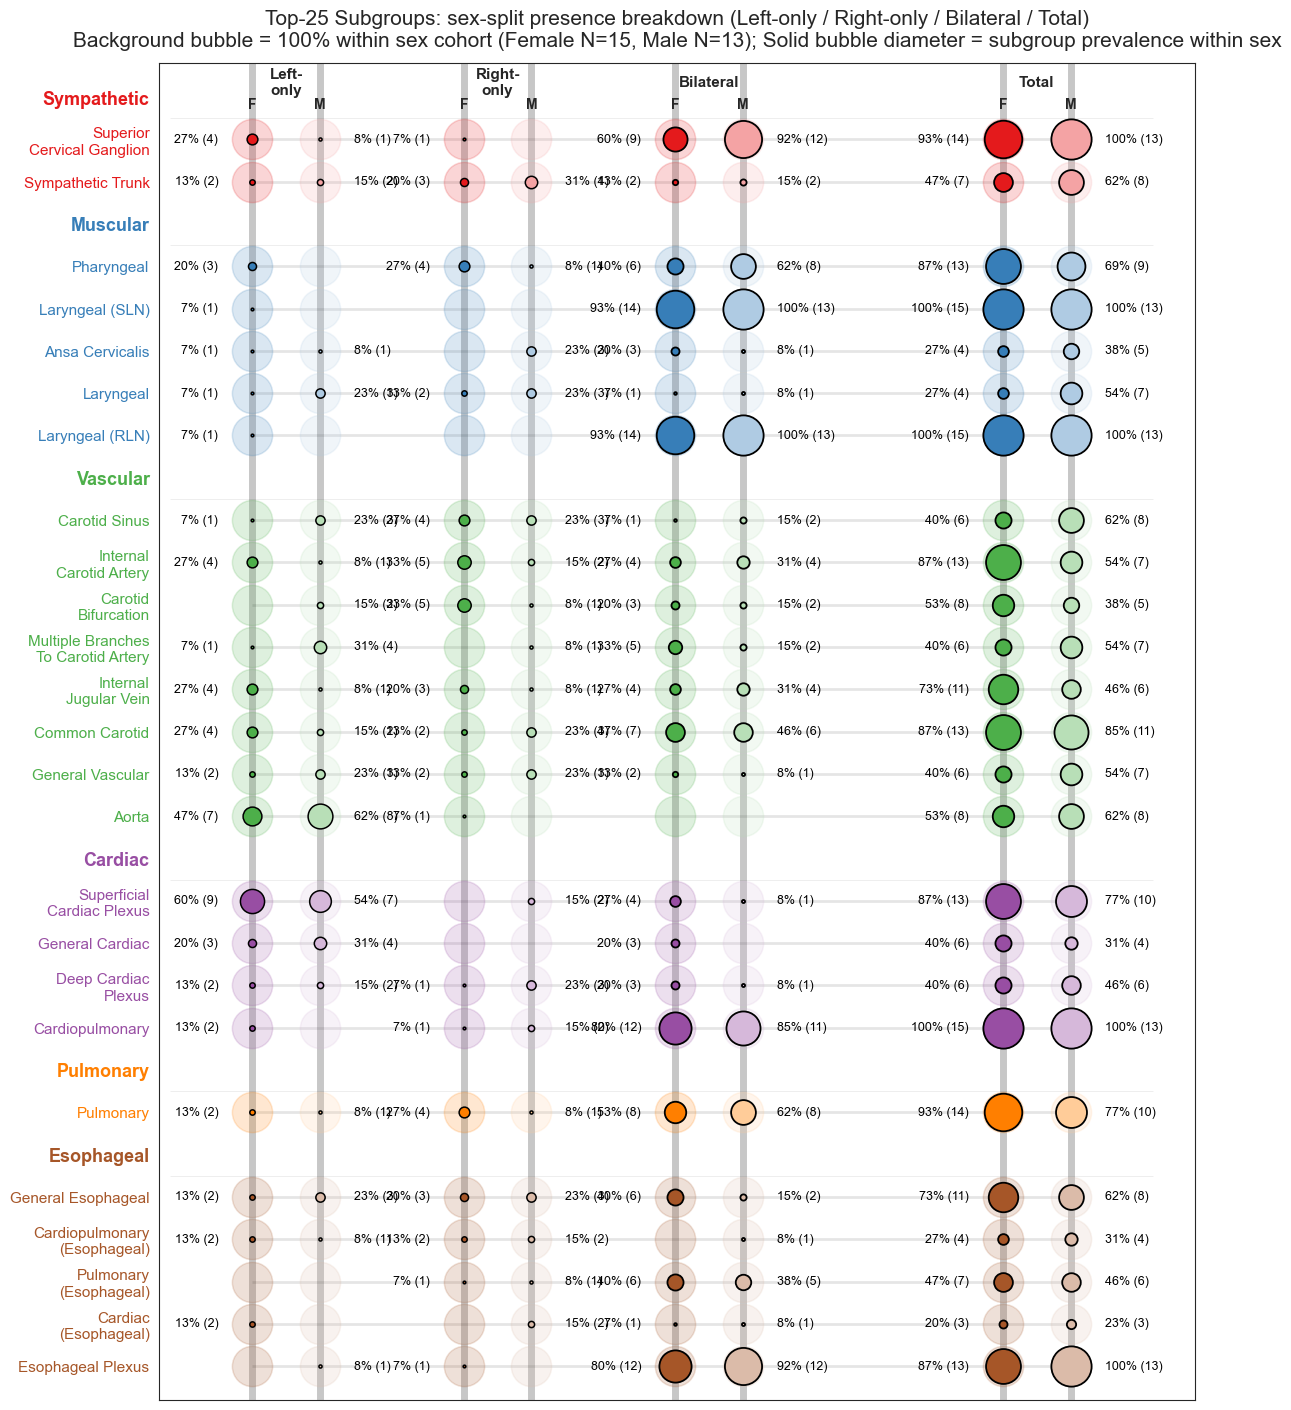


✅ Saved figure: Fig3_subway_map\Fig_Subway_8Lane_LRBT__SexSplit__Fixed100Container_Top25.png
✅ Saved table:  Fig3_subway_map\SupplementaryTable_Top25_PresenceBreakdown_LRBT__SexSplit.csv
✅ Cell 1 done.


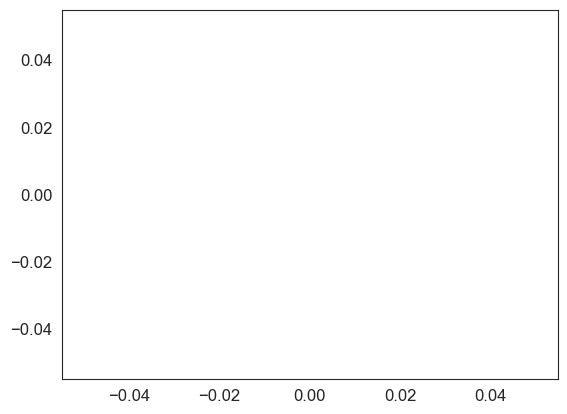

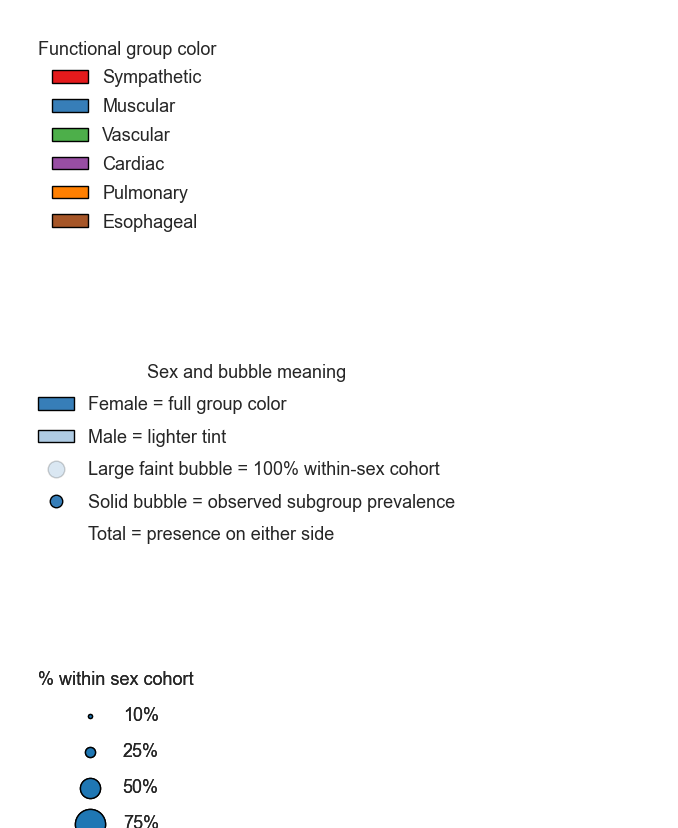

✅ Saved legend: Fig3_subway_map\Legend_Subway_8Lane_LRBT__SexSplit__Top25.png
✅ Cell 2 done.


In [9]:
# %matplotlib inline
# If needed (one-time installs in a notebook):
# !pip install pandas numpy matplotlib openpyxl tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# =========================
# CONFIG
# =========================
INPUT_XLSX = r"C:\Users\siyar\Desktop\vagus_nerve_explorer\vagus_atlas_dataset.xlsx"
DIST_COL   = "registered_distance_v2"

TOP_K_GLOBAL = 25
OUT_DIR = Path("Fig3_subway_map")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_TABLE_CSV = OUT_DIR / f"SupplementaryTable_Top{TOP_K_GLOBAL}_PresenceBreakdown_LRBT__SexSplit.csv"
OUT_FIG_PNG   = OUT_DIR / f"Fig_Subway_8Lane_LRBT__SexSplit__Fixed100Container_Top{TOP_K_GLOBAL}.png"
OUT_LEG_PNG   = OUT_DIR / f"Legend_Subway_8Lane_LRBT__SexSplit__Top{TOP_K_GLOBAL}.png"

group_order = ["Sympathetic", "Muscular", "Multiple Targets", "Vascular", "Cardiac", "Pulmonary", "Esophageal"]
group_colors = {
    "Sympathetic": "#e41a1c",
    "Muscular": "#377eb8",
    "Vascular": "#4daf4a",
    "Cardiac": "#984ea3",
    "Pulmonary": "#ff7f00",
    "Esophageal": "#a65628",
    "Multiple Targets": "#999999",
    "Other": "#000000"
}

SEX_ORDER = ["Female", "Male"]
MALE_TINT_AMOUNT = 0.60

# 8-lane layout: Female/Male for each presence class
# Total intentionally pushed farther right
PAIR_CENTERS = {
    "Left-only":  -3.0,
    "Right-only": -1.0,
    "Bilateral":   1.0,
    "Total":       4.1,
}
PAIR_DX = 0.32
XPOS = {
    ("Female", "Left-only"):  PAIR_CENTERS["Left-only"]  - PAIR_DX,
    ("Male",   "Left-only"):  PAIR_CENTERS["Left-only"]  + PAIR_DX,
    ("Female", "Right-only"): PAIR_CENTERS["Right-only"] - PAIR_DX,
    ("Male",   "Right-only"): PAIR_CENTERS["Right-only"] + PAIR_DX,
    ("Female", "Bilateral"):  PAIR_CENTERS["Bilateral"]  - PAIR_DX,
    ("Male",   "Bilateral"):  PAIR_CENTERS["Bilateral"]  + PAIR_DX,
    ("Female", "Total"):      PAIR_CENTERS["Total"]      - PAIR_DX,
    ("Male",   "Total"):      PAIR_CENTERS["Total"]      + PAIR_DX,
}

FIG_W = 18.5
ROW_H = 0.42
TITLE_FONTSIZE = 15

TRACK_ALPHA = 0.22
TRACK_LW = 5.0
CONNECT_ALPHA = 0.10
SHOW_CONNECTORS = True

SUBGROUP_LABEL_FONTSIZE = 11
GROUP_HEADER_FONTSIZE   = 13
SUBGROUP_LABEL_WEIGHT   = "normal"
GROUP_HEADER_WEIGHT     = "bold"
WRAP_THRESHOLD = 18

SIZE_MIN = 0
SIZE_MAX = int(1200 * 0.7)

NODE_EDGE = "black"
NODE_LW = 1.1
NODE_LW_CENTER = 1.3

SHOW_CONTAINER = True
CONTAINER_ALPHA_FACE = 0.18
CONTAINER_LW = 1.1

SHOW_COUNT_LABELS = True
LABEL_FONTSIZE = 9
LABEL_PAD_PTS = 8.0
LABEL_EXTRA_PTS = 2.0

SHOW_INPANEL_HEADERS = True
COLUMN_HEADER_FONTSIZE = 11
COLUMN_HEADER_WEIGHT = "bold"
SEX_HEADER_FONTSIZE = 10
SEX_HEADER_WEIGHT = "bold"

LEG_BLUE = "#1f77b4"

# =========================
# HELPERS
# =========================
def ensure_exists(p: Path, fallbacks=()):
    p = Path(p)
    if p.exists():
        return p
    for fb in fallbacks:
        fb = Path(fb)
        if fb.exists():
            return fb
    raise FileNotFoundError(f"Missing required file: {p}")

def normalize_side(x):
    s = str(x).strip().upper()
    if s.startswith("L"):
        return "L"
    if s.startswith("R"):
        return "R"
    return np.nan

def normalize_sex(x):
    s = str(x).strip().upper()
    if s.startswith("F"):
        return "Female"
    if s.startswith("M"):
        return "Male"
    return np.nan

def to_numeric_commas(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False), errors="coerce")

def lighten_color(color, amount=0.6):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    out = rgb * (1 - amount) + white * amount
    return tuple(out)

CANON_SUBGROUP_MAP = {
    "superior cervical ganglion": "Superior Cervical Ganglion",
    "ansa cervicalis": "Ansa Cervicalis",
    "carotid sinus": "Carotid Sinus",
    "internal carotid artery": "Internal Carotid Artery",
    "common carotid": "Common Carotid",
    "internal jugular vein": "Internal Jugular Vein",
    "superficial cardiac plexus": "Superficial Cardiac Plexus",
    "deep cardiac plexus": "Deep Cardiac Plexus",
    "esophageal plexus": "Esophageal Plexus",
}

def standardize_labels(dfin: pd.DataFrame) -> pd.DataFrame:
    df = dfin.copy()
    df["Group"] = df["Group"].astype(str).str.strip()
    df["Subgroup"] = df["Subgroup"].astype(str).str.strip()

    df["Subgroup"] = df["Subgroup"].replace({"General": "Unspecified"})

    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"].str.lower() == "esophageal plexus"), "Subgroup"] = "Esophageal Plexus"
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"].str.lower() == "pulmonary"), "Subgroup"] = "Pulmonary (Esophageal)"
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"].str.lower() == "cardiac"), "Subgroup"] = "Cardiac (Esophageal)"
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"].str.lower() == "cardiopulmonary"), "Subgroup"] = "Cardiopulmonary (Esophageal)"

    df["Subgroup"] = df["Subgroup"].str.replace(r"^Unspecified\s*\(.+\)$", "Unspecified", regex=True)

    for g in ["Vascular", "Cardiac", "Esophageal"]:
        m = (df["Group"] == g) & (df["Subgroup"] == "Unspecified")
        if m.any():
            df.loc[m, "Subgroup"] = f"General {g}"

    lower = df["Subgroup"].str.lower()
    for k, v in CANON_SUBGROUP_MAP.items():
        df.loc[lower == k, "Subgroup"] = v

    return df

def size_from_frac(frac, smin=SIZE_MIN, smax=SIZE_MAX):
    if pd.isna(frac):
        return 0.0
    frac = float(frac)
    if frac <= 0:
        return 0.0
    frac = np.clip(frac, 0.0, 1.0)
    d_min = np.sqrt(smin)
    d_max = np.sqrt(smax)
    d = d_min + (d_max - d_min) * frac
    return float(d ** 2)

def radius_pts_from_s(s_pts2: float) -> float:
    s_pts2 = max(float(s_pts2), 1e-12)
    return float(np.sqrt(s_pts2) / 2.0)

def label_left_of_dot(ax, x, y, txt, s_dot, s_container, dy_pts=0.0):
    r_dot = radius_pts_from_s(s_dot)
    r_con = radius_pts_from_s(s_container)
    dx = max(r_dot, r_con) + LABEL_PAD_PTS + LABEL_EXTRA_PTS
    ax.annotate(
        txt, xy=(x, y), xytext=(-dx, dy_pts),
        textcoords="offset points",
        ha="right", va="center",
        fontsize=LABEL_FONTSIZE, color="black", zorder=10
    )

def label_right_of_dot(ax, x, y, txt, s_dot, s_container, dy_pts=0.0):
    r_dot = radius_pts_from_s(s_dot)
    r_con = radius_pts_from_s(s_container)
    dx = max(r_dot, r_con) + LABEL_PAD_PTS + LABEL_EXTRA_PTS
    ax.annotate(
        txt, xy=(x, y), xytext=(dx, dy_pts),
        textcoords="offset points",
        ha="left", va="center",
        fontsize=LABEL_FONTSIZE, color="black", zorder=10
    )

def build_group_blocks(g_list):
    if not g_list:
        return []
    blocks = []
    start = 0
    for i in range(1, len(g_list) + 1):
        if i == len(g_list) or g_list[i] != g_list[start]:
            blocks.append((g_list[start], start, i))
            start = i
    return blocks

def wrap_best_two_lines(s: str, threshold: int = WRAP_THRESHOLD) -> str:
    s = str(s)
    if len(s) <= threshold:
        return s
    parts = s.split(" ")
    if len(parts) < 2:
        return s
    best = None
    for k in range(1, len(parts)):
        a = " ".join(parts[:k]).strip()
        b = " ".join(parts[k:]).strip()
        if not a or not b:
            continue
        score = max(len(a), len(b))
        balance = abs(len(a) - len(b))
        candidate = (score, balance, k, a, b)
        if best is None or candidate[:2] < best[:2]:
            best = candidate
    if best is None:
        return s
    _, _, _, a, b = best
    if max(len(a), len(b)) >= len(s) - 2:
        return s
    return a + "\n" + b

def prepare_y_axis_with_group_headers(counts_df):
    gs = counts_df["Group"].tolist()
    subs = counts_df["Subgroup"].tolist()
    blocks = build_group_blocks(gs)

    y_labels, y_meta = [], []
    for g, s, e in blocks:
        y_labels.append(g)
        y_meta.append({"kind": "header", "group": g})
        for j in range(s, e):
            wrapped = wrap_best_two_lines(subs[j], threshold=WRAP_THRESHOLD)
            y_labels.append(wrapped)
            y_meta.append({
                "kind": "subgroup",
                "group": gs[j],
                "subgroup": subs[j],
                "row_idx_in_counts": j
            })
    return y_labels, y_meta

def style_y_ticks(ax, y_meta):
    ticks = ax.get_yticklabels()
    for tick, meta in zip(ticks, y_meta):
        g = meta["group"]
        col = group_colors.get(g, group_colors["Other"])
        if meta["kind"] == "header":
            tick.set_color(col)
            tick.set_fontsize(GROUP_HEADER_FONTSIZE)
            tick.set_fontweight(GROUP_HEADER_WEIGHT)
        else:
            tick.set_color(col)
            tick.set_fontsize(SUBGROUP_LABEL_FONTSIZE)
            tick.set_fontweight(SUBGROUP_LABEL_WEIGHT)

def add_presence_headers(ax, y_row):
    for cat, xc in PAIR_CENTERS.items():
        header_txt = "Left-only" if cat == "Left-only" else \
                     "Right-only" if cat == "Right-only" else \
                     "Bilateral" if cat == "Bilateral" else \
                     "Total"
        ax.text(
            xc, y_row, header_txt.replace("-", "-\n"),
            ha="center", va="center",
            fontsize=COLUMN_HEADER_FONTSIZE,
            fontweight=COLUMN_HEADER_WEIGHT,
            zorder=25
        )
        ax.text(
            xc - PAIR_DX, y_row + 0.52, "F",
            ha="center", va="center",
            fontsize=SEX_HEADER_FONTSIZE,
            fontweight=SEX_HEADER_WEIGHT,
            zorder=25
        )
        ax.text(
            xc + PAIR_DX, y_row + 0.52, "M",
            ha="center", va="center",
            fontsize=SEX_HEADER_FONTSIZE,
            fontweight=SEX_HEADER_WEIGHT,
            zorder=25
        )

def fmt_presence(n: int, denom: int) -> str:
    pct = 100.0 * (n / denom) if denom > 0 else np.nan
    return f"{pct:.0f}% ({n})"

# =========================
# LOAD + CLEAN
# =========================
INPUT_XLSX = ensure_exists(
    INPUT_XLSX,
    fallbacks=[
        Path("/mnt/data/vagus_atlas_dataset.xlsx"),
        Path("vagus_atlas_dataset.xlsx"),
    ]
)

print(f"📥 Loading Excel: {INPUT_XLSX}")
df = pd.read_excel(INPUT_XLSX)
df.columns = [c.strip() for c in df.columns]

if "Group" not in df.columns and "Supergroup" in df.columns:
    df = df.rename(columns={"Supergroup": "Group"})
    print("[Cols] Renamed Supergroup -> Group")

required = ["Subject", "Side", "Sex", "Group", "Subgroup", DIST_COL]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = standardize_labels(df)

df["Subject"] = df["Subject"].astype(str).str.strip()
df["Side_norm"] = df["Side"].apply(normalize_side)
df["Sex_norm"] = df["Sex"].apply(normalize_sex)
df[DIST_COL] = to_numeric_commas(df[DIST_COL])

df = df[df["Group"] != "Landmark"].copy()
df = df[df[DIST_COL].notna()].copy()
df = df[df["Side_norm"].isin(["L", "R"])].copy()
df = df[df["Sex_norm"].isin(SEX_ORDER)].copy()

N_BY_SEX = df.groupby("Sex_norm")["Subject"].nunique().reindex(SEX_ORDER).fillna(0).astype(int).to_dict()
N_TOTAL = int(df["Subject"].nunique())

print(f"✅ Filtered rows: {len(df):,}")
print(f"✅ Total cohort N: {N_TOTAL}")
print(f"✅ Female cohort N: {N_BY_SEX.get('Female', 0)}")
print(f"✅ Male cohort N:   {N_BY_SEX.get('Male', 0)}")

if N_TOTAL <= 0:
    raise ValueError("Cohort size computed as 0. Check Subject column/filters.")

# =========================
# TOP-25 selection (global; pooled sexes)
# =========================
top = df["Subgroup"].value_counts().nlargest(TOP_K_GLOBAL)
keep_subs = top.index.tolist()

print(f"\nTop-{TOP_K_GLOBAL} (Subgroup -> n_branch_rows):")
print(top.to_string())

df_top = df[df["Subgroup"].isin(keep_subs)].copy()

sub2g = df_top.groupby("Subgroup")["Group"].agg(lambda x: x.mode().iloc[0]).to_dict()
mean_map = df_top.groupby("Subgroup")[DIST_COL].mean()

rank_map = {g: i for i, g in enumerate(group_order)}
order_df = pd.DataFrame({
    "Subgroup": list(mean_map.index),
    "Group": [sub2g.get(s, "Other") for s in mean_map.index],
    "MeanDist": [float(mean_map[s]) for s in mean_map.index],
})
order_df["Rank"] = order_df["Group"].map(rank_map).fillna(999).astype(int)
order_df = order_df.sort_values(["Rank", "MeanDist"], ascending=[True, True]).reset_index(drop=True)
ordered_subgroups = order_df["Subgroup"].tolist()

# =========================
# SUBJECT-LEVEL PRESENCE by sex
# =========================
print("\n🧮 Building subject-level sex-specific presence matrix...")
presence = df_top.drop_duplicates(["Subject", "Sex_norm", "Side_norm", "Subgroup"])[["Subject", "Sex_norm", "Side_norm", "Subgroup"]].copy()
presence["present"] = 1

counts_df = pd.DataFrame({
    "Group": [sub2g.get(s, "Other") for s in ordered_subgroups],
    "Subgroup": ordered_subgroups,
    "Mean distance (cm)": [float(mean_map.get(s, np.nan)) for s in ordered_subgroups],
})

for sex in SEX_ORDER:
    print(f"   - Processing sex={sex}")
    px = presence[presence["Sex_norm"] == sex].pivot_table(
        index=["Subject", "Subgroup"],
        columns="Side_norm",
        values="present",
        aggfunc="max",
        fill_value=0
    )

    if "L" not in px.columns:
        px["L"] = 0
    if "R" not in px.columns:
        px["R"] = 0
    px = px[["L", "R"]].astype(int)

    px["Bilateral"]  = ((px["L"] == 1) & (px["R"] == 1)).astype(int)
    px["Left_only"]  = ((px["L"] == 1) & (px["R"] == 0)).astype(int)
    px["Right_only"] = ((px["L"] == 0) & (px["R"] == 1)).astype(int)
    px["Any"]        = ((px["L"] == 1) | (px["R"] == 1)).astype(int)

    n_left_only  = px["Left_only"].groupby(level=1).sum()
    n_right_only = px["Right_only"].groupby(level=1).sum()
    n_bilat      = px["Bilateral"].groupby(level=1).sum()
    n_any        = px["Any"].groupby(level=1).sum()

    counts_df[f"n_left_only_{sex}"]  = [int(n_left_only.get(s, 0)) for s in ordered_subgroups]
    counts_df[f"n_right_only_{sex}"] = [int(n_right_only.get(s, 0)) for s in ordered_subgroups]
    counts_df[f"n_bilateral_{sex}"]  = [int(n_bilat.get(s, 0)) for s in ordered_subgroups]
    counts_df[f"n_any_{sex}"]        = [int(n_any.get(s, 0)) for s in ordered_subgroups]

    denom = int(N_BY_SEX.get(sex, 0))
    counts_df[f"share_Left-only_{sex}"]  = counts_df[f"n_left_only_{sex}"]  / denom if denom > 0 else np.nan
    counts_df[f"share_Right-only_{sex}"] = counts_df[f"n_right_only_{sex}"] / denom if denom > 0 else np.nan
    counts_df[f"share_Bilateral_{sex}"]  = counts_df[f"n_bilateral_{sex}"]  / denom if denom > 0 else np.nan
    counts_df[f"share_Total_{sex}"]      = counts_df[f"n_any_{sex}"]        / denom if denom > 0 else np.nan

# =========================
# FINAL SUPPLEMENTARY TABLE
# =========================
supp_table = pd.DataFrame({
    "Group": counts_df["Group"],
    "Subgroup": counts_df["Subgroup"],
    "Mean distance (cm)": counts_df["Mean distance (cm)"].round(2),

    "Female Left-only presence":  [fmt_presence(n, N_BY_SEX["Female"]) for n in counts_df["n_left_only_Female"]],
    "Male Left-only presence":    [fmt_presence(n, N_BY_SEX["Male"])   for n in counts_df["n_left_only_Male"]],

    "Female Right-only presence": [fmt_presence(n, N_BY_SEX["Female"]) for n in counts_df["n_right_only_Female"]],
    "Male Right-only presence":   [fmt_presence(n, N_BY_SEX["Male"])   for n in counts_df["n_right_only_Male"]],

    "Female Bilateral presence":  [fmt_presence(n, N_BY_SEX["Female"]) for n in counts_df["n_bilateral_Female"]],
    "Male Bilateral presence":    [fmt_presence(n, N_BY_SEX["Male"])   for n in counts_df["n_bilateral_Male"]],

    "Female Total presence":      [fmt_presence(n, N_BY_SEX["Female"]) for n in counts_df["n_any_Female"]],
    "Male Total presence":        [fmt_presence(n, N_BY_SEX["Male"])   for n in counts_df["n_any_Male"]],
})

supp_table.to_csv(OUT_TABLE_CSV, index=False)
print(f"💾 Saved supplementary table: {OUT_TABLE_CSV}")

print("\n[Preview] Supplementary table (first 10 rows):")
print(supp_table.head(10).to_string(index=False))

# =========================
# FIGURE (NO LEGEND)
# =========================
y_labels, y_meta = prepare_y_axis_with_group_headers(counts_df)
FIRST_HEADER_ROW_I = next((i for i, m in enumerate(y_meta) if m["kind"] == "header"), 0)

S_CONTAINER_100 = size_from_frac(1.0)

K = len(y_meta)
fig_h = max(8, ROW_H * K + 2.0)
fig, ax = plt.subplots(figsize=(FIG_W, fig_h))

# track lines
for cat in ["Left-only", "Right-only", "Bilateral", "Total"]:
    ax.vlines(
        [PAIR_CENTERS[cat] - PAIR_DX, PAIR_CENTERS[cat] + PAIR_DX],
        ymin=-0.8, ymax=K - 0.2,
        colors="black", linewidth=TRACK_LW, alpha=TRACK_ALPHA, zorder=0
    )

print("\n🎨 Rendering sex-split presence breakdown figure...")
for i in tqdm(range(K), desc="Rows"):
    meta = y_meta[i]
    if meta["kind"] == "header":
        ax.hlines(y=i + 0.5, xmin=-4.1, xmax=5.2, colors="black", linewidth=0.6, alpha=0.08, zorder=0)
        continue

    j = meta["row_idx_in_counts"]
    g = meta["group"]
    base_col = group_colors.get(g, group_colors["Other"])

    if SHOW_CONNECTORS:
        ax.hlines(
            y=i, xmin=min(XPOS.values()), xmax=max(XPOS.values()),
            colors="black", linewidth=2.0, alpha=CONNECT_ALPHA, zorder=1
        )

    for sex in SEX_ORDER:
        col = base_col if sex == "Female" else lighten_color(base_col, amount=MALE_TINT_AMOUNT)

        for cat, count_key, share_key in [
            ("Left-only",  f"n_left_only_{sex}",  f"share_Left-only_{sex}"),
            ("Right-only", f"n_right_only_{sex}", f"share_Right-only_{sex}"),
            ("Bilateral",  f"n_bilateral_{sex}",  f"share_Bilateral_{sex}"),
            ("Total",      f"n_any_{sex}",        f"share_Total_{sex}"),
        ]:
            x = XPOS[(sex, cat)]
            n = int(counts_df.loc[j, count_key])
            frac = float(counts_df.loc[j, share_key]) if pd.notna(counts_df.loc[j, share_key]) else np.nan

            s_dot = size_from_frac(frac)
            s_container = S_CONTAINER_100

            if SHOW_CONTAINER:
                ax.scatter(
                    [x], [i], s=s_container, color=col, alpha=CONTAINER_ALPHA_FACE,
                    edgecolors=col, linewidths=CONTAINER_LW, zorder=2
                )

            if s_dot > 0:
                lw = NODE_LW_CENTER if cat in {"Bilateral", "Total"} else NODE_LW
                ax.scatter([x], [i], s=s_dot, color=col, edgecolors=NODE_EDGE, linewidths=lw, zorder=5)

            if SHOW_COUNT_LABELS:
                txt = f"{frac*100:.0f}% ({n})" if pd.notna(frac) else f"NA ({n})"
                if sex == "Female":
                    if n > 0 or cat == "Total":
                        label_left_of_dot(ax, x, i, txt, s_dot=s_dot, s_container=s_container)
                else:
                    if n > 0 or cat == "Total":
                        label_right_of_dot(ax, x, i, txt, s_dot=s_dot, s_container=s_container)

ax.set_xlim(-4.2, 5.6)
ax.set_ylim(-0.8, K - 0.2)
ax.invert_yaxis()

ax.set_xticks([])
ax.tick_params(axis="x", length=0)

ax.set_yticks(np.arange(K))
ax.set_yticklabels(y_labels)
style_y_ticks(ax, y_meta)

ax.set_title(
    f"Top-{TOP_K_GLOBAL} Subgroups: sex-split presence breakdown (Left-only / Right-only / Bilateral / Total)\n"
    f"Background bubble = 100% within sex cohort (Female N={N_BY_SEX['Female']}, Male N={N_BY_SEX['Male']}); "
    f"Solid bubble diameter = subgroup prevalence within sex",
    fontsize=TITLE_FONTSIZE,
    pad=12
)

if SHOW_INPANEL_HEADERS:
    add_presence_headers(ax, y_row=FIRST_HEADER_ROW_I - 0.35)

fig.subplots_adjust(left=0.34, right=0.90, top=0.93, bottom=0.04)

fig.savefig(OUT_FIG_PNG, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"\n✅ Saved figure: {OUT_FIG_PNG}")
print(f"✅ Saved table:  {OUT_TABLE_CSV}")
print("✅ Cell 1 done.")

# Assumes Cell 1 has already been run in the notebook

def build_legend_handles(counts_df):
    # -------------------------
    # Group color handles
    # -------------------------
    present_groups = [g for g in group_order if g in set(counts_df["Group"])]
    group_handles = [
        Patch(facecolor=group_colors[g], edgecolor="black", label=g)
        for g in present_groups
    ]

    # -------------------------
    # Sex / bubble meaning handles
    # -------------------------
    rep = group_colors["Muscular"]
    female_col = rep
    male_col = lighten_color(rep, amount=MALE_TINT_AMOUNT)

    sex_style_handles = [
        Patch(facecolor=female_col, edgecolor="black", label="Female = full group color"),
        Patch(facecolor=male_col, edgecolor="black", label="Male = lighter tint"),
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=rep, markeredgecolor="black",
               markersize=12, alpha=CONTAINER_ALPHA_FACE,
               label="Large faint bubble = 100% within-sex cohort"),
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=rep, markeredgecolor="black",
               markersize=9, alpha=1.0,
               label="Solid bubble = observed subgroup prevalence"),
        Line2D([0], [0], color="none", label="Total = presence on either side"),
    ]

    # -------------------------
    # Size legend handles
    # -------------------------
    size_fracs = (0.10, 0.25, 0.50, 0.75)
    size_handles = [
        plt.scatter([], [], s=size_from_frac(f), color=LEG_BLUE, edgecolors="black", linewidths=1.0)
        for f in size_fracs
    ]
    size_labels = [f"{f:.0%}" for f in size_fracs]

    return group_handles, sex_style_handles, size_handles, size_labels

def save_separate_legend(counts_df, out_path):
    group_handles, sex_style_handles, size_handles, size_labels = build_legend_handles(counts_df)

    fig_leg = plt.figure(figsize=(8.5, 10.5))
    ax_leg = fig_leg.add_subplot(111)
    ax_leg.axis("off")

    leg_groups = ax_leg.legend(
        handles=group_handles,
        title="Functional group color",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        borderpad=0.3,
        labelspacing=0.6
    )
    ax_leg.add_artist(leg_groups)

    leg_style = ax_leg.legend(
        handles=sex_style_handles,
        title="Sex and bubble meaning",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.58),
        borderpad=0.3,
        labelspacing=0.8,
        handletextpad=0.8
    )
    ax_leg.add_artist(leg_style)

    leg_size = ax_leg.legend(
        size_handles,
        size_labels,
        title="% within sex cohort",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.20),
        borderpad=0.3,
        labelspacing=1.0
    )
    ax_leg.add_artist(leg_size)

    fig_leg.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig_leg)
    print(f"✅ Saved legend: {out_path}")

save_separate_legend(counts_df, OUT_LEG_PNG)
print("✅ Cell 2 done.")

Standalone legend for the sex-split subway map.


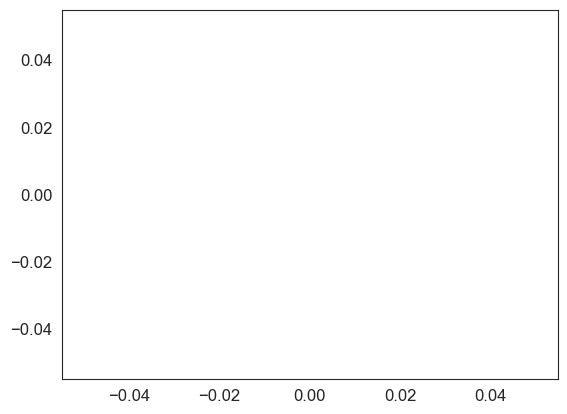

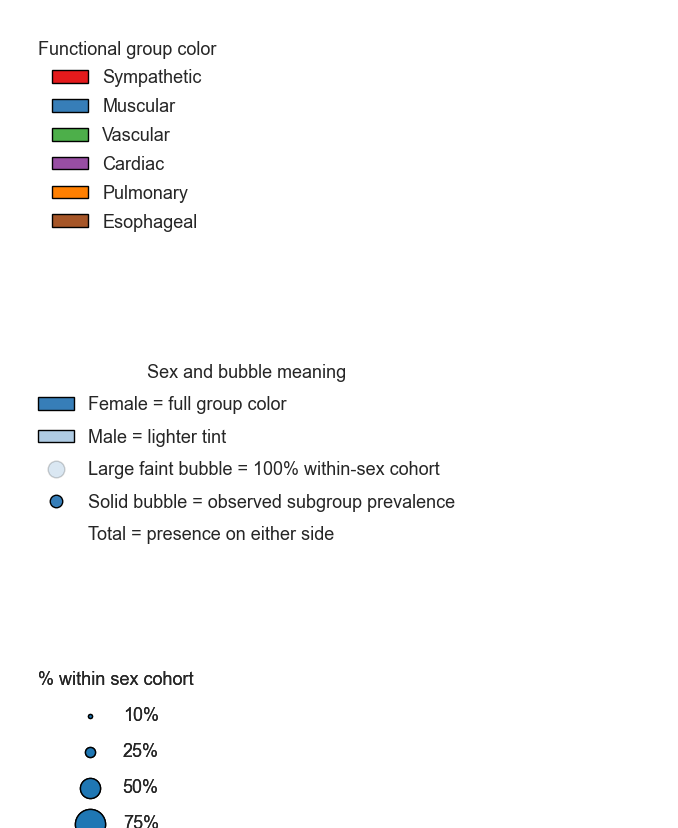

✅ Saved legend: Fig3_subway_map\Legend_Subway_8Lane_LRBT__SexSplit__Top25.png
✅ Cell 2 done.


In [10]:
# Assumes Cell 1 has already been run in the notebook

def build_legend_handles(counts_df):
    # -------------------------
    # Group color handles
    # -------------------------
    present_groups = [g for g in group_order if g in set(counts_df["Group"])]
    group_handles = [
        Patch(facecolor=group_colors[g], edgecolor="black", label=g)
        for g in present_groups
    ]

    # -------------------------
    # Sex / bubble meaning handles
    # -------------------------
    rep = group_colors["Muscular"]
    female_col = rep
    male_col = lighten_color(rep, amount=MALE_TINT_AMOUNT)

    sex_style_handles = [
        Patch(facecolor=female_col, edgecolor="black", label="Female = full group color"),
        Patch(facecolor=male_col, edgecolor="black", label="Male = lighter tint"),
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=rep, markeredgecolor="black",
               markersize=12, alpha=CONTAINER_ALPHA_FACE,
               label="Large faint bubble = 100% within-sex cohort"),
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=rep, markeredgecolor="black",
               markersize=9, alpha=1.0,
               label="Solid bubble = observed subgroup prevalence"),
        Line2D([0], [0], color="none", label="Total = presence on either side"),
    ]

    # -------------------------
    # Size legend handles
    # -------------------------
    size_fracs = (0.10, 0.25, 0.50, 0.75)
    size_handles = [
        plt.scatter([], [], s=size_from_frac(f), color=LEG_BLUE, edgecolors="black", linewidths=1.0)
        for f in size_fracs
    ]
    size_labels = [f"{f:.0%}" for f in size_fracs]

    return group_handles, sex_style_handles, size_handles, size_labels

def save_separate_legend(counts_df, out_path):
    group_handles, sex_style_handles, size_handles, size_labels = build_legend_handles(counts_df)

    fig_leg = plt.figure(figsize=(8.5, 10.5))
    ax_leg = fig_leg.add_subplot(111)
    ax_leg.axis("off")

    leg_groups = ax_leg.legend(
        handles=group_handles,
        title="Functional group color",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        borderpad=0.3,
        labelspacing=0.6
    )
    ax_leg.add_artist(leg_groups)

    leg_style = ax_leg.legend(
        handles=sex_style_handles,
        title="Sex and bubble meaning",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.58),
        borderpad=0.3,
        labelspacing=0.8,
        handletextpad=0.8
    )
    ax_leg.add_artist(leg_style)

    leg_size = ax_leg.legend(
        size_handles,
        size_labels,
        title="% within sex cohort",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.20),
        borderpad=0.3,
        labelspacing=1.0
    )
    ax_leg.add_artist(leg_size)

    fig_leg.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig_leg)
    print(f"✅ Saved legend: {out_path}")

save_separate_legend(counts_df, OUT_LEG_PNG)
print("✅ Cell 2 done.")

### Supp · Sex-split subgroup mega violin (supports Fig 4)

Sex-stratified version of the subgroup mega violin from Figure 4.

**Output**: `Branch_Distances_from_Jugular_Foramen_by_Group_Subgroup_LR_SexSplit.png`


In [ ]:
# %matplotlib inline
# If needed (one-time installs in a notebook):
# !pip install pandas numpy matplotlib seaborn openpyxl tqdm scipy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
from matplotlib.collections import PolyCollection
import matplotlib.colors as mcolors
import textwrap

# ==========================================
# USER CONFIG
# ==========================================
INPUT_XLSX = r"C:\Users\siyar\Desktop\vagus_nerve_explorer\vagus_atlas_dataset.xlsx"

# fallback if you're running somewhere else
if not Path(INPUT_XLSX).exists():
    for fb in [
        Path("vagus_atlas_dataset.xlsx"),
        Path("/mnt/data/vagus_atlas_dataset.xlsx"),
        Path("vagus_atlas_analysis.xlsx"),
        Path("/mnt/data/vagus_atlas_analysis.xlsx"),
    ]:
        if fb.exists():
            INPUT_XLSX = str(fb)
            break

OUTPUT_DIR = Path("Fig4_subgroup_violins")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 25

# If auto-detection fails, set these explicitly:
SEX_COL = None       # e.g., "Sex"
SIDE_COL = None      # e.g., "Side"
SUBJECT_COL = None   # e.g., "Subject" / "Donor" / "Cadaver_ID"

# ---- Layout controls ----
Y_SPACING      = 2
VIOLIN_WIDTH   = 1.6
SUPERGROUP_GAP = 1.5

FIG_WIDTH_IN   = 36
ROW_HEIGHT_IN  = 0.62
MIN_FIG_H_IN   = 22
LEFT_MARGIN    = 0.20

# ---- KDE smoothing controls ----
BW_ADJUST = 0.55
GRIDSIZE  = 200

# ---- Wrap left-side labels to 2 lines ----
WRAP_WIDTH = 22
FORCE_PAREN_NEWLINE = True
SUBGROUP_INDENT = "   "

# ---- Annotation placement controls ----
PLACEMENT_QLO = 0.05
PLACEMENT_QHI = 0.95
LABEL_OFFSET_PTS = 25
LABEL_Y_OFFSET_FEMALE = +16
LABEL_Y_OFFSET_MALE   = -16
LABEL_CLIP = False
LABEL_MIN_DATA_PAD_FRAC = 0.006
LABEL_SIDE_PENALTY_FRAC = 0.030   # discourage placement too close to panel edge

# ---- Fonts ----
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 15,
    "figure.titlesize": 24,
})
TITLE_FONTSIZE = 24
SIDE_TITLE_FONTSIZE = 22
LEFT_LABEL_FONTSIZE = 24
GROUP_HEADER_FONTSIZE = 26
LANDMARK_LABEL_FONTSIZE = 15
COUNT_FONTSIZE = 16

# ---- Points ----
SHOW_POINTS  = True
POINT_SIZE   = 4.5
POINT_ALPHA  = 0.70
POINT_COLOR  = "black"

# ---- Male tint strength ----
MALE_TINT_AMOUNT = 0.60

# ---- Landmark lines ----
LANDMARKS_INFO = [
    {"label": "Carotid bifurcation",         "val": 6.592,  "color": "#000000", "style": ":",  "width": 2.5},
    {"label": "Laryngeal prominence",        "val": 8.725,  "color": "#555555", "style": "--", "width": 2.5},
    {"label": "Superior border of clavicle", "val": 15.683, "color": "#333333", "style": "-.", "width": 2.5},
]

# ---- Supergroup scheme ----
SUPERGROUP_COLORS = {
    "Sympathetic": "#e41a1c",
    "Muscular": "#377eb8",
    "Vascular": "#4daf4a",
    "Cardiac": "#984ea3",
    "Pulmonary": "#ff7f00",
    "Esophageal": "#a65628",
    "Multiple Targets": "#999999",
    "Other": "#000000",
}
SUPERGROUP_ORDER = ["Sympathetic", "Muscular", "Multiple Targets", "Vascular", "Cardiac", "Pulmonary", "Esophageal"]

# ---- Supergroup background shading ----
BG_ENABLE = True
BG_RANGE_MODE = "quantile"
BG_RANGE_QLO  = 0.01
BG_RANGE_QHI  = 0.99

BG_LIGHTEN_AMOUNT     = 0.92
BG_ALPHA              = 0.55
BG_IQR_LIGHTEN_AMOUNT = 0.86
BG_IQR_ALPHA          = 0.75
BG_ZORDER             = -30
BG_IQR_ZORDER         = -29

# ---- Saving ----
DPI = 300
OUT_FIG = OUTPUT_DIR / "Branch_Distances_from_Jugular_Foramen_by_Group_Subgroup_LR_SexSplit.png"
SAVE_SEPARATE_LEGEND = True
OUT_LEG = OUTPUT_DIR / "Legend_Branch_Distances_from_Jugular_Foramen_SexSplit.png"

# ==========================================
# Helpers
# ==========================================
def find_col(df, candidates):
    cols = list(df.columns)
    lower_map = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


def auto_find_subject_col(df):
    preferred = ["Subject", "subject", "Donor", "donor", "Cadaver", "cadaver", "Specimen", "specimen",
                 "SpecimenID", "specimen_id", "Case", "case", "Patient", "patient", "ID", "id"]
    c = find_col(df, preferred)
    if c is not None:
        return c
    for col in df.columns:
        if any(k in col.lower() for k in ["subject", "donor", "cadaver", "specimen", "case", "patient", "id"]):
            return col
    return None


def normalize_side(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"l", "left", "lt"}: return "Left"
    if s in {"r", "right", "rt"}: return "Right"
    if s in {"0"}: return "Left"
    if s in {"1"}: return "Right"
    return str(x).strip()


def normalize_sex(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"f", "female", "woman", "w"}: return "Female"
    if s in {"m", "male", "man"}: return "Male"
    return str(x).strip()


def lighten_color(color, amount=0.6):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    out = rgb * (1 - amount) + white * amount
    return tuple(out)


def rgb_dist(a, b):
    a = np.array(a[:3], dtype=float)
    b = np.array(b[:3], dtype=float)
    return float(np.linalg.norm(a - b))


def harmonize_names(df):
    """
    Keep the new manuscript naming as the target vocabulary, but absorb common legacy variants.
    """
    df = df.copy()
    df["Supergroup"] = df["Supergroup"].astype(str).str.strip()
    df["Subgroup"] = df["Subgroup"].astype(str).str.strip()

    subgroup_map = {
        # sympathetic
        "superior cervical ganglion": "Superior Cervical Ganglion",
        "Sympathetic trunk": "Sympathetic Trunk",
        "Sympathetic trunk and superior cervical ganglion": "Sympathetic Trunk And Superior Cervical Ganglion",

        # muscular
        "Laryngeal (non-recurrent laryngeal nerve)": "Laryngeal (Non-recurrent Laryngeal nerve)",

        # vascular
        "Internal Carotid artery": "Internal Carotid Artery",
        "internal carotid artery": "Internal Carotid Artery",
        "External Carotid artery": "External Carotid Artery",
        "general vascular": "General Vascular",
        "Unspecified (Vascular)": "General Vascular",
        "General": "General Vascular",
        "Multiple Branches to Carotid Artery": "Multiple Branches To Carotid Artery",

        # cardiac
        "general cardiac": "General Cardiac",
        "Unspecified (Cardiac)": "General Cardiac",
        "superficial cardiac plexus": "Superficial Cardiac Plexus",
        "deep cardiac plexus": "Deep Cardiac Plexus",
        "cardiac plexus": "Cardiac Plexus",

        # esophageal
        "general esophageal": "General Esophageal",
        "Unspecified (Esophageal)": "General Esophageal",
        "esophageal plexus": "Esophageal Plexus",
        "pulmonary (esophageal)": "Pulmonary (Esophageal)",
        "cardiac (esophageal)": "Cardiac (Esophageal)",
        "cardiopulmonary (esophageal)": "Cardiopulmonary (Esophageal)",

        # multiple targets
        "Vascular and superficial cardiac plexus": "Vascular And Superficial Cardiac Plexus",
        "Vascular and sympathetic chain": "Vascular And Sympathetic Chain",
        "Vascular and laryngeal": "Vascular And Laryngeal",
        "Vascular and pharyngeal": "Vascular And Pharyngeal",
        "Vascular and muscular - laryngeal": "Vascular And Muscular - Laryngeal",
        "Sympathetic chain, cardiovascular, and pulmonary": "Sympathetic Chain, Cardiovascular, And Pulmonary",
        "Sympathetic chain, cardiovascular, and laryngeal muscles": "Sympathetic Chain, Cardiovascular, And Laryngeal Muscles",
    }

    df["Subgroup"] = df["Subgroup"].replace(subgroup_map)

    for sg, new_name in {
        "Vascular": "General Vascular",
        "Cardiac": "General Cardiac",
        "Esophageal": "General Esophageal",
    }.items():
        mask = (df["Supergroup"] == sg) & (
            df["Subgroup"].str.lower().isin(["general", "unspecified", f"unspecified ({sg.lower()})"])
        )
        df.loc[mask, "Subgroup"] = new_name

    mask = (df["Supergroup"] == "Pulmonary") & (
        df["Subgroup"].str.lower().isin(["general", "unspecified", "general pulmonary"])
    )
    df.loc[mask, "Subgroup"] = "Pulmonary"

    return df


def wrap_label_2lines(s, width=22, force_paren_newline=True):
    s = str(s)
    if force_paren_newline and " (" in s:
        return s.replace(" (", "\n(")
    lines = textwrap.wrap(s, width=width, break_long_words=False, break_on_hyphens=False)
    if len(lines) <= 1:
        return s
    if len(lines) == 2:
        return "\n".join(lines)
    return lines[0] + "\n" + (lines[1] + "…")


def draw_violinplot_robust_split(ax, sub_df, y_order_keys, sex_col, sex_order, placeholder_palette):
    base_kwargs = dict(
        data=sub_df,
        x="registered_distance",
        y="YKey",
        order=y_order_keys,
        hue=sex_col,
        hue_order=sex_order,
        split=True,
        cut=0,
        inner=None,
        linewidth=1.0,
        width=VIOLIN_WIDTH,
        palette=placeholder_palette,
        gridsize=GRIDSIZE,
        ax=ax,
    )
    tries = [
        dict(base_kwargs, density_norm="width", bw_adjust=BW_ADJUST),
        dict(base_kwargs, scale="width",        bw_adjust=BW_ADJUST),
        dict(base_kwargs, density_norm="width", bw=BW_ADJUST),
        dict(base_kwargs, scale="width",        bw=BW_ADJUST),
    ]
    last_err = None
    for k in tries:
        try:
            sns.violinplot(**k)
            return
        except TypeError as e:
            last_err = e
    raise last_err


def build_y_axis_with_headers(ordered_subs, subgroup_to_supergroup):
    y_order_keys = []
    y_display_lbls = []
    y_meta = []

    def sg_of(sub):
        return subgroup_to_supergroup.get(sub, "Other")

    if not ordered_subs:
        return y_order_keys, y_display_lbls, y_meta

    cur_sg = sg_of(ordered_subs[0])
    block = [ordered_subs[0]]

    for sub in ordered_subs[1:]:
        sg = sg_of(sub)
        if sg == cur_sg:
            block.append(sub)
        else:
            header_key = f"__HEADER__{cur_sg}__"
            y_order_keys.append(header_key)
            y_display_lbls.append(cur_sg)
            y_meta.append({"kind": "header", "supergroup": cur_sg, "key": header_key})

            for bsub in block:
                y_order_keys.append(bsub)
                y_display_lbls.append(
                    SUBGROUP_INDENT + wrap_label_2lines(
                        bsub, width=WRAP_WIDTH, force_paren_newline=FORCE_PAREN_NEWLINE
                    )
                )
                y_meta.append({"kind": "subgroup", "supergroup": cur_sg, "subgroup": bsub, "key": bsub})

            cur_sg = sg
            block = [sub]

    header_key = f"__HEADER__{cur_sg}__"
    y_order_keys.append(header_key)
    y_display_lbls.append(cur_sg)
    y_meta.append({"kind": "header", "supergroup": cur_sg, "key": header_key})

    for bsub in block:
        y_order_keys.append(bsub)
        y_display_lbls.append(
            SUBGROUP_INDENT + wrap_label_2lines(
                bsub, width=WRAP_WIDTH, force_paren_newline=FORCE_PAREN_NEWLINE
            )
        )
        y_meta.append({"kind": "subgroup", "supergroup": cur_sg, "subgroup": bsub, "key": bsub})

    return y_order_keys, y_display_lbls, y_meta


def compute_custom_y_positions_with_headers(y_meta, y_spacing=1.45, header_gap=0.55):
    n = len(y_meta)
    if n == 0:
        return [], [0, 1]

    y_targets = [0.0]
    for i in range(1, n):
        step = float(y_spacing)
        if y_meta[i]["kind"] == "header":
            step += float(header_gap)
        y_targets.append(y_targets[-1] + step)

    if n == 1:
        y_edges = [y_targets[0] - 0.5, y_targets[0] + 0.5]
        return y_targets, y_edges

    diffs = np.diff(y_targets)
    first_step = float(diffs[0])
    last_step  = float(diffs[-1])

    y_edges = [y_targets[0] - 0.5 * first_step]
    for i in range(1, n):
        y_edges.append(0.5 * (y_targets[i - 1] + y_targets[i]))
    y_edges.append(y_targets[-1] + 0.5 * last_step)

    return y_targets, y_edges


def apply_custom_row_positions(ax, n_cats, y_targets, y_edges):
    if n_cats <= 0:
        return

    shift = {i: float(y_targets[i]) - float(i) for i in range(n_cats)}

    # Shift violin bodies
    for col in ax.collections:
        if isinstance(col, PolyCollection):
            paths = col.get_paths()
            if not paths:
                continue
            v0 = paths[0].vertices
            cy = float(np.mean(v0[:, 1]))
            i = int(np.round(cy))
            if i not in shift:
                continue
            dy = shift[i]
            for p in paths:
                p.vertices[:, 1] += dy

    # Shift scatter/strip points
    for col in ax.collections:
        if isinstance(col, PolyCollection):
            continue
        if hasattr(col, "get_offsets"):
            offs = col.get_offsets()
            if offs is None or len(offs) == 0:
                continue
            ys = offs[:, 1]
            idx = np.round(ys).astype(int)
            dy = np.array([shift.get(int(i), 0.0) for i in idx], dtype=float)
            offs[:, 1] = ys + dy
            col.set_offsets(offs)

    ax.set_yticks(y_targets)
    ax.set_ylim(y_edges[-1], y_edges[0])


def style_y_ticks_with_headers(ax, y_meta):
    ticks = ax.get_yticklabels()
    for tick, meta in zip(ticks, y_meta):
        sg = meta.get("supergroup", "Other")
        col = SUPERGROUP_COLORS.get(sg, SUPERGROUP_COLORS["Other"])
        if meta["kind"] == "header":
            tick.set_color(col)
            tick.set_fontsize(GROUP_HEADER_FONTSIZE)
            tick.set_fontweight("bold")
        else:
            tick.set_color(col)
            tick.set_fontsize(LEFT_LABEL_FONTSIZE)
            tick.set_fontweight("normal")


def draw_header_dividers(ax, y_meta, y_targets, xlim):
    for i, meta in enumerate(y_meta):
        if meta["kind"] == "header":
            y = float(y_targets[i])
            ax.hlines(
                y=y, xmin=xlim[0], xmax=xlim[1],
                colors="black", linewidth=1.2,
                alpha=0.18, zorder=2
            )


def draw_supergroup_background(ax, side_df, y_meta, y_edges, xlim, supergroup_colors):
    if not BG_ENABLE:
        return

    sg_to_idxs = {}
    for i, meta in enumerate(y_meta):
        if meta["kind"] != "subgroup":
            continue
        sg = meta.get("supergroup", "Other")
        sg_to_idxs.setdefault(sg, []).append(i)

    for sg in SUPERGROUP_ORDER + ["Other"]:
        idxs = sg_to_idxs.get(sg, [])
        if not idxs:
            continue

        ymin = float(y_edges[min(idxs)])
        ymax = float(y_edges[max(idxs) + 1])

        base = supergroup_colors.get(sg, "#bbbbbb")
        bg_col  = lighten_color(base, amount=BG_LIGHTEN_AMOUNT)
        iqr_col = lighten_color(base, amount=BG_IQR_LIGHTEN_AMOUNT)

        vals = side_df.loc[side_df["Supergroup"] == sg, "registered_distance"].dropna()
        if len(vals) < 2:
            continue

        if BG_RANGE_MODE.lower() == "minmax":
            x0 = float(vals.min())
            x1 = float(vals.max())
        else:
            x0 = float(vals.quantile(BG_RANGE_QLO))
            x1 = float(vals.quantile(BG_RANGE_QHI))

        x0 = max(x0, xlim[0])
        x1 = min(x1, xlim[1])
        if x1 <= x0:
            continue

        ax.add_patch(Rectangle(
            (x0, ymin), (x1 - x0), (ymax - ymin),
            facecolor=bg_col, edgecolor="none",
            alpha=BG_ALPHA, zorder=BG_ZORDER
        ))

        if len(vals) >= 4:
            q1 = float(vals.quantile(0.25))
            q3 = float(vals.quantile(0.75))
            q1 = max(q1, xlim[0])
            q3 = min(q3, xlim[1])
            if q3 > q1:
                ax.add_patch(Rectangle(
                    (q1, ymin), (q3 - q1), (ymax - ymin),
                    facecolor=iqr_col, edgecolor="none",
                    alpha=BG_IQR_ALPHA, zorder=BG_IQR_ZORDER
                ))


# ==========================================
# 1) Load + preprocess
# ==========================================
print(f"[Setup] Input:  {INPUT_XLSX}")
print(f"[Setup] Output: {OUTPUT_DIR.resolve()}")
print(f"[Env] seaborn={sns.__version__}")

print("[1/6] Loading dataset...")
df = pd.read_excel(INPUT_XLSX)
df.columns = [c.strip() for c in df.columns]
print(f"[1/6] Loaded: {df.shape[0]:,} rows x {df.shape[1]:,} cols")

# ---- Normalize Group/Supergroup naming ----
grp_col = find_col(df, ["Supergroup", "Group"])
if grp_col is None:
    raise ValueError("Could not find 'Group' or 'Supergroup' column.")
if grp_col != "Supergroup":
    df = df.rename(columns={grp_col: "Supergroup"})
    print(f"[Cols] Renamed '{grp_col}' -> 'Supergroup' (internal standard).")

# ---- Force v2 distance ----
dist_v2_col = find_col(df, ["registered_distance_v2", "Registered_Distance_V2", "Registered Distance V2"])
if dist_v2_col is None:
    raise ValueError("Missing 'registered_distance_v2'. Use the newer manuscript / analysis file.")

if "registered_distance" in df.columns and dist_v2_col != "registered_distance":
    if "registered_distance_legacy" not in df.columns:
        df = df.rename(columns={"registered_distance": "registered_distance_legacy"})
        print("[Cols] Renamed existing 'registered_distance' -> 'registered_distance_legacy'.")
    else:
        df = df.drop(columns=["registered_distance"])
        print("[Cols] Dropped existing 'registered_distance' (legacy already preserved).")

if dist_v2_col != "registered_distance":
    df = df.rename(columns={dist_v2_col: "registered_distance"})
    print(f"[Cols] Renamed '{dist_v2_col}' -> 'registered_distance' (internally = v2).")

if df.columns.duplicated().any():
    dups = df.columns[df.columns.duplicated()].unique().tolist()
    print("[WARN] Duplicate column names detected; keeping LAST occurrence for:", dups)
    df = df.loc[:, ~df.columns.duplicated(keep="last")]

# detect columns
if SEX_COL is None:
    SEX_COL = find_col(df, ["Sex", "sex", "Gender", "gender"])
if SIDE_COL is None:
    SIDE_COL = find_col(df, ["Side", "side", "NerveSide", "nerve_side", "LR", "L/R", "LeftRight", "left_right"])
if SUBJECT_COL is None:
    SUBJECT_COL = auto_find_subject_col(df)

if SEX_COL is None or SIDE_COL is None or SUBJECT_COL is None:
    print("\n[Column detection failed] Columns present:")
    print(list(df.columns))
    raise ValueError("Missing one of SEX_COL / SIDE_COL / SUBJECT_COL.")

print(f"[1/6] Using SEX_COL:     {SEX_COL}")
print(f"[1/6] Using SIDE_COL:    {SIDE_COL}")
print(f"[1/6] Using SUBJECT_COL: {SUBJECT_COL}")

# clean numeric / names
df["registered_distance"] = pd.to_numeric(df["registered_distance"], errors="coerce")
df = harmonize_names(df)

print("[2/6] Normalizing Side/Sex and filtering...")
df[SIDE_COL] = df[SIDE_COL].apply(normalize_side)
df[SEX_COL]  = df[SEX_COL].apply(normalize_sex)

df_plot = df[df["Supergroup"].astype(str).str.lower().ne("landmark")].copy()
df_plot = df_plot.dropna(subset=[SEX_COL, SIDE_COL, SUBJECT_COL, "registered_distance", "Supergroup", "Subgroup"])
df_plot = df_plot[df_plot[SIDE_COL].isin(["Left", "Right"])]
df_plot = df_plot[df_plot[SEX_COL].isin(["Female", "Male"])]
print(f"[2/6] Rows after cleanup: {df_plot.shape[0]:,}")

print("[2/6] Supergroup values after cleanup:")
print(sorted(df_plot["Supergroup"].astype(str).unique().tolist()))

print(f"[3/6] Selecting Top {TOP_K} subgroups (pooled sides + sexes)...")
top_counts = df_plot["Subgroup"].value_counts().nlargest(TOP_K)
df_filtered = df_plot[df_plot["Subgroup"].isin(top_counts.index)].copy()
print(f"[3/6] Filtered rows: {df_filtered.shape[0]:,}")
print(f"[3/6] Unique subgroups kept: {df_filtered['Subgroup'].nunique()}")

subgroup_to_supergroup = df_filtered.groupby("Subgroup")["Supergroup"].agg(lambda x: x.mode().iat[0])

sort_df = pd.DataFrame({"Subgroup": subgroup_to_supergroup.index, "Supergroup": subgroup_to_supergroup.values})
sort_df["Rank"] = sort_df["Supergroup"].map({name: i for i, name in enumerate(SUPERGROUP_ORDER)}).fillna(999).astype(int)
sort_df["Med"]  = sort_df["Subgroup"].map(df_filtered.groupby("Subgroup")["registered_distance"].median())
ordered_subs = sort_df.sort_values(by=["Rank", "Med"])["Subgroup"].tolist()

# y-axis with headers
y_order_keys, y_display_labels, y_meta = build_y_axis_with_headers(ordered_subs, subgroup_to_supergroup)
print(f"[Layout] y-axis rows: {len(y_meta)} (includes {sum(m['kind']=='header' for m in y_meta)} header rows)")

df_filtered["YKey"] = df_filtered["Subgroup"].astype(str)

xmin = float(df_filtered["registered_distance"].min())
xmax = float(df_filtered["registered_distance"].max())
xpad = max(1.0, 0.05 * (xmax - xmin))
xlim = (xmin - xpad, xmax + xpad)
xrange_ = xlim[1] - xlim[0]
LABEL_MIN_DATA_PAD = max(0.12, LABEL_MIN_DATA_PAD_FRAC * xrange_)
LABEL_SIDE_PENALTY = LABEL_SIDE_PENALTY_FRAC * xrange_

y_targets, y_edges = compute_custom_y_positions_with_headers(
    y_meta=y_meta,
    y_spacing=Y_SPACING,
    header_gap=SUPERGROUP_GAP
)
y_span = float(y_edges[-1] - y_edges[0])

print("[Layout] Custom y positions with header rows:")
print(f"  - y_span={y_span:.2f} (data units)")
print(f"  - xlim=({xlim[0]:.2f}, {xlim[1]:.2f})")

# ==========================================
# 2) Plot: split violins by sex; facet by side
# ==========================================
print("[4/6] Plotting figure (sex split kept; headers/layout matched to new main figure)...")
sns.set_style("whitegrid")

fig_h = max(MIN_FIG_H_IN, ROW_HEIGHT_IN * y_span)
print(f"  - figsize=({FIG_WIDTH_IN}, {fig_h:.2f})")
fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_IN, fig_h), sharey=True)
side_order = ["Left", "Right"]
sex_order  = ["Female", "Male"]

PLACEHOLDER_F = "#bdbdbd"
PLACEHOLDER_M = "#efefef"
placeholder_palette = {"Female": PLACEHOLDER_F, "Male": PLACEHOLDER_M}
phF_rgb = mcolors.to_rgb(PLACEHOLDER_F)
phM_rgb = mcolors.to_rgb(PLACEHOLDER_M)

y_centers_base = {sub: y_order_keys.index(sub) for sub in ordered_subs}

for ax, side in zip(axes, side_order):
    sub_df = df_filtered[df_filtered[SIDE_COL] == side].copy()
    print(f"  - Side={side}: {sub_df.shape[0]:,} rows")

    if sub_df.empty:
        ax.set_title(f"{side} (no data)", fontsize=SIDE_TITLE_FONTSIZE)
        ax.axis("off")
        continue

    n_col_before = len(ax.collections)

    draw_violinplot_robust_split(
        ax=ax,
        sub_df=sub_df,
        y_order_keys=y_order_keys,
        sex_col=SEX_COL,
        sex_order=sex_order,
        placeholder_palette=placeholder_palette,
    )

    # recolor split violins by supergroup x sex
    new_colls = ax.collections[n_col_before:]
    polys = [c for c in new_colls if isinstance(c, PolyCollection)]

    for poly in polys:
        fc = poly.get_facecolor()
        if fc is None or len(fc) == 0:
            continue
        fc_rgb = tuple(fc[0][:3])
        sex = "Female" if rgb_dist(fc_rgb, phF_rgb) <= rgb_dist(fc_rgb, phM_rgb) else "Male"

        try:
            verts = poly.get_paths()[0].vertices
            cy = float(np.mean(verts[:, 1]))
        except Exception:
            continue

        sub = min(y_centers_base.keys(), key=lambda k: abs(y_centers_base[k] - cy))
        sg = subgroup_to_supergroup.get(sub, "Other")
        base = SUPERGROUP_COLORS.get(sg, "#333333")
        fill = base if sex == "Female" else lighten_color(base, amount=MALE_TINT_AMOUNT)

        poly.set_facecolor(fill)
        poly.set_edgecolor("black")
        poly.set_alpha(1.0)
        poly.set_linewidth(1.0)

    if SHOW_POINTS:
        sns.stripplot(
            data=sub_df,
            x="registered_distance",
            y="YKey",
            order=y_order_keys,
            hue=SEX_COL,
            hue_order=sex_order,
            dodge=True,
            ax=ax,
            palette={"Female": POINT_COLOR, "Male": POINT_COLOR},
            alpha=POINT_ALPHA,
            size=POINT_SIZE,
            jitter=0.25,
            zorder=5,
        )

    leg = ax.get_legend()
    if leg:
        leg.remove()

    ax.set_title(side, fontsize=SIDE_TITLE_FONTSIZE, pad=10)
    ax.set_xlabel("Registered distance from Jugular Foramen (cm) [v2]")
    ax.set_ylabel("")
    ax.set_xlim(*xlim)

    apply_custom_row_positions(ax, n_cats=len(y_order_keys), y_targets=y_targets, y_edges=y_edges)

    draw_supergroup_background(
        ax=ax,
        side_df=sub_df,
        y_meta=y_meta,
        y_edges=y_edges,
        xlim=xlim,
        supergroup_colors=SUPERGROUP_COLORS,
    )

    draw_header_dividers(ax=ax, y_meta=y_meta, y_targets=y_targets, xlim=xlim)

    for lm in LANDMARKS_INFO:
        ax.axvline(
            x=lm["val"], linestyle=lm["style"], color=lm["color"], linewidth=lm["width"],
            alpha=0.85, zorder=1
        )
        ax.text(
            lm["val"], 0.015, lm["label"],
            rotation=90, transform=ax.get_xaxis_transform(),
            ha="center", va="bottom",
            fontsize=LANDMARK_LABEL_FONTSIZE,
            color="black", zorder=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.90, pad=2.0),
        )

axes[0].set_yticks(y_targets)
axes[0].set_yticklabels(y_display_labels)
style_y_ticks_with_headers(axes[0], y_meta)
axes[1].tick_params(axis="y", labelleft=False)

fig.suptitle(
    "Branch Distances from Jugular Foramen by Groups and Subgroups\n"
    "Left vs Right, split by sex (registered_distance_v2)",
    fontsize=TITLE_FONTSIZE,
    y=0.995
)
plt.subplots_adjust(left=LEFT_MARGIN, right=0.84, top=0.94, wspace=0.18)

# ==========================================
# 3) Sex-specific b/s annotations
# ==========================================
print("[5/6] Adding sex-specific b/s annotations with overlap-aware placement...")
TEXT_BBOX = dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5)
sub_to_y = {meta["subgroup"]: float(y_targets[i]) for i, meta in enumerate(y_meta) if meta["kind"] == "subgroup"}

extent_rows = []
for side in side_order:
    sub_df = df_filtered[df_filtered[SIDE_COL] == side].copy()
    if sub_df.empty:
        continue
    grp = sub_df.groupby(["Subgroup", SEX_COL])["registered_distance"]
    ext = pd.concat([
        grp.quantile(PLACEMENT_QLO).rename("qlo"),
        grp.quantile(PLACEMENT_QHI).rename("qhi"),
        grp.median().rename("med"),
        grp.count().rename("n"),
    ], axis=1).reset_index()
    ext["Side"] = side
    extent_rows.append(ext)

extent_map = {}
if extent_rows:
    extents = pd.concat(extent_rows, ignore_index=True)
    extent_map = {
        (row["Side"], row["Subgroup"], row[SEX_COL]): {
            "qlo": float(row["qlo"]),
            "qhi": float(row["qhi"]),
            "med": float(row["med"]),
            "n": int(row["n"]),
        }
        for _, row in extents.iterrows()
    }
    print(f"  - Extents computed: {len(extent_map):,} keys")
else:
    print("  [Warn] No extents computed.")

for ax, side in zip(axes, side_order):
    sub_df = df_filtered[df_filtered[SIDE_COL] == side].copy()
    if sub_df.empty:
        continue

    for sub in tqdm(ordered_subs, desc=f"Annotating {side}", leave=False):
        y0 = sub_to_y.get(sub, None)
        if y0 is None:
            continue

        used_sides = []
        for sex in ["Female", "Male"]:
            tmp = sub_df[(sub_df["Subgroup"] == sub) & (sub_df[SEX_COL] == sex)]
            if tmp.empty:
                continue

            n_branches = int(len(tmp))
            n_subjects = int(tmp[SUBJECT_COL].nunique())
            ext = extent_map.get((side, sub, sex), None)
            if ext is None:
                qlo = float(tmp["registered_distance"].quantile(PLACEMENT_QLO))
                qhi = float(tmp["registered_distance"].quantile(PLACEMENT_QHI))
                med = float(tmp["registered_distance"].median())
            else:
                qlo, qhi, med = ext["qlo"], ext["qhi"], ext["med"]

            left_space = (qlo - xlim[0]) - LABEL_SIDE_PENALTY
            right_space = (xlim[1] - qhi) - LABEL_SIDE_PENALTY
            place_right = (right_space >= left_space)

            # if both sexes want the same side and that side is crowded, let the second use the opposite side
            if used_sides and (place_right == used_sides[-1]):
                alt_ok = (left_space > LABEL_MIN_DATA_PAD) if place_right else (right_space > LABEL_MIN_DATA_PAD)
                if alt_ok:
                    place_right = not place_right

            x_anchor = qhi if place_right else qlo
            dx = +LABEL_OFFSET_PTS if place_right else -LABEL_OFFSET_PTS
            ha = "left" if place_right else "right"
            dy = LABEL_Y_OFFSET_FEMALE if sex == "Female" else LABEL_Y_OFFSET_MALE

            ax.annotate(
                f"b={n_branches}, s={n_subjects}",
                xy=(x_anchor, y0), xycoords="data",
                xytext=(dx, dy), textcoords="offset points",
                ha=ha, va="center",
                fontsize=COUNT_FONTSIZE,
                color="black",
                bbox=TEXT_BBOX,
                zorder=30,
                annotation_clip=LABEL_CLIP,
            )
            used_sides.append(place_right)

# ==========================================
# 4) Save + show
# ==========================================
fig.savefig(OUT_FIG, dpi=DPI, bbox_inches="tight")
print(f"[Saved] Main figure: {OUT_FIG}")
plt.show()

try:
    from IPython.display import Image, display
    display(Image(filename=str(OUT_FIG)))
except Exception:
    pass

# ==========================================
# 5) Separate legend figure
# ==========================================
if SAVE_SEPARATE_LEGEND:
    print("[6/6] Creating separate legend figure...")

    present_sgs = [sg for sg in SUPERGROUP_ORDER if sg in df_filtered["Supergroup"].unique()]
    supergroup_handles = [Patch(facecolor=SUPERGROUP_COLORS[sg], edgecolor="black", label=sg) for sg in present_sgs]

    rep = SUPERGROUP_COLORS.get("Muscular", "#377eb8")
    sex_handles = [
        Patch(facecolor=rep, edgecolor="black", label="Female = full supergroup color"),
        Patch(facecolor=lighten_color(rep, amount=MALE_TINT_AMOUNT), edgecolor="black", label="Male = lighter tint"),
    ]

    bg_handles = [
        Patch(facecolor=lighten_color(rep, amount=BG_LIGHTEN_AMOUNT), edgecolor="black",
              label="Supergroup background (pooled range, light wash)"),
        Patch(facecolor=lighten_color(rep, amount=BG_IQR_LIGHTEN_AMOUNT), edgecolor="black",
              label="Supergroup pooled IQR background (stronger wash)"),
    ]

    landmark_handles = [
        Line2D([0], [0], color=lm["color"], lw=lm["width"], ls=lm["style"], label=lm["label"])
        for lm in LANDMARKS_INFO
    ]

    annot_handle = Line2D([0], [0], color="none", label="Annotations: b = # branches (events), s = # subjects")
    header_note  = Line2D([0], [0], color="none", label="Supergroup headers are y-axis rows dividing subgroup labels")

    handles = supergroup_handles + sex_handles + bg_handles + landmark_handles + [annot_handle, header_note]

    fig_leg = plt.figure(figsize=(9, 11))
    ax_leg = fig_leg.add_subplot(111)
    ax_leg.axis("off")
    ax_leg.legend(
        handles=handles, loc="center", frameon=True, framealpha=1.0,
        edgecolor="black", title="Legend", fontsize=14, title_fontsize=16
    )

    fig_leg.savefig(OUT_LEG, dpi=DPI, bbox_inches="tight")
    print(f"[Saved] Legend: {OUT_LEG}")
    plt.show()

print("\n[Done] Output folder:", OUTPUT_DIR.resolve())

[Setup] Input:  vagus_atlas_dataset.xlsx
[Setup] Output: C:\Users\siyar\Desktop\branch_project_mary\vagus_nerve_explorer\Fig4_subgroup_violins
[Env] seaborn=0.13.2
[1/6] Loading dataset...
[1/6] Loaded: 2,345 rows x 21 cols
[Cols] Renamed 'Group' -> 'Supergroup' (internal standard).
[Cols] Renamed existing 'registered_distance' -> 'registered_distance_legacy'.
[Cols] Renamed 'registered_distance_v2' -> 'registered_distance' (internally = v2).
[1/6] Using SEX_COL:     Sex
[1/6] Using SIDE_COL:    Side
[1/6] Using SUBJECT_COL: Subject
[2/6] Normalizing Side/Sex and filtering...
[2/6] Rows after cleanup: 2,177
[2/6] Supergroup values after cleanup:
['Cardiac', 'Esophageal', 'Multiple Targets', 'Muscular', 'Pulmonary', 'Sympathetic', 'Vascular']
[3/6] Selecting Top 25 subgroups (pooled sides + sexes)...
[3/6] Filtered rows: 2,126
[3/6] Unique subgroups kept: 25
[Layout] y-axis rows: 31 (includes 6 header rows)
[Layout] Custom y positions with header rows:
  - y_span=69.50 (data units)
  - 

Annotating Left:   0%|          | 0/25 [00:00<?, ?it/s]

Annotating Right:   0%|          | 0/25 [00:00<?, ?it/s]

[Saved] Main figure: Fig4_subgroup_violins\Branch_Distances_from_Jugular_Foramen_by_Group_Subgroup_LR_SexSplit.png


### Supp · Pooled regional divisions (supports Fig 5)

Sex-pooled version of Figure 5; the main paper figure uses the sex-split
version above.

**Output**: `Fig_RegionalDivisions_Mega_POOLED__A_PharyngealArchTargets__B1_Muscular__B2_Vascular__C1_Thorax__C2_CardiacSubtypes.png`


In [ ]:
# %matplotlib inline
# If needed (one-time installs in a notebook):
# !pip install pandas numpy matplotlib seaborn openpyxl tqdm scipy

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path
import matplotlib.colors as mcolors
from matplotlib.collections import PolyCollection

# ============================================================
# CONFIG
# ============================================================
INPUT_XLSX = r"C:\Users\siyar\Desktop\vagus_nerve_explorer\vagus_atlas_dataset.xlsx"

# fallback if you're running somewhere else
if not Path(INPUT_XLSX).exists():
    alts = [
        Path("vagus_atlas_dataset.xlsx"),
        Path("/mnt/data/vagus_atlas_dataset.xlsx"),
        Path("vagus_atlas_analysis.xlsx"),
        Path("/mnt/data/vagus_atlas_analysis.xlsx"),
        # old file fallback (if someone still uses it)
        Path("vagus_atlas_dataset.xlsx"),
        Path("/mnt/data/vagus_atlas_dataset.xlsx"),
    ]
    for fb in alts:
        if fb.exists():
            INPUT_XLSX = str(fb)
            break

OUT_DIR = Path("Fig5_regional_divisions")
OUT_DIR.mkdir(exist_ok=True, parents=True)
OUT_PNG = OUT_DIR / "Fig_RegionalDivisions_Mega_POOLED__A_PharyngealArchTargets__B1_Muscular__B2_Vascular__C1_Thorax__C2_CardiacSubtypes.png"
DPI = 300

# X axis
XMIN, XMAX = 0, 35
XTICKS = np.arange(0, 31, 5)

# Layout / aesthetics
Y_SPACING     = 2.0
VIOLIN_WIDTH  = 0.95
BW_ADJUST     = 0.55
GRIDSIZE      = 220

POINT_SIZE    = 2.0
POINT_ALPHA   = 0.95
POINT_JITTER  = 0.20

# Text sizes
SUPTITLE_FONTSIZE    = 20
PANEL_TITLE_FONTSIZE = 18
LABEL_FONTSIZE       = 16
TICK_FONTSIZE        = 12

# Y tick labels
Y_LABEL_FONTSIZE    = 20
Y_LABEL_PAD_PTS     = 1
WRAP_Y_LABELS_2LINE = True

# Section labels (placed in VERTICAL empty space ABOVE each row, left-aligned)
SECTION_LABEL_FONTSIZE = 20
SECTION_LABEL_BBOX = dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.8)

# Figure auto-scaling
FIG_WIDTH_IN = 16.0
IN_PER_CAT = 0.55
ROW_TITLE_IN = 0.35
TOP_BOTTOM_EXTRA_IN = 1.4
MIN_ROW_IN = 1.4

# LDA knobs (Panel A only)
LDA_PRIORS = "empirical"   # "empirical" or "equal"
LDA_BOOT_B = 800
LDA_CI_ALPHA = 0.10
LDA_LINE_LW = 2.2
LDA_LINE_LS = (0, (6, 4))  # dashed
LDA_BAND_Z = 22
LDA_LINE_Z = 140
LDA_LABEL_Z = 200
LDA_LABEL_FONTSIZE = 12

# Layout margins
LEFT_MARGIN   = 0.085
RIGHT_MARGIN  = 0.995
TOP_MARGIN    = 0.90
BOTTOM_MARGIN = 0.055
WSPACE        = 0.045
HSPACE        = 0.32
SAVE_PAD_IN   = 0.02
SUPTITLE_Y = 0.992

# ============================================================
# LANDMARKS (registered template)
# If you want these to come from the v2 template automatically, tell me.
# ============================================================
LANDMARKS_INFO = [
    {"label": "Carotid bifurcation",         "val": 6.592,  "color": "#000000", "ls": ":",  "lw": 2.0, "alpha": 0.25},
    {"label": "Laryngeal prominence",        "val": 8.725,  "color": "#555555", "ls": "--", "lw": 2.0, "alpha": 0.25},
    {"label": "Superior border of clavicle", "val": 15.683, "color": "#333333", "ls": "-.", "lw": 2.0, "alpha": 0.35},
]

# ============================================================
# Supergroup colors
# ============================================================
SUPERGROUP_COLORS = {
    "Sympathetic": "#e41a1c",
    "Muscular": "#377eb8",
    "Vascular": "#4daf4a",
    "Cardiac": "#984ea3",
    "Pulmonary": "#ff7f00",
    "Esophageal": "#a65628",
    "Multiple Targets": "#999999",
    "Other": "#000000",
}

# ============================================================
# Panel A naming (your request)
# ============================================================
A_SUPRA = "Pharyngeal Arch Targets"
A_INFRA = "Primitive Mediastinum Targets"
A_NECK  = "#1B9E77"   # teal
A_THOR  = "#D95F02"   # orange
COL_A = {A_SUPRA: A_NECK, A_INFRA: A_THOR}

# UPDATED GROUPING RULE (Panel A)
NECK_SUPERS = {"Sympathetic", "Muscular", "Vascular", "Multiple Targets"}

# ============================================================
# Helpers
# ============================================================
def normalize_side(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    if s in {"l", "left", "lt", "0"}: return "Left"
    if s in {"r", "right", "rt", "1"}: return "Right"
    return str(x).strip()

def lighten_color(color, amount=0.6):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    out = rgb * (1 - amount) + white * amount
    return tuple(out)

def darken_color(color, amount=0.25):
    rgb = np.array(mcolors.to_rgb(color))
    black = np.array([0.0, 0.0, 0.0])
    out = rgb * (1 - amount) + black * amount
    return tuple(out)

def two_line_label(label: str) -> str:
    if label is None: return ""
    s = str(label).strip()
    if not s: return s
    words = s.split()
    if len(words) <= 1: return s
    n_spaces = len(words) - 1
    if n_spaces == 1:
        return f"{words[0]}\n{words[1]}"
    if n_spaces == 3:
        return f"{words[0]} {words[1]}\n{words[2]} {words[3]}"
    k = int(math.ceil(len(words) / 2))
    top = " ".join(words[:k])
    bot = " ".join(words[k:])
    return f"{top}\n{bot}" if bot else top

def _lm_type(name):
    s = str(name).lower()
    if "carotid" in s and "bif" in s:
        return "carotid_bifurcation"
    if "lary" in s:
        return "laryngeal_prominence"
    if "clavic" in s:
        return "clavicle"
    return None

def standardize_columns_for_new_dataset(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    - Accepts old or new dataset.
    - Standardizes:
        Group/Supergroup -> Supergroup
        registered_distance_v2 -> registered_distance   (always)
    """
    df = df_in.copy()
    df.columns = [c.strip() for c in df.columns]

    # Group / Supergroup
    if "Supergroup" not in df.columns and "Group" in df.columns:
        df = df.rename(columns={"Group": "Supergroup"})
        print("[Cols] Renamed 'Group' -> 'Supergroup'.")

    # Force v2 distance
    if "registered_distance_v2" in df.columns:
        if "registered_distance" in df.columns:
            # rename legacy away to avoid duplicate-column selection issues
            if "registered_distance_legacy" not in df.columns:
                df = df.rename(columns={"registered_distance": "registered_distance_legacy"})
                print("[Cols] Renamed existing 'registered_distance' -> 'registered_distance_legacy'.")
            else:
                df = df.drop(columns=["registered_distance"])
                print("[Cols] Dropped existing 'registered_distance' (legacy already present).")

        df = df.rename(columns={"registered_distance_v2": "registered_distance"})
        print("[Cols] Using 'registered_distance_v2' as 'registered_distance' (forced).")

    # last safety: remove duplicate column names if any
    if df.columns.duplicated().any():
        dups = df.columns[df.columns.duplicated()].unique().tolist()
        print("[WARN] Duplicate columns detected; keeping LAST occurrence for:", dups)
        df = df.loc[:, ~df.columns.duplicated(keep="last")]

    return df

def apply_qc(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    QC policy (POOLED version):
      - DO NOT drop unknown-sex subjects (sex not used)
      - Drop sides missing any landmark types (carotid/lary/clavicle)
    returns: BRANCH rows only with valid registered_distance
    """
    df = df_in.copy()
    df.columns = [c.strip() for c in df.columns]
    df["registered_distance"] = pd.to_numeric(df["registered_distance"], errors="coerce")

    lm = df[df["Supergroup"] == "Landmark"].copy()

    # Landmark completeness check prefers (REVA) Branch Name, falls back to Subgroup
    lm_name_col = "(REVA) Branch Name" if "(REVA) Branch Name" in lm.columns else "Subgroup"
    if lm_name_col not in lm.columns:
        print("[QC][WARN] No landmark name column found; skipping landmark completeness QC.")
        df_branch = df[(df["Supergroup"] != "Landmark") & df["registered_distance"].notna()].copy()
        print(f"[QC] Kept branch events after QC (w/o landmark check): {len(df_branch):,}")
        return df_branch

    lm["lm_type"] = lm[lm_name_col].apply(_lm_type)
    lm_sets = lm.groupby(["Subject", "Side"])["lm_type"].apply(lambda x: set([t for t in x if t]))

    branch_sides = (
        df[df["Supergroup"] != "Landmark"][["Subject", "Side"]]
        .dropna().drop_duplicates()
        .itertuples(index=False, name=None)
    )
    branch_sides = set(branch_sides)

    incomplete_sides = []
    for (sub, side) in sorted(branch_sides):
        s = lm_sets.get((sub, side), set())
        if len(s) < 3:
            incomplete_sides.append((sub, side))

    print(f"[QC] Incomplete-landmark sides to drop: {len(incomplete_sides)}")
    if incomplete_sides:
        bad = set(incomplete_sides)
        df = df[~df.apply(lambda r: (r["Subject"], r["Side"]) in bad, axis=1)].copy()

    df_branch = df[(df["Supergroup"] != "Landmark") & df["registered_distance"].notna()].copy()
    print(f"[QC] Kept branch events after QC: {len(df_branch):,}")
    return df_branch

def violinplot_robust(ax, data, x, y, order, palette):
    base_kwargs = dict(
        data=data, x=x, y=y, order=order,
        cut=0, inner=None, linewidth=1.0, width=VIOLIN_WIDTH,
        palette=palette, gridsize=GRIDSIZE, ax=ax
    )
    tries = [
        dict(base_kwargs, density_norm="width", bw_adjust=BW_ADJUST),
        dict(base_kwargs, scale="width",        bw_adjust=BW_ADJUST),
        dict(base_kwargs, density_norm="width", bw=BW_ADJUST),
        dict(base_kwargs, scale="width",        bw=BW_ADJUST),
    ]
    last = None
    for kw in tries:
        try:
            sns.violinplot(**kw)
            return
        except TypeError as e:
            last = e
    raise last

def apply_row_spacing(ax, n_cats, spacing=1.30):
    if spacing is None or spacing <= 1.0001:
        ax.set_ylim(n_cats - 0.5, -0.5)
        return

    delta = {i: i * (spacing - 1.0) for i in range(n_cats)}

    for col in ax.collections:
        if isinstance(col, PolyCollection):
            paths = col.get_paths()
            if not paths:
                continue
            v0 = paths[0].vertices
            cy = float(np.mean(v0[:, 1]))
            i = int(np.round(cy))
            if i not in delta:
                continue
            dy = delta[i]
            for p in paths:
                p.vertices[:, 1] += dy

    for col in ax.collections:
        if isinstance(col, PolyCollection):
            continue
        if hasattr(col, "get_offsets"):
            offs = col.get_offsets()
            if offs is None or len(offs) == 0:
                continue
            ys = offs[:, 1]
            idx = np.round(ys).astype(int)
            dy = np.array([delta.get(int(i), 0.0) for i in idx], dtype=float)
            offs[:, 1] = ys + dy
            col.set_offsets(offs)

    for ln in ax.lines:
        y = ln.get_ydata()
        if y is None or len(y) == 0:
            continue
        i = int(np.round(float(np.mean(y))))
        if i not in delta:
            continue
        ln.set_ydata(np.array(y, dtype=float) + delta[i])

    new_ticks = [i * spacing for i in range(n_cats)]
    ax.set_yticks(new_ticks)
    ax.set_ylim((n_cats - 1) * spacing + 0.5, -0.5)

def describe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def cohen_d(b, a):
    a = np.asarray(a, dtype=float); a = a[np.isfinite(a)]
    b = np.asarray(b, dtype=float); b = b[np.isfinite(b)]
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan
    s1 = np.std(a, ddof=1)
    s2 = np.std(b, ddof=1)
    sp = np.sqrt(((n1 - 1) * (s1**2) + (n2 - 1) * (s2**2)) / (n1 + n2 - 2))
    if sp == 0 or not np.isfinite(sp):
        return np.nan
    return (np.mean(b) - np.mean(a)) / sp

def add_landmarks(ax):
    for lm in LANDMARKS_INFO:
        ax.axvline(lm["val"], color=lm["color"], ls=lm["ls"], lw=lm["lw"], alpha=lm["alpha"], zorder=0)

def draw_mean_stubs_and_arrows(
    ax, df, group_col, ordered_groups, group_colors, y_pos_map,
    value_col="registered_distance",
    subject_col="Subject",
    counts_fontsize=10,
    counts_dx_cm=0.75,
    counts_dy_frac=0.10,
    edge_pad_cm=0.35,
    bbox_alpha=0.82,
):
    """
    Draw mean stubs + <-> arrows between adjacent groups + endpoint b/s labels.
    """
    X = {g: df.loc[df[group_col].eq(g), value_col].astype(float).values for g in ordered_groups}
    means = {g: describe_mean(X[g]) for g in ordered_groups}

    counts = {}
    for g in ordered_groups:
        tmp = df[df[group_col].eq(g)]
        counts[g] = (int(len(tmp)), int(tmp[subject_col].nunique()))

    TEXT_BBOX = dict(facecolor="white", edgecolor="none", alpha=bbox_alpha, pad=1.2)
    xmin, xmax = ax.get_xlim()
    xmin = float(min(xmin, XMIN)); xmax = float(max(xmax, XMAX))

    for i in range(len(ordered_groups) - 1):
        g1 = ordered_groups[i]
        g2 = ordered_groups[i + 1]
        m1, m2 = means[g1], means[g2]
        if not (np.isfinite(m1) and np.isfinite(m2)):
            continue

        c1 = group_colors.get(g1, "black")
        c2 = group_colors.get(g2, "black")

        y1 = float(y_pos_map[g1])
        y2 = float(y_pos_map[g2])
        lane_y = 0.5 * (y1 + y2)
        mid_x  = 0.5 * (m1 + m2)

        ax.vlines(m1, y1, lane_y, colors=c1, linestyles=(0, (4, 3)), linewidth=2.0, zorder=40)
        ax.vlines(m2, y2, lane_y, colors=c2, linestyles=(0, (4, 3)), linewidth=2.0, zorder=40)

        ax.annotate(
            "", xy=(m2, lane_y), xytext=(m1, lane_y),
            arrowprops=dict(arrowstyle="<->", color=c2, lw=2.0),
            zorder=45
        )

        d = cohen_d(X[g2], X[g1])
        label = f"{d:+.2f} Δmean/SD" if np.isfinite(d) else "NA Δmean/SD"
        y_text = lane_y - 0.10 * float(Y_SPACING)
        ax.text(
            (m1 + m2) / 2, y_text, label,
            color=c2, fontsize=10, fontweight="bold",
            ha="center", va="bottom",
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.80),
            zorder=60, clip_on=True
        )

        # counts above arrow
        y_counts = lane_y + counts_dy_frac * float(Y_SPACING)

        # g1 endpoint label
        b1, s1 = counts.get(g1, (0, 0))
        dir1 = -1.0 if m1 <= mid_x else +1.0
        x1 = float(np.clip(m1 + dir1 * counts_dx_cm, xmin + edge_pad_cm, xmax - edge_pad_cm))
        ha1 = "right" if dir1 < 0 else "left"
        if x1 <= xmin + edge_pad_cm + 1e-6: ha1 = "left"
        if x1 >= xmax - edge_pad_cm - 1e-6: ha1 = "right"
        ax.text(x1, y_counts, f"b={b1}, s={s1}", ha=ha1, va="center",
                fontsize=counts_fontsize, color="black",
                bbox=TEXT_BBOX, zorder=200, clip_on=True)

        # g2 endpoint label
        b2, s2 = counts.get(g2, (0, 0))
        dir2 = +1.0 if m2 >= mid_x else -1.0
        x2 = float(np.clip(m2 + dir2 * counts_dx_cm, xmin + edge_pad_cm, xmax - edge_pad_cm))
        ha2 = "left" if dir2 > 0 else "right"
        if x2 <= xmin + edge_pad_cm + 1e-6: ha2 = "left"
        if x2 >= xmax - edge_pad_cm - 1e-6: ha2 = "right"
        ax.text(x2, y_counts, f"b={b2}, s={s2}", ha=ha2, va="center",
                fontsize=counts_fontsize, color="black",
                bbox=TEXT_BBOX, zorder=200, clip_on=True)

# ============================================================
# LDA (Panel A only) — pooled
# ============================================================
def _lda_1d_from_arrays(x0, x1, priors="empirical"):
    x0 = np.asarray(x0, float); x0 = x0[np.isfinite(x0)]
    x1 = np.asarray(x1, float); x1 = x1[np.isfinite(x1)]
    n0, n1 = len(x0), len(x1)
    if n0 < 2 or n1 < 2:
        return None

    m0, m1 = float(np.mean(x0)), float(np.mean(x1))
    s0, s1 = float(np.var(x0, ddof=1)), float(np.var(x1, ddof=1))
    sp = ((n0 - 1) * s0 + (n1 - 1) * s1) / (n0 + n1 - 2)
    if (not np.isfinite(sp)) or sp <= 0:
        return None

    if priors == "equal":
        p0 = p1 = 0.5
    else:
        p0 = n0 / (n0 + n1)
        p1 = n1 / (n0 + n1)

    w = (m1 - m0) / sp
    b = -0.5 * (m1*m1 - m0*m0) / sp + math.log(p1 / p0)
    if (not np.isfinite(w)) or (not np.isfinite(b)) or w == 0:
        return None

    thr = float(-b / w)
    return dict(threshold=thr, n0=n0, n1=n1, m0=m0, m1=m1)

def _lda_bootstrap_ci(x0, x1, B=800, seed=42, priors="empirical"):
    rng = np.random.default_rng(seed)
    x0 = np.asarray(x0, float); x0 = x0[np.isfinite(x0)]
    x1 = np.asarray(x1, float); x1 = x1[np.isfinite(x1)]
    n0, n1 = len(x0), len(x1)
    if n0 < 2 or n1 < 2:
        return None

    thrs = []
    for _ in range(B):
        s0 = rng.choice(x0, size=n0, replace=True)
        s1 = rng.choice(x1, size=n1, replace=True)
        r = _lda_1d_from_arrays(s0, s1, priors=priors)
        if r is not None and np.isfinite(r["threshold"]):
            thrs.append(r["threshold"])

    if len(thrs) < max(25, int(B * 0.2)):
        return None

    thrs = np.asarray(thrs, float)
    return dict(lo=float(np.quantile(thrs, 0.025)),
                hi=float(np.quantile(thrs, 0.975)),
                n=int(len(thrs)))

def add_lda_separator_panelA(ax, df_panelA, group_col="GroupA", value_col="registered_distance",
                            label0=A_SUPRA, label1=A_INFRA, xlim=(0, 30),
                            priors="empirical", boot_B=800):
    x0 = df_panelA.loc[df_panelA[group_col].eq(label0), value_col].astype(float).values
    x1 = df_panelA.loc[df_panelA[group_col].eq(label1), value_col].astype(float).values

    res = _lda_1d_from_arrays(x0, x1, priors=priors)
    if res is None:
        print("[LDA][Panel A] not enough data / degenerate variance — skipping.")
        return

    ci = _lda_bootstrap_ci(x0, x1, B=boot_B, seed=42, priors=priors)
    thr = res["threshold"]
    print(f"[LDA][Panel A] thr={thr:.2f} cm | μ0={res['m0']:.2f} (n={res['n0']}), μ1={res['m1']:.2f} (n={res['n1']})")

    xmin, xmax = xlim
    if ci is not None:
        lo = max(xmin, ci["lo"])
        hi = min(xmax, ci["hi"])
        if hi > lo:
            ax.axvspan(lo, hi, color="black", alpha=LDA_CI_ALPHA, zorder=LDA_BAND_Z)

    ax.axvline(thr, color="black", ls=LDA_LINE_LS, lw=LDA_LINE_LW, alpha=0.95, zorder=LDA_LINE_Z)
    ax.text(thr, 0.985, f"LDA={thr:.2f} cm",
            transform=ax.get_xaxis_transform(),
            ha="center", va="top",
            fontsize=LDA_LABEL_FONTSIZE, fontweight="bold",
            color="black",
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.85),
            clip_on=False, zorder=LDA_LABEL_Z)

# ============================================================
# Panel builders (POOLED)
# ============================================================
def build_A_pharyngealArch_vs_mediastinum(df_side: pd.DataFrame) -> pd.DataFrame:
    df = df_side.copy()
    sg = df["Supergroup"].astype(str).str.strip()
    df["GroupA"] = np.where(sg.isin(NECK_SUPERS), A_SUPRA, A_INFRA).astype(object)
    return df

def build_B1_muscular(df_side: pd.DataFrame) -> pd.DataFrame:
    """
    Muscular:
      - Upper Cervical: pharyngeal OR laryngeal (SLN)
      - Lower Cervical: ansa cervicalis OR other laryngeal (NOT SLN, NOT RLN)
      - Upper Thoracic: RLN-related ONLY
    """
    df = df_side.copy()
    df["Supergroup"] = df["Supergroup"].astype(str).str.strip()
    df = df[df["Supergroup"].eq("Muscular")].copy()

    sub = df["Subgroup"].fillna("").astype(str).str.strip()
    sub_low = sub.str.lower().str.strip()

    is_upper = sub_low.isin(["pharyngeal", "laryngeal (sln)"])

    is_lary = sub_low.str.startswith("laryngeal")
    is_rln  = sub_low.str.contains("rln") | sub_low.str.contains("recurrent")

    is_lower = (sub_low.eq("ansa cervicalis")) | (is_lary & ~sub_low.isin(["laryngeal (sln)", "laryngeal (rln)"]))

    df["GroupB1"] = pd.Series([None]*len(df), index=df.index, dtype="object")
    df.loc[is_upper, "GroupB1"] = "Upper Cervical"
    df.loc[is_lower, "GroupB1"] = "Lower Cervical"
    df.loc[is_rln,   "GroupB1"] = "Upper Thoracic"

    df = df[df["GroupB1"].notna()].copy()
    return df

def build_B2_vascular(df_side: pd.DataFrame) -> pd.DataFrame:
    """
    Vascular:
      - Upper Cervical: ICA, Carotid sinus, Carotid Bifurcation
      - Lower Cervical: Common Carotid, IJV, General/Unspecified
      - Upper Thoracic: Aorta ONLY
    """
    df = df_side.copy()
    df["Supergroup"] = df["Supergroup"].astype(str).str.strip()
    df = df[df["Supergroup"].eq("Vascular")].copy()

    sub = df["Subgroup"].fillna("").astype(str).str.strip()

    # optional exclusions
    EXCLUDE = {"Multiple branches to carotid artery", "External carotid artery"}
    df = df[~sub.isin(EXCLUDE)].copy()

    UPPER_SET = {"Internal Carotid artery", "Carotid sinus", "Carotid Bifurcation"}
    LOWER_SET = {"Common Carotid", "Internal Jugular Vein", "General", "Unspecified (Vascular)", "Unspecified"}
    TO_SET    = {"Aorta"}

    df["GroupB2"] = pd.Series([None]*len(df), index=df.index, dtype="object")
    df.loc[sub.isin(UPPER_SET), "GroupB2"] = "Upper Cervical"
    df.loc[sub.isin(LOWER_SET), "GroupB2"] = "Lower Cervical"
    df.loc[sub.isin(TO_SET),    "GroupB2"] = "Upper Thoracic"

    df = df[df["GroupB2"].notna()].copy()
    return df

def build_C1_thorax_core(df_side: pd.DataFrame) -> pd.DataFrame:
    """
    C1 Thorax:
      - restrict to {Cardiac, Pulmonary, Esophageal}
      - in Esophageal: drop non-trunk labels {cardiac, pulmonary, cardiopulmonary} ONLY HERE
      - keep Esophageal core = general/unspecified/plexus
      - CP = subgroup cardiopulmonary from cardiac/pulm only
    """
    df = df_side.copy()
    df["Supergroup"] = df["Supergroup"].astype(str).str.strip()
    df = df[df["Supergroup"].isin(["Cardiac", "Pulmonary", "Esophageal"])].copy()

    sub = df["Subgroup"].fillna("").astype(str).str.strip()
    sub_low = sub.str.lower().str.strip()

    is_eso = df["Supergroup"].eq("Esophageal")
    drop_nontrunk_eso_here = is_eso & sub_low.isin(["cardiac", "pulmonary", "cardiopulmonary"])
    if drop_nontrunk_eso_here.any():
        print(f"[C1 Thorax] Dropping non-trunk esophageal rows (C1 only): {int(drop_nontrunk_eso_here.sum()):,}")
    df = df[~drop_nontrunk_eso_here].copy()

    sub = df["Subgroup"].fillna("").astype(str).str.strip()
    sub_low = sub.str.lower().str.strip()
    is_card = df["Supergroup"].eq("Cardiac")
    is_pulm = df["Supergroup"].eq("Pulmonary")
    is_eso  = df["Supergroup"].eq("Esophageal")

    is_cp = sub_low.eq("cardiopulmonary") & (is_card | is_pulm)
    eso_core = is_eso & sub_low.isin(["general", "unspecified", "", "esophageal plexus"])

    df["GroupT"] = pd.Series([None]*len(df), index=df.index, dtype="object")
    df.loc[is_cp, "GroupT"] = "Cardiopulmonary"
    df.loc[df["GroupT"].isna() & is_card, "GroupT"] = "Cardiac"
    df.loc[df["GroupT"].isna() & is_pulm, "GroupT"] = "Pulmonary"
    df.loc[df["GroupT"].isna() & eso_core, "GroupT"] = "Esophageal (core)"

    df = df[df["GroupT"].isin(["Cardiac", "Cardiopulmonary", "Pulmonary", "Esophageal (core)"])].copy()
    return df

def normalize_cardiac_subgroup(raw):
    r = "" if pd.isna(raw) else str(raw).strip()
    low = r.lower().strip()
    if low == "cardiac plexus":
        return "Superficial cardiac plexus"
    if low in ["superficial cardiac plexus", "superficial plexus", "superficial"]:
        return "Superficial cardiac plexus"
    if low in ["deep cardiac plexus", "deep plexus", "deep"]:
        return "Deep cardiac plexus"
    if low == "cardiopulmonary":
        return "Cardiopulmonary"
    return "Other"

def build_C2_cardiac_subtypes_no_general(df_side: pd.DataFrame) -> pd.DataFrame:
    df = df_side.copy()
    df["Supergroup"] = df["Supergroup"].astype(str).str.strip()
    df = df[df["Supergroup"].eq("Cardiac")].copy()
    df["CardSub"] = [normalize_cardiac_subgroup(s) for s in df["Subgroup"].values]
    df = df[df["CardSub"].isin(["Superficial cardiac plexus", "Deep cardiac plexus", "Cardiopulmonary"])].copy()
    return df

# ============================================================
# Palettes
# ============================================================
def palette_shades_of_parent(parent_hex, labels):
    if len(labels) == 1:
        return {labels[0]: parent_hex}
    if len(labels) == 2:
        return {labels[0]: lighten_color(parent_hex, 0.40),
                labels[1]: darken_color(parent_hex, 0.15)}
    shades = [lighten_color(parent_hex, 0.55),
              lighten_color(parent_hex, 0.35),
              darken_color(parent_hex, 0.22)]
    return {lab: shades[i] for i, lab in enumerate(labels)}

# ============================================================
# Plot wrapper (POOLED)
# ============================================================
def plot_violin_panel(ax, df, group_col, group_order, category_colors,
                      title, show_xlabel=False):
    ax.set_title(title, loc="left", fontsize=PANEL_TITLE_FONTSIZE, pad=6)

    if df.empty or group_col not in df.columns:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
        ax.set_xlim(XMIN, XMAX); ax.set_xticks(XTICKS)
        ax.set_yticks([]); ax.grid(False)
        ax.tick_params(axis="x", labelbottom=True)
        return []

    present = [g for g in group_order if g in set(df[group_col].dropna().unique())]
    if len(present) < 1:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
        ax.set_xlim(XMIN, XMAX); ax.set_xticks(XTICKS)
        ax.set_yticks([]); ax.grid(False)
        ax.tick_params(axis="x", labelbottom=True)
        return []

    y_order_keys = present

    violinplot_robust(
        ax, data=df, x="registered_distance", y=group_col,
        order=y_order_keys, palette=category_colors
    )

    sns.stripplot(
        data=df, x="registered_distance", y=group_col, order=y_order_keys,
        color="black", alpha=POINT_ALPHA, size=POINT_SIZE, jitter=POINT_JITTER,
        ax=ax, zorder=10
    )

    apply_row_spacing(ax, n_cats=len(y_order_keys), spacing=Y_SPACING)

    ylabels = [two_line_label(g) if WRAP_Y_LABELS_2LINE else str(g) for g in present]
    ax.set_yticklabels(ylabels, fontsize=Y_LABEL_FONTSIZE)
    ax.tick_params(axis="y", pad=Y_LABEL_PAD_PTS)
    for tick, g in zip(ax.get_yticklabels(), present):
        tick.set_color(category_colors.get(g, "black"))

    add_landmarks(ax)

    if group_col == "GroupA":
        add_lda_separator_panelA(
            ax=ax, df_panelA=df, group_col="GroupA",
            value_col="registered_distance",
            label0=A_SUPRA, label1=A_INFRA,
            xlim=(XMIN, XMAX), priors=LDA_PRIORS, boot_B=LDA_BOOT_B
        )

    y_pos_map = {g: float((y_order_keys.index(g)) * Y_SPACING) for g in present}
    draw_mean_stubs_and_arrows(ax, df, group_col, present, category_colors, y_pos_map)

    ax.set_xlim(XMIN, XMAX)
    ax.set_xticks(XTICKS)
    ax.tick_params(axis="x", labelsize=TICK_FONTSIZE, labelbottom=True)
    ax.grid(False)
    ax.set_xlabel("Distance from Jugular Foramen (cm)" if show_xlabel else "", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("")
    return present

# ============================================================
# Load + QC + normalize side (POOLED)
# ============================================================
print(f"[Config] INPUT_XLSX = {INPUT_XLSX}")
if not Path(INPUT_XLSX).exists():
    raise FileNotFoundError("Could not find INPUT_XLSX (or fallbacks). Update INPUT_XLSX and rerun.")

print("[Load] Reading excel...")
df0 = pd.read_excel(INPUT_XLSX)
df0 = standardize_columns_for_new_dataset(df0)
df0.columns = [c.strip() for c in df0.columns]
print(f"[Load] Rows={len(df0):,} | Cols={len(df0.columns)}")

required = ["Subject", "Side", "Supergroup", "Subgroup", "registered_distance"]
missing = [c for c in required if c not in df0.columns]
if missing:
    print("[ERR] Missing required columns:", missing)
    print("      Available:", list(df0.columns))
    raise ValueError("Missing required columns.")

df_qc = apply_qc(df0)
df_qc["Side"] = df_qc["Side"].apply(normalize_side)
df_qc = df_qc[df_qc["Side"].isin(["Left", "Right"])].copy()

print(f"[Data] After QC + normalization: n={len(df_qc):,}")
print("[Data] Side counts:", df_qc["Side"].value_counts().to_dict())

print("\n[Grouping changes applied]")
print(f"  - Panel A labels: '{A_SUPRA}' vs '{A_INFRA}'")
print("  - Panel B1/B2: Upper Cervical / Lower Cervical / Upper Thoracic")
print("  - Panel codes: C1 (Thorax) and C2 (Cardiac subtypes)")
print("  - X axis: Distance from Jugular Foramen (cm)")
print("  - Using registered_distance_v2 (forced)")

# ============================================================
# Panel specs
# ============================================================
B_ORDER = ["Upper Cervical", "Lower Cervical", "Upper Thoracic"]

MUSC_PARENT = SUPERGROUP_COLORS["Muscular"]
VASC_PARENT = SUPERGROUP_COLORS["Vascular"]
CARD_PARENT = SUPERGROUP_COLORS["Cardiac"]

COL_MUSC = palette_shades_of_parent(MUSC_PARENT, B_ORDER)
COL_VASC = palette_shades_of_parent(VASC_PARENT, B_ORDER)

COL_THORAX = {
    "Cardiac": SUPERGROUP_COLORS["Cardiac"],
    "Pulmonary": SUPERGROUP_COLORS["Pulmonary"],
    "Esophageal (core)": SUPERGROUP_COLORS["Esophageal"],
    "Cardiopulmonary": lighten_color(SUPERGROUP_COLORS["Cardiac"], 0.35),
}
THORAX_ORDER = ["Cardiac", "Cardiopulmonary", "Pulmonary", "Esophageal (core)"]

CARD_SUB_ORDER = ["Superficial cardiac plexus", "Deep cardiac plexus", "Cardiopulmonary"]
COL_CARD_SUB = {
    "Superficial cardiac plexus": lighten_color(CARD_PARENT, 0.40),
    "Cardiopulmonary":           lighten_color(CARD_PARENT, 0.20),
    "Deep cardiac plexus":       darken_color(CARD_PARENT, 0.25),
}

panel_specs = [
    dict(code="A",  name=f"{A_SUPRA} / {A_INFRA}", builder=build_A_pharyngealArch_vs_mediastinum,
         group_col="GroupA", order=[A_SUPRA, A_INFRA], colors=COL_A, label_color="black"),
    dict(code="B1", name="Muscular", builder=build_B1_muscular,
         group_col="GroupB1", order=B_ORDER, colors=COL_MUSC, label_color=MUSC_PARENT),
    dict(code="B2", name="Vascular", builder=build_B2_vascular,
         group_col="GroupB2", order=B_ORDER, colors=COL_VASC, label_color=VASC_PARENT),
    dict(code="C1", name="Thoracic", builder=build_C1_thorax_core,
         group_col="GroupT", order=THORAX_ORDER, colors=COL_THORAX, label_color="black"),
    dict(code="C2", name="Cardiac subtypes", builder=build_C2_cardiac_subtypes_no_general,
         group_col="CardSub", order=CARD_SUB_ORDER, colors=COL_CARD_SUB, label_color=CARD_PARENT),
]

def present_categories_for_panel(dfp: pd.DataFrame, gcol: str, order: list):
    if dfp is None or dfp.empty or gcol not in dfp.columns:
        return []
    cats = set(dfp[gcol].dropna().unique())
    return [g for g in order if g in cats]

print("\n[Layout] Computing row heights from #categories (max across sides)...")
row_cat_counts = []
for spec in panel_specs:
    maxcats = 0
    for side in ["Left", "Right"]:
        df_side = df_qc[df_qc["Side"].eq(side)].copy()
        dfp = spec["builder"](df_side)
        present = present_categories_for_panel(dfp, spec["group_col"], spec["order"])
        maxcats = max(maxcats, len(present))
    maxcats = max(1, int(maxcats))
    row_cat_counts.append(maxcats)
    print(f"  - {spec['code']}) {spec['name']:<32s} | max categories = {maxcats}")

row_heights_in = []
height_ratios = []
for k in row_cat_counts:
    h = ROW_TITLE_IN + (IN_PER_CAT * k * float(Y_SPACING))
    h = max(MIN_ROW_IN, h)
    row_heights_in.append(h)
    height_ratios.append(h)

fig_height_in = float(np.sum(row_heights_in) + TOP_BOTTOM_EXTRA_IN)
print(f"[Layout] FIG_WIDTH_IN={FIG_WIDTH_IN:.2f} | FIG_HEIGHT_IN={fig_height_in:.2f}")

# ============================================================
# Build figure
# ============================================================
sns.set_style("white")
plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.titlesize": PANEL_TITLE_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
})

fig, axes = plt.subplots(
    nrows=len(panel_specs),
    ncols=2,
    figsize=(FIG_WIDTH_IN, fig_height_in),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios}
)

fig.suptitle(
    "Regional divisions of branching topography along the course of the vagus trunk (pooled)\n"
    "All distances from Jugular Foramen",
    fontsize=SUPTITLE_FONTSIZE,
    y=SUPTITLE_Y
)

for col, side in enumerate(tqdm(["Left", "Right"], desc="Sides")):
    df_side = df_qc[df_qc["Side"].eq(side)].copy()
    print(f"\n[Side] {side}: n={len(df_side):,}")

    for row, spec in enumerate(tqdm(panel_specs, desc=f"Panels ({side})", leave=False)):
        ax = axes[row, col]
        dfp = spec["builder"](df_side)

        title = f"{spec['code']}) — {side}"
        _ = plot_violin_panel(
            ax=ax,
            df=dfp,
            group_col=spec["group_col"],
            group_order=spec["order"],
            category_colors=spec["colors"],
            title=title,
            show_xlabel=(row == len(panel_specs) - 1)
        )

        if col == 1:
            ax.tick_params(axis="y", labelleft=False)

        ax.set_xlim(XMIN, XMAX)
        ax.set_xticks(XTICKS)
        ax.tick_params(axis="x", labelbottom=True)

# Layout first (needed before placing figure-level text)
fig.subplots_adjust(
    left=LEFT_MARGIN, right=RIGHT_MARGIN,
    top=TOP_MARGIN, bottom=BOTTOM_MARGIN,
    wspace=WSPACE, hspace=HSPACE
)

# Column headers
fig.canvas.draw()
bboxL0 = axes[0, 0].get_position()
bboxR0 = axes[0, 1].get_position()
xL = bboxL0.x0 + bboxL0.width / 2
xR = bboxR0.x0 + bboxR0.width / 2
yH = max(bboxL0.y1, bboxR0.y1) + 0.01
fig.text(xL, yH, "Left",  ha="center", va="bottom", fontsize=SUPTITLE_FONTSIZE-2, fontweight="bold")
fig.text(xR, yH, "Right", ha="center", va="bottom", fontsize=SUPTITLE_FONTSIZE-2, fontweight="bold")

# Section titles ABOVE each row, LEFT-aligned
for r, spec in enumerate(panel_specs):
    bbox_row_L = axes[r, 0].get_position()

    if r > 0:
        bbox_prev_L = axes[r - 1, 0].get_position()
        y_gap = 0.5 * (bbox_prev_L.y0 + bbox_row_L.y1)
    else:
        y_gap = bbox_row_L.y1 + 0.018

    x_left = bbox_row_L.x0 + 0.002

    fig.text(
        x_left, y_gap,
        spec["name"],
        ha="left", va="center",
        fontsize=SECTION_LABEL_FONTSIZE,
        fontweight="bold",
        color=spec["label_color"],
        bbox=SECTION_LABEL_BBOX,
        zorder=500
    )

plt.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight", pad_inches=SAVE_PAD_IN)
plt.show()
print(f"[Saved] {OUT_PNG.resolve()}")
print(f"[Done] Output folder: {OUT_DIR.resolve()}")

# ============================================================
# UPDATED ADD-ON (paste at VERY END; works with C2 brackets)
# ============================================================
from scipy.stats import wilcoxon as _wilcoxon
from IPython.display import Image, display

PV_ENABLE      = True
PV_MIN_PAIRED  = 6
PV_ALPHA       = 0.05

# --- p-label appearance (ALL panels except C2) ---
PV_P_COLOR = "#ff00ff"
PV_P_FONTSIZE = 10
PV_P_BBOX = dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.85)

# Put p label clearly below arrow and below Cohen d label:
PV_P_Y_FRAC_BELOW_ARROW = 0.42  # lane_y - 0.42*Y_SPACING

# --- C2 bracket styling ---
C2_BR_ENABLE       = True
C2_BR_COLOR        = "#ff00ff"
C2_BR_LW           = 2.8
C2_BR_ALPHA        = 0.98
C2_BR_XPAD_FRAC    = 0.03
C2_BR_TICK_IN_FRAC = 0.10
C2_BR_LABEL_FONTSIZE = 11
C2_BR_LABEL_BBOX     = dict(facecolor="white", edgecolor="none", alpha=0.92, pad=0.9)

def _fmt_p(p):
    if not np.isfinite(p): return "NA"
    if p < 1e-4: return f"{p:.1e}"
    return f"{p:.4f}"

def _bonferroni_within(df_stats, group_cols=("Side","PanelCode"), p_col="p_raw"):
    out = df_stats.copy()
    out["p_bonf_panel"] = np.nan
    out["m_panel"] = np.nan
    out["sig"] = False
    for key, g in out.groupby(list(group_cols)):
        idx = g.index
        tested = out.loc[idx, "tested"].astype(bool)
        m = int(tested.sum())
        out.loc[idx, "m_panel"] = m
        if m == 0:
            continue
        pb = out.loc[idx, p_col].astype(float) * m
        out.loc[idx, "p_bonf_panel"] = np.clip(pb, 0, 1)
        out.loc[idx, "sig"] = tested & (out.loc[idx, "p_bonf_panel"] < PV_ALPHA)
    return out

def _panel_present(dfp, gcol, order):
    if dfp is None or dfp.empty or gcol not in dfp.columns:
        return []
    cats = set(dfp[gcol].dropna().unique())
    return [g for g in order if g in cats]

def _donor_medians_wide(dfp, gcol):
    dm = (dfp.groupby(["Subject", gcol])["registered_distance"].median().rename("med").reset_index())
    return dm.pivot_table(index="Subject", columns=gcol, values="med", aggfunc="first")

def _event_mean(dfp, gcol, g):
    x = dfp.loc[dfp[gcol].eq(g), "registered_distance"].astype(float).values
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def _lane_y(y_pos_map, g1, g2):
    return 0.5 * (float(y_pos_map[g1]) + float(y_pos_map[g2]))

def _draw_vertical_bracket(ax, y1, y2, x_right, tick_in, color, lw, alpha):
    ylo, yhi = (float(min(y1, y2)), float(max(y1, y2)))
    x0 = float(x_right)
    x1 = float(x_right - tick_in)
    ax.plot([x0, x0], [ylo, yhi], color=color, lw=lw, alpha=alpha, zorder=999, clip_on=True)
    ax.plot([x0, x1], [ylo, ylo], color=color, lw=lw, alpha=alpha, zorder=999, clip_on=True)
    ax.plot([x0, x1], [yhi, yhi], color=color, lw=lw, alpha=alpha, zorder=999, clip_on=True)

if PV_ENABLE:
    print("\n[PV] Panel-wise paired Wilcoxon (donor medians) + Bonferroni within PANEL (per side)")
    needed = ["df_qc", "panel_specs", "axes", "fig", "Y_SPACING", "OUT_DIR", "OUT_PNG", "XMIN", "XMAX", "DPI", "SAVE_PAD_IN"]
    missing = [v for v in needed if v not in globals()]
    if missing:
        raise RuntimeError(f"[PV][ERR] Missing variables from main script: {missing}. Paste this block at the VERY END.")

    rows = []

    # 1) Compute stats for all panels
    for row_idx, spec in enumerate(panel_specs):
        panel_code = spec["code"]
        gcol = spec["group_col"]
        order = spec["order"]

        for col_idx, side in enumerate(["Left", "Right"]):
            df_side = df_qc[df_qc["Side"].eq(side)].copy()
            dfp = spec["builder"](df_side)
            present = _panel_present(dfp, gcol, order)
            if len(present) < 2:
                continue

            wide = _donor_medians_wide(dfp, gcol)

            if panel_code == "C2":
                comps = [
                    ("Superficial cardiac plexus", "Cardiopulmonary"),
                    ("Deep cardiac plexus",        "Cardiopulmonary"),
                ]
                comps = [(a,b) for (a,b) in comps if (a in wide.columns and b in wide.columns)]
            else:
                comps = [(present[i], present[i+1]) for i in range(len(present)-1)]

            for A, B in comps:
                if (A not in wide.columns) or (B not in wide.columns):
                    rows.append(dict(Side=side, PanelCode=panel_code, PanelName=spec["name"],
                                     GroupA=A, GroupB=B, n_paired=0, tested=False,
                                     reason="missing_group", p_raw=np.nan))
                    continue

                tmp = wide[[A, B]].dropna()
                n_paired = int(tmp.shape[0])
                if n_paired < PV_MIN_PAIRED:
                    rows.append(dict(Side=side, PanelCode=panel_code, PanelName=spec["name"],
                                     GroupA=A, GroupB=B, n_paired=n_paired, tested=False,
                                     reason=f"n_paired<{PV_MIN_PAIRED}", p_raw=np.nan))
                    continue

                diffs = (tmp[A].values.astype(float) - tmp[B].values.astype(float))
                try:
                    p_raw = float(_wilcoxon(diffs, alternative="two-sided", zero_method="wilcox", mode="auto").pvalue)
                except ValueError:
                    p_raw = 1.0

                rows.append(dict(Side=side, PanelCode=panel_code, PanelName=spec["name"],
                                 GroupA=A, GroupB=B, n_paired=n_paired, tested=True,
                                 reason="", p_raw=p_raw))

    stats = pd.DataFrame(rows)
    if stats.empty:
        print("[PV] No comparisons available (nothing to test).")
    else:
        stats = _bonferroni_within(stats, group_cols=("Side","PanelCode"), p_col="p_raw")

        print("\n[PV] Tested comparisons (tested only):")
        print(
            stats[stats["tested"]]
            .sort_values(["Side","PanelCode","p_bonf_panel"])
            [["Side","PanelCode","GroupA","GroupB","n_paired","p_raw","p_bonf_panel","m_panel","sig"]]
            .to_string(index=False)
        )

        # 2) Draw p-values BELOW arrows (Panels A/B1/B2/C1 only)
        n_p_drawn = 0
        for row_idx, spec in enumerate(panel_specs):
            panel_code = spec["code"]
            if panel_code == "C2":
                continue

            gcol = spec["group_col"]
            order = spec["order"]

            for col_idx, side in enumerate(["Left", "Right"]):
                ax = axes[row_idx, col_idx]
                df_side = df_qc[df_qc["Side"].eq(side)].copy()
                dfp = spec["builder"](df_side)

                present = _panel_present(dfp, gcol, order)
                if len(present) < 2:
                    continue

                y_pos_map = {g: float(present.index(g) * float(Y_SPACING)) for g in present}
                mean_map = {g: _event_mean(dfp, gcol, g) for g in present}

                sig_rows = stats[(stats["Side"] == side) & (stats["PanelCode"] == panel_code) & (stats["sig"] == True)]
                if sig_rows.empty:
                    continue

                for _, r in sig_rows.iterrows():
                    A = r["GroupA"]; B = r["GroupB"]
                    if (A not in y_pos_map) or (B not in y_pos_map):
                        continue

                    mA = mean_map.get(A, np.nan)
                    mB = mean_map.get(B, np.nan)
                    if not (np.isfinite(mA) and np.isfinite(mB)):
                        continue

                    x_mid = 0.5 * (mA + mB)
                    lane_y = _lane_y(y_pos_map, A, B)
                    y_p = lane_y - PV_P_Y_FRAC_BELOW_ARROW * float(Y_SPACING)

                    ax.text(
                        x_mid, y_p,
                        f"p={_fmt_p(float(r['p_bonf_panel']))}",
                        color=PV_P_COLOR, fontsize=PV_P_FONTSIZE, fontweight="bold",
                        ha="center", va="top",
                        bbox=PV_P_BBOX,
                        zorder=800, clip_on=True
                    )
                    n_p_drawn += 1

        print(f"\n[PV] Drew {n_p_drawn} significant p-label(s) (magenta) BELOW arrows (A/B1/B2/C1).")

        # 3) C2: Draw brackets
        if C2_BR_ENABLE:
            c2_idx = next((i for i, sp in enumerate(panel_specs) if sp["code"] == "C2"), None)
            if c2_idx is None:
                print("[C2_BR] Could not find C2 panel in panel_specs. Skipping brackets.")
            else:
                c2_spec = panel_specs[c2_idx]
                gcol = c2_spec["group_col"]
                order = c2_spec["order"]

                for col_idx, side in enumerate(["Left", "Right"]):
                    ax = axes[c2_idx, col_idx]
                    df_side = df_qc[df_qc["Side"].eq(side)].copy()
                    dfp = c2_spec["builder"](df_side)
                    present = _panel_present(dfp, gcol, order)
                    if len(present) < 2:
                        continue

                    y_pos_map = {g: float(present.index(g) * float(Y_SPACING)) for g in present}

                    sig_rows = stats[(stats["Side"] == side) & (stats["PanelCode"] == "C2") & (stats["sig"] == True)]
                    if sig_rows.empty:
                        continue

                    xr = float(XMAX - XMIN)
                    x_br = float(XMAX - C2_BR_XPAD_FRAC * xr)
                    tick_in = float(C2_BR_TICK_IN_FRAC * xr)

                    n_br = 0
                    for _, r in sig_rows.iterrows():
                        A = r["GroupA"]; B = r["GroupB"]
                        if (A not in y_pos_map) or (B not in y_pos_map):
                            continue

                        yA = float(y_pos_map[A])
                        yB = float(y_pos_map[B])

                        _draw_vertical_bracket(ax, yA, yB, x_br, tick_in, C2_BR_COLOR, C2_BR_LW, C2_BR_ALPHA)

                        ymid = 0.5 * (yA + yB)
                        ax.text(
                            x_br - 0.012 * xr, ymid,
                            f"p={_fmt_p(float(r['p_bonf_panel']))}",
                            ha="right", va="center",
                            fontsize=C2_BR_LABEL_FONTSIZE, fontweight="bold",
                            color=C2_BR_COLOR,
                            bbox=C2_BR_LABEL_BBOX,
                            zorder=1000, clip_on=True
                        )
                        n_br += 1

                    print(f"[C2_BR] Side={side}: drew {n_br} significant bracket(s).")

        # 4) Save stats + updated figure
        out_csv  = Path(OUT_DIR) / "PanelWise_PairedWilcoxon_BonferroniWithinPanel_bySide__A_B1_B2_C1_C2.csv"
        out_xlsx = Path(OUT_DIR) / "PanelWise_PairedWilcoxon_BonferroniWithinPanel_bySide__A_B1_B2_C1_C2.xlsx"
        stats.to_csv(out_csv, index=False)
        with pd.ExcelWriter(out_xlsx, engine="openpyxl") as w:
            stats.to_excel(w, sheet_name="stats", index=False)

        out_png2 = Path(OUT_DIR) / (Path(OUT_PNG).stem + "__WITH_PVALUES.png")
        fig.savefig(out_png2, dpi=DPI, bbox_inches="tight", pad_inches=SAVE_PAD_IN)

        print(f"\n[PV] Saved updated figure: {out_png2}")
        print(f"[PV] Saved stats CSV:       {out_csv}")
        print(f"[PV] Saved stats XLSX:      {out_xlsx}")

        try:
            display(Image(filename=str(out_png2)))
        except Exception:
            pass

## § 5  ·  Supplementary tables


### Supp tables · Branch distance summaries (range / min / max)

**Output**: `Supplementary_Tables_1_to_6_and_5_PulmonaryDerived__RangeMinMax.xlsx`


In [ ]:
# %matplotlib inline
# If needed (one-time installs in a notebook):
# !pip install pandas numpy openpyxl tqdm scipy

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

# =========================
# CONFIG
# =========================
INPUT_XLSX = Path(r"C:\Users\siyar\Desktop\vagus_nerve_explorer\vagus_atlas_dataset.xlsx")
if not INPUT_XLSX.exists():
    for fb in [
        Path("vagus_atlas_dataset.xlsx"),
        Path("/mnt/data/vagus_atlas_dataset.xlsx"),
    ]:
        if fb.exists():
            INPUT_XLSX = fb
            break

OUT_DIR = Path("Supplementary_tables")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_XLSX = OUT_DIR / "Supplementary_Tables_1_to_6_and_5_PulmonaryDerived__RangeMinMax.xlsx"

print(f"[Load] {INPUT_XLSX.resolve()}")
df = pd.read_excel(INPUT_XLSX)
df.columns = [c.strip() for c in df.columns]
print(f"[Load] rows={len(df):,} cols={len(df.columns)}")

# =========================
# HELPERS
# =========================
def norm_side(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"l", "left", "lt", "0"}: return "L"
    if s in {"r", "right", "rt", "1"}: return "R"
    if s in {"L", "R"}: return s
    return s.upper()

def to_numeric_commas(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series.astype(str).str.replace(",", ".", regex=False), errors="coerce")

def standardize_labels(dfin: pd.DataFrame) -> pd.DataFrame:
    df = dfin.copy()
    df["Group"] = df["Group"].astype(str).str.strip()
    df["Subgroup"] = df["Subgroup"].astype(str).str.strip()

    # ---- Esophageal derived: rename to "from Esophageal Plexus"
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"] == "Pulmonary (Esophageal)"),
           "Subgroup"] = "Pulmonary (from Esophageal Plexus)"
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"] == "Cardiopulmonary (Esophageal)"),
           "Subgroup"] = "Cardiopulmonary (from Esophageal Plexus)"
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"] == "Cardiac (Esophageal)"),
           "Subgroup"] = "Cardiac (from Esophageal Plexus)"

    # ---- Muscular: merge laryngeal non-SLN/non-RLN + non-recurrent into a single row
    df.loc[(df["Group"] == "Muscular") &
           (df["Subgroup"].isin(["Laryngeal", "Laryngeal (Non-recurrent Laryngeal nerve)"])),
           "Subgroup"] = "Laryngeal*"

    # ---- Sympathetic mixed label capitalization (match your table)
    df.loc[df["Subgroup"].str.lower() == "sympathetic trunk and superior cervical ganglion",
           "Subgroup"] = "Sympathetic Trunk and Superior Cervical Ganglion"
    df.loc[df["Subgroup"].str.lower() == "sympathetic trunk and superior cervical ganglion".lower(),
           "Subgroup"] = "Sympathetic Trunk and Superior Cervical Ganglion"

    # ---- Minor title harmonization for a few common ones (safe if already correct)
    canon = {
        "superior cervical ganglion": "Superior Cervical Ganglion",
        "sympathetic trunk": "Sympathetic Trunk",
        "ansa cervicalis": "Ansa Cervicalis",
        "carotid sinus": "Carotid Sinus",
        "internal carotid artery": "Internal Carotid Artery",
        "external carotid artery": "External Carotid Artery",
        "carotid bifurcation": "Carotid Bifurcation",
        "multiple branches to carotid artery": "Multiple Branches To Carotid Artery",
        "common carotid": "Common Carotid",
        "internal jugular vein": "Internal Jugular Vein",
        "superficial cardiac plexus": "Superficial Cardiac Plexus",
        "deep cardiac plexus": "Deep Cardiac Plexus",
        "general cardiac": "General Cardiac",
        "esophageal plexus": "Esophageal Plexus",
        "general esophageal": "General Esophageal",
    }
    low = df["Subgroup"].str.lower()
    for k, v in canon.items():
        df.loc[low == k, "Subgroup"] = v

    return df

def fmt_range(mn, mx):
    if not (np.isfinite(mn) and np.isfinite(mx)):
        return ""
    return f"{mn:.2f}–{mx:.2f}"

def summarize_group_table(dfb: pd.DataFrame, group_name: str) -> pd.DataFrame:
    sub = dfb[dfb["Group"] == group_name].copy()
    if sub.empty:
        return pd.DataFrame()

    pooled = sub.groupby("Subgroup")["dist"].agg(n="size", mean="mean", min="min", max="max").reset_index()
    left   = sub[sub["Side_norm"] == "L"].groupby("Subgroup")["dist"].agg(nL="size", meanL="mean", minL="min", maxL="max").reset_index()
    right  = sub[sub["Side_norm"] == "R"].groupby("Subgroup")["dist"].agg(nR="size", meanR="mean", minR="min", maxR="max").reset_index()

    out = (pooled
           .merge(left, on="Subgroup", how="left")
           .merge(right, on="Subgroup", how="left"))

    out["Δmean (L–R), cm"] = out["meanL"] - out["meanR"]

    # order proximal-to-distal by pooled mean
    out = out.sort_values("mean", ascending=True).reset_index(drop=True)

    tab = pd.DataFrame({
        f"{group_name} subgroup": out["Subgroup"],
        "n (T)": out["n"].astype(int),
        "Mean (T), cm": out["mean"].round(2),
        "Range (T), cm": [fmt_range(a, b) for a, b in zip(out["min"], out["max"])],
        "n (L)": out["nL"].fillna(0).astype(int),
        "Mean (L), cm": out["meanL"].round(2),
        "Range (L), cm": [fmt_range(a, b) for a, b in zip(out["minL"], out["maxL"])],
        "n (R)": out["nR"].fillna(0).astype(int),
        "Mean (R), cm": out["meanR"].round(2),
        "Range (R), cm": [fmt_range(a, b) for a, b in zip(out["minR"], out["maxR"])],
        "Δmean (L–R), cm": out["Δmean (L–R), cm"].round(2),
    })
    return tab

def summarize_set(label: str, dfset: pd.DataFrame) -> dict:
    pooled = dfset["dist"].agg(["count","mean","min","max"])
    left   = dfset[dfset["Side_norm"]=="L"]["dist"].agg(["count","mean","min","max"])
    right  = dfset[dfset["Side_norm"]=="R"]["dist"].agg(["count","mean","min","max"])
    return dict(
        Group=label,
        **{
            "n (T)": int(pooled["count"]),
            "Mean (T), cm": float(pooled["mean"]) if pooled["count"] else np.nan,
            "Range (T), cm": fmt_range(float(pooled["min"]), float(pooled["max"])) if pooled["count"] else "",
            "n (L)": int(left["count"]),
            "Mean (L), cm": float(left["mean"]) if left["count"] else np.nan,
            "Range (L), cm": fmt_range(float(left["min"]), float(left["max"])) if left["count"] else "",
            "n (R)": int(right["count"]),
            "Mean (R), cm": float(right["mean"]) if right["count"] else np.nan,
            "Range (R), cm": fmt_range(float(right["min"]), float(right["max"])) if right["count"] else "",
        }
    )

def build_pulmonary_derived_table(dfb: pd.DataFrame) -> pd.DataFrame:
    pul = dfb[(dfb["Group"] == "Pulmonary") & (dfb["Subgroup"].str.lower() == "pulmonary")].copy()
    card_cp = dfb[(dfb["Group"] == "Cardiac") & (dfb["Subgroup"] == "Cardiopulmonary")].copy()
    eso_p = dfb[(dfb["Group"] == "Esophageal") & (dfb["Subgroup"] == "Pulmonary (from Esophageal Plexus)")].copy()
    eso_cp = dfb[(dfb["Group"] == "Esophageal") & (dfb["Subgroup"] == "Cardiopulmonary (from Esophageal Plexus)")].copy()

    pooled_pd = pd.concat([pul, card_cp, eso_p, eso_cp], ignore_index=True)

    rows = [
        summarize_set("Pooled Pulmonary-derived", pooled_pd),
        summarize_set("Pulmonary (Pulmonary group)", pul),
        summarize_set("Cardiopulmonary (Cardiac group)", card_cp),
        summarize_set("Pulmonary (from Esophageal Plexus)", eso_p),
        summarize_set("Cardiopulmonary (from Esophageal Plexus)", eso_cp),
    ]
    tab = pd.DataFrame(rows)
    tab["Δmean (L–R), cm"] = (tab["Mean (L), cm"] - tab["Mean (R), cm"]).round(2)
    tab["Mean (T), cm"] = tab["Mean (T), cm"].round(2)
    tab["Mean (L), cm"] = tab["Mean (L), cm"].round(2)
    tab["Mean (R), cm"] = tab["Mean (R), cm"].round(2)
    return tab

# =========================
# PREP DATA
# =========================
# Ensure Group col exists
if "Group" not in df.columns and "Supergroup" in df.columns:
    df = df.rename(columns={"Supergroup":"Group"})
    print("[Cols] Renamed Supergroup -> Group")

# Normalize side
df["Side_norm"] = df["Side"].apply(norm_side)

# Distance: v2 preferred, fallback to legacy if v2 missing (but keep v2 whenever present)
if "registered_distance_v2" not in df.columns:
    raise ValueError("Missing registered_distance_v2 in this file.")
v2 = to_numeric_commas(df["registered_distance_v2"])
legacy = to_numeric_commas(df["registered_distance"]) if "registered_distance" in df.columns else pd.Series(np.nan, index=df.index)
df["dist"] = v2.fillna(legacy)

# Keep only branches (exclude Landmarks) + valid side + valid dist
dfb = df[df["Group"].astype(str).str.lower().ne("landmark")].copy()
dfb = dfb[dfb["Side_norm"].isin(["L","R"])].copy()
dfb = dfb[dfb["dist"].notna()].copy()

# Standardize naming conventions
dfb = standardize_labels(dfb)

print(f"[Data] branch rows={len(dfb):,} | donors={dfb['Subject'].nunique()} | groups={sorted(dfb['Group'].unique())}")

# =========================
# BUILD TABLES
# =========================
tables = {}
order = [
    ("Supplementary Table 1", "Sympathetic"),
    ("Supplementary Table 2", "Muscular"),
    ("Supplementary Table 3", "Vascular"),
    ("Supplementary Table 4", "Cardiac"),
    ("Supplementary Table 6", "Esophageal"),
]

for tname, g in tqdm(order, desc="Group tables"):
    print(f"\n[Build] {tname}: {g}")
    tab = summarize_group_table(dfb, g)
    tables[tname] = tab
    print(tab.to_string(index=False))

print("\n[Build] Supplementary Table 5: Pulmonary-derived (pooled by source)")
tab5 = build_pulmonary_derived_table(dfb)
tables["Supplementary Table 5"] = tab5
print(tab5.to_string(index=False))

# =========================
# SAVE OUTPUTS
# =========================
print(f"\n[Save] Writing CSVs and multi-sheet XLSX -> {OUT_DIR.resolve()}")
for name, tab in tables.items():
    safe = name.replace(" ", "_").replace(".", "")
    csv_path = OUT_DIR / f"{safe}.csv"
    tab.to_csv(csv_path, index=False)
    print(f"  - {csv_path.name}")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    # Keep numeric tables in the sheet order you like
    for sheet in ["Supplementary Table 1","Supplementary Table 2","Supplementary Table 3",
                  "Supplementary Table 4","Supplementary Table 5","Supplementary Table 6"]:
        tables[sheet].to_excel(writer, index=False, sheet_name=sheet.replace("Supplementary Table ", "SupTable"))
print(f"[Save] {OUT_XLSX.name}")

print("\n[DONE]")

### Supp tables · Sex-split branch distance summaries (IQR)

**Output**: `Supplementary_Tables_SexSplit_GiantAndSeparate_IQR.xlsx`


In [ ]:
# If needed (one-time installs in a notebook):
# !pip install pandas numpy openpyxl tqdm

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment
from openpyxl.utils import get_column_letter

# =========================
# CONFIG
# =========================
INPUT_XLSX = Path(r"C:\Users\siyar\Desktop\vagus_nerve_explorer\vagus_atlas_dataset.xlsx")
if not INPUT_XLSX.exists():
    for fb in [
        Path("vagus_atlas_dataset.xlsx"),
        Path("/mnt/data/vagus_atlas_dataset.xlsx"),
    ]:
        if fb.exists():
            INPUT_XLSX = fb
            break

OUT_DIR = Path("Supplementary_tables")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_XLSX = OUT_DIR / "Supplementary_Tables_SexSplit_GiantAndSeparate_IQR.xlsx"

# Order used in the giant table / summary sheet
GROUP_ORDER = ["Sympathetic", "Muscular", "Vascular", "Multiple Targets", "Cardiac", "Pulmonary", "Esophageal"]
SEX_ROW_ORDER = ["Female", "Male"]

print(f"[Load] {INPUT_XLSX.resolve()}")
df = pd.read_excel(INPUT_XLSX)
df.columns = [c.strip() for c in df.columns]
print(f"[Load] rows={len(df):,} cols={len(df.columns)}")

# =========================
# HELPERS
# =========================
def norm_side(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"l", "left", "lt", "0"}:
        return "L"
    if s in {"r", "right", "rt", "1"}:
        return "R"
    return s.upper()


def norm_sex(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"f", "female", "woman", "w"}:
        return "Female"
    if s in {"m", "male", "man"}:
        return "Male"
    return str(x).strip().title()


def to_numeric_commas(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series.astype(str).str.replace(",", ".", regex=False), errors="coerce")


def fmt_iqr(q1, q3):
    if not (np.isfinite(q1) and np.isfinite(q3)):
        return ""
    return f"{q1:.2f}–{q3:.2f}"


def standardize_labels(dfin: pd.DataFrame) -> pd.DataFrame:
    df = dfin.copy()

    if "Group" not in df.columns and "Supergroup" in df.columns:
        df = df.rename(columns={"Supergroup": "Group"})

    df["Group"] = df["Group"].astype(str).str.strip()
    df["Subgroup"] = df["Subgroup"].astype(str).str.strip()

    # Esophageal-derived relabels for manuscript-friendly output
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"] == "Pulmonary (Esophageal)"),
           "Subgroup"] = "Pulmonary (from Esophageal Plexus)"
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"] == "Cardiopulmonary (Esophageal)"),
           "Subgroup"] = "Cardiopulmonary (from Esophageal Plexus)"
    df.loc[(df["Group"] == "Esophageal") & (df["Subgroup"] == "Cardiac (Esophageal)"),
           "Subgroup"] = "Cardiac (from Esophageal Plexus)"

    # Muscular merge used in your previous supplementary tables
    df.loc[(df["Group"] == "Muscular") &
           (df["Subgroup"].isin(["Laryngeal", "Laryngeal (Non-recurrent Laryngeal nerve)"])),
           "Subgroup"] = "Laryngeal*"

    canon = {
        "superior cervical ganglion": "Superior Cervical Ganglion",
        "sympathetic trunk": "Sympathetic Trunk",
        "sympathetic trunk and superior cervical ganglion": "Sympathetic Trunk And Superior Cervical Ganglion",
        "ansa cervicalis": "Ansa Cervicalis",
        "carotid sinus": "Carotid Sinus",
        "internal carotid artery": "Internal Carotid Artery",
        "external carotid artery": "External Carotid Artery",
        "carotid bifurcation": "Carotid Bifurcation",
        "multiple branches to carotid artery": "Multiple Branches To Carotid Artery",
        "common carotid": "Common Carotid",
        "internal jugular vein": "Internal Jugular Vein",
        "superficial cardiac plexus": "Superficial Cardiac Plexus",
        "deep cardiac plexus": "Deep Cardiac Plexus",
        "cardiac plexus": "Cardiac Plexus",
        "general cardiac": "General Cardiac",
        "esophageal plexus": "Esophageal Plexus",
        "general esophageal": "General Esophageal",
        "general vascular": "General Vascular",
    }
    low = df["Subgroup"].str.lower()
    for k, v in canon.items():
        df.loc[low == k, "Subgroup"] = v

    return df


def summarize_iqr(dfset: pd.DataFrame) -> dict:
    pooled = dfset["dist"].agg(["count", "mean"])
    q1T, q3T = dfset["dist"].quantile([0.25, 0.75]).tolist() if len(dfset) else (np.nan, np.nan)

    leftset = dfset[dfset["Side_norm"] == "L"]
    rightset = dfset[dfset["Side_norm"] == "R"]
    left = leftset["dist"].agg(["count", "mean"])
    right = rightset["dist"].agg(["count", "mean"])
    q1L, q3L = leftset["dist"].quantile([0.25, 0.75]).tolist() if len(leftset) else (np.nan, np.nan)
    q1R, q3R = rightset["dist"].quantile([0.25, 0.75]).tolist() if len(rightset) else (np.nan, np.nan)

    return {
        "Total n": int(pooled["count"]) if np.isfinite(pooled["count"]) else 0,
        "Total mean (cm)": float(pooled["mean"]) if pooled["count"] else np.nan,
        "Total IQR (cm)": fmt_iqr(q1T, q3T) if pooled["count"] else "",
        "n (L)": int(left["count"]) if np.isfinite(left["count"]) else 0,
        "Mean (L) (cm)": float(left["mean"]) if left["count"] else np.nan,
        "IQR (L) (cm)": fmt_iqr(q1L, q3L) if left["count"] else "",
        "n (R)": int(right["count"]) if np.isfinite(right["count"]) else 0,
        "Mean (R) (cm)": float(right["mean"]) if right["count"] else np.nan,
        "IQR (R) (cm)": fmt_iqr(q1R, q3R) if right["count"] else "",
        "Δmean (L–R) (cm)": (float(left["mean"]) - float(right["mean"])) if (left["count"] and right["count"]) else np.nan,
    }


def subgroup_order_within_group(dfb: pd.DataFrame, group_name: str) -> list[str]:
    sub = dfb[dfb["Group"] == group_name].copy()
    if sub.empty:
        return []
    return (
        sub.groupby("Subgroup")["dist"]
        .mean()
        .sort_values(ascending=True)
        .index
        .tolist()
    )


def build_group_summary_sex(dfb: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for group in GROUP_ORDER:
        gdf = dfb[dfb["Group"] == group].copy()
        if gdf.empty:
            continue
        for sex in SEX_ROW_ORDER:
            ss = gdf[gdf["Sex_norm"] == sex].copy()
            rows.append({"Group": f"{group} ({sex})", **summarize_iqr(ss)})
    out = pd.DataFrame(rows)
    for c in ["Total mean (cm)", "Mean (L) (cm)", "Mean (R) (cm)", "Δmean (L–R) (cm)"]:
        out[c] = out[c].round(2)
    return out


def build_group_sheet(dfb: pd.DataFrame, group_name: str) -> pd.DataFrame:
    sub = dfb[dfb["Group"] == group_name].copy()
    if sub.empty:
        return pd.DataFrame()

    rows = []
    for subgroup in subgroup_order_within_group(dfb, group_name):
        for sex in SEX_ROW_ORDER:
            ss = sub[(sub["Subgroup"] == subgroup) & (sub["Sex_norm"] == sex)].copy()
            rows.append({"Group / subgroup": f"{subgroup} ({sex})", **summarize_iqr(ss)})

    out = pd.DataFrame(rows)
    for c in ["Total mean (cm)", "Mean (L) (cm)", "Mean (R) (cm)", "Δmean (L–R) (cm)"]:
        out[c] = out[c].round(2)
    return out


def build_pulmonary_derived_sheet(dfb: pd.DataFrame) -> pd.DataFrame:
    pul = dfb[(dfb["Group"] == "Pulmonary") & (dfb["Subgroup"].str.lower() == "pulmonary")].copy()
    card_cp = dfb[(dfb["Group"] == "Cardiac") & (dfb["Subgroup"] == "Cardiopulmonary")].copy()
    eso_p = dfb[(dfb["Group"] == "Esophageal") & (dfb["Subgroup"] == "Pulmonary (from Esophageal Plexus)")].copy()
    eso_cp = dfb[(dfb["Group"] == "Esophageal") & (dfb["Subgroup"] == "Cardiopulmonary (from Esophageal Plexus)")].copy()
    pooled_pd = pd.concat([pul, card_cp, eso_p, eso_cp], ignore_index=True)

    sets = [
        ("Pooled Pulmonary-derived", pooled_pd),
        ("Pulmonary (Pulmonary group)", pul),
        ("Cardiopulmonary (Cardiac group)", card_cp),
        ("Pulmonary (from Esophageal Plexus)", eso_p),
        ("Cardiopulmonary (from Esophageal Plexus)", eso_cp),
    ]

    rows = []
    for label, dset in sets:
        for sex in SEX_ROW_ORDER:
            ss = dset[dset["Sex_norm"] == sex].copy()
            rows.append({"Group / subgroup": f"{label} ({sex})", **summarize_iqr(ss)})

    out = pd.DataFrame(rows)
    for c in ["Total mean (cm)", "Mean (L) (cm)", "Mean (R) (cm)", "Δmean (L–R) (cm)"]:
        out[c] = out[c].round(2)
    return out


def build_giant_table(dfb: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for group in GROUP_ORDER:
        gdf = dfb[dfb["Group"] == group].copy()
        if gdf.empty:
            continue

        # group-level summary rows first
        for sex in SEX_ROW_ORDER:
            ss = gdf[gdf["Sex_norm"] == sex].copy()
            rows.append({
                "Group / subgroup": f"{group} ({sex})",
                **summarize_iqr(ss),
                "_row_type": "group_summary",
            })

        # subgroup rows under each group
        for subgroup in subgroup_order_within_group(dfb, group):
            sgdf = gdf[gdf["Subgroup"] == subgroup].copy()
            for sex in SEX_ROW_ORDER:
                ss = sgdf[sgdf["Sex_norm"] == sex].copy()
                rows.append({
                    "Group / subgroup": f"   {subgroup} ({sex})",
                    **summarize_iqr(ss),
                    "_row_type": "subgroup",
                })

    out = pd.DataFrame(rows)
    for c in ["Total mean (cm)", "Mean (L) (cm)", "Mean (R) (cm)", "Δmean (L–R) (cm)"]:
        out[c] = out[c].round(2)
    return out


def write_sheet(ws, df: pd.DataFrame, group_summary_rows: set[int] | None = None):
    header_fill = PatternFill("solid", fgColor="1F4E78")
    header_font = Font(color="FFFFFF", bold=True)
    summary_fill = PatternFill("solid", fgColor="D9E2F3")
    summary_font = Font(bold=True)
    thin_top = Border(top=Side(style="thin", color="808080"))
    center = Alignment(horizontal="center", vertical="center")
    left = Alignment(horizontal="left", vertical="center")
    number_cols = {"Total mean (cm)", "Mean (L) (cm)", "Mean (R) (cm)", "Δmean (L–R) (cm)"}

    cols = list(df.columns)
    ws.append(cols)
    for row in df.itertuples(index=False, name=None):
        ws.append(list(row))

    # header style
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = center

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

    # body style
    for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
        for c in row:
            c.alignment = left if c.column == 1 else center
        if group_summary_rows and (row[0].row - 1) in group_summary_rows:
            for c in row:
                c.fill = summary_fill
                c.font = summary_font
                c.border = thin_top

    # widths
    for i, col in enumerate(cols, start=1):
        width = 42 if i == 1 else max(14, len(str(col)) + 2)
        ws.column_dimensions[get_column_letter(i)].width = width

    # numeric formats
    for j, col in enumerate(cols, start=1):
        if col in number_cols:
            for r in range(2, ws.max_row + 1):
                ws.cell(r, j).number_format = "0.00"


# =========================
# PREP DATA
# =========================
if "Group" not in df.columns and "Supergroup" in df.columns:
    df = df.rename(columns={"Supergroup": "Group"})
    print("[Cols] Renamed Supergroup -> Group")

required = ["Group", "Subgroup", "Side", "Sex", "Subject", "registered_distance_v2"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# normalize helper columns
print("[Prep] Normalizing side, sex, and distance columns...")
df["Side_norm"] = df["Side"].apply(norm_side)
df["Sex_norm"] = df["Sex"].apply(norm_sex)
v2 = to_numeric_commas(df["registered_distance_v2"])
legacy = to_numeric_commas(df["registered_distance"]) if "registered_distance" in df.columns else pd.Series(np.nan, index=df.index)
df["dist"] = v2.fillna(legacy)

# keep branches only
print("[Prep] Filtering branch rows...")
dfb = df[df["Group"].astype(str).str.lower().ne("landmark")].copy()
dfb = dfb[dfb["Side_norm"].isin(["L", "R"])].copy()
dfb = dfb[dfb["Sex_norm"].isin(SEX_ROW_ORDER)].copy()
dfb = dfb[dfb["dist"].notna()].copy()
dfb = standardize_labels(dfb)

print(f"[Data] branch rows={len(dfb):,}")
print(f"[Data] donors={dfb['Subject'].nunique():,}")
print(f"[Data] sex counts=\n{dfb['Sex_norm'].value_counts(dropna=False).to_string()}")
print(f"[Data] groups={sorted(dfb['Group'].dropna().unique().tolist())}")

# =========================
# BUILD TABLES
# =========================
print("[Build] Building summary + giant + separate supplementary sheets...")
group_summary = build_group_summary_sex(dfb)
giant = build_giant_table(dfb)
sym = build_group_sheet(dfb, "Sympathetic")
mus = build_group_sheet(dfb, "Muscular")
vas = build_group_sheet(dfb, "Vascular")
car = build_group_sheet(dfb, "Cardiac")
pulm_derived = build_pulmonary_derived_sheet(dfb)
eso = build_group_sheet(dfb, "Esophageal")

print("[Build] Preview: giant table top rows")
print(giant.head(12).drop(columns=["_row_type"]).to_string(index=False))

# =========================
# SAVE WORKBOOK
# =========================
print(f"[Save] Writing workbook -> {OUT_XLSX.resolve()}")
wb = Workbook()
wb.remove(wb.active)

# README
readme = wb.create_sheet("README")
readme["A1"] = "Workbook contents"
readme["A1"].font = Font(bold=True)
readme["A3"] = "Giant_All: all groups and subgroup rows in one copy/paste-friendly table; each supergroup starts with Female then Male summary rows."
readme["A4"] = "GroupSummary: sex-split supergroup totals only."
readme["A5"] = "SupTable1-6: separate sex-split supplementary tables."
readme["A6"] = "Metrics use mean and IQR (Q1–Q3) in cm, with Δmean = Mean(L) - Mean(R)."
readme.column_dimensions["A"].width = 120

# Giant sheet
summary_rows = set((giant.index[giant["_row_type"] == "group_summary"] + 1).tolist())
giant_export = giant.drop(columns=["_row_type"]).copy()
write_sheet(wb.create_sheet("Giant_All"), giant_export, group_summary_rows=summary_rows)

# Summary + separate tables
write_sheet(wb.create_sheet("GroupSummary"), group_summary)
write_sheet(wb.create_sheet("SupTable1"), sym)
write_sheet(wb.create_sheet("SupTable2"), mus)
write_sheet(wb.create_sheet("SupTable3"), vas)
write_sheet(wb.create_sheet("SupTable4"), car)
write_sheet(wb.create_sheet("SupTable5"), pulm_derived)
write_sheet(wb.create_sheet("SupTable6"), eso)

wb.save(OUT_XLSX)
print(f"[Saved] {OUT_XLSX.name}")
print("[DONE]")


## § 6  ·  Output summary

| Paper figure / table | File(s) | Folder |
|---|---|---|
| **Table 1** Dataset overview | `overview_table_registered_v2_tiefix.csv` | (notebook root) |
| **Table 2** Group-level distances | `Table1_GroupSpatialDistributions__registered_v2.csv/xlsx` | `Tables/` |
| **Figure 2** Group-level violin | `Branch_Distances_from_JF_by_Group_Left_vs_Right__v2_zones_minimalfix.png` | `Fig2_group_distributions/` |
| **Figure 3** Subway map | `Fig_Subway_4Lane_LRBT__Fixed100Container_Top25.png` | `Fig3_subway_map/` |
| **Figure 4** Subgroup mega violin | `Branch_Distances_..._LR.png` + paired-stats CSVs | `Fig5_regional_divisions/` |
| **Figure 5** Regional divisions (sex-split) | `Fig_RegionalDivisions_Mega_SexSplit__...png` | `Fig5_regional_divisions/` |
| **Figure 6** Branch-free intervals | `BranchFreeIntervals_..._NoShading_WithLandmarkLines.png/tiff` | `Fig6_branch_free_intervals/` |
| **Figure 7** Selectivity ladder | `Fig_iPct_TargetingLadder__LR__CompositeOnly.png` | `Fig7_selectivity/` |
| Supp · Sex-split subway | `Fig_Subway_8Lane_LRBT__SexSplit__Fixed100Container_Top25.png` | `Fig3_subway_map/` |
| Supp · Sex-split mega violin | `Branch_Distances_..._SexSplit.png` | `Fig5_regional_divisions/` |
| Supp · Pooled regional divisions | `Fig_RegionalDivisions_Mega_POOLED__...png` | `Fig5_regional_divisions/` |
| Supp tables · range/min/max | `Supplementary_Tables_1_to_6_and_5_PulmonaryDerived__RangeMinMax.xlsx` | `Supplementary_tables/` |
| Supp tables · sex-split IQR | `Supplementary_Tables_SexSplit_GiantAndSeparate_IQR.xlsx` | `Supplementary_tables/` |
